# All-in-One Shooter-v10 Video Export Flag Fix (250,000 Timesteps)

This notebook is the **250,000-timestep variant** of the final Shooter-v0 project package. It is prepared for presentation, artifact export, and instructor inspection.

## Presentation framing

- **Direct baselines:** Dueling Double DQN, A2C, and raw PPO train on the original low-level action interface.
- **Final method:** Hierarchical PPO with a deterministic Lead-Aim Controller.
- **Fairness rule:** Action 6 remains disabled; the final low-level action sent to `Shooter-v0` is always within actions 0–5.
- **Training evidence:** Checkpoints, policy-state exports, CSV training logs, comparison summaries, and gameplay videos are generated with the `train_250000` artifact tag.
- **Main evaluation metric:** Original Hunter score from the environment is used for reporting and comparison.

## Budget policy

- Section 01 trains the strong Hierarchical PPO model using **250,000 timesteps**.
- Section 02 trains Dueling Double DQN, A2C, raw PPO, and Hierarchical PPO under the same **250,000-step comparison budget**.
- Video export flags are enabled so the notebook can generate baseline, final-model, and comparison gameplay videos after training/checkpoint loading is complete.


## v9 execution fix

`ARTIFACT_TAG` is now defined before any video-export cell runs, so baseline, final-model, and comparison videos can be named correctly with the `train_250000` tag.


## Video Export Configuration — Presentation Artifact Mode

This notebook version enables video export by default. The generated videos are presentation artifacts and require successful model training/loading, a working OpenGL renderer, and `imageio`/`imageio-ffmpeg` for MP4 writing.

Expected outputs after the relevant cells are executed:

- `lead_aim_no_action6_real_3d_<tag>.mp4` for the controller-only baseline.
- `hierarchical_ppo_gameplay_real_3d_<tag>_seed999.mp4` for the saved final Hierarchical PPO checkpoint.
- `comparison_<model>_3d_<tag>_seed888.mp4` for fair comparison model rollouts.

The final low-level action remains restricted to actions `0–5`; action `6` remains blocked by assertion checks.

# Section 00 — Environment and Baselines


In [1]:
from pathlib import Path                                                   # Provides filesystem paths for project-relative imports and outputs.
import sys                                                                  # Provides access to the Python import path used by JupyterLab.
import math                                                                 # Provides trigonometric functions for yaw, pitch, and lead-aim calculation.
import time                                                                 # Provides timing utilities for training and video export logs.
import numpy as np                                                          # Provides vector and numerical operations.
import pandas as pd                                                         # Stores training and evaluation metrics in table format.
import matplotlib.pyplot as plt                                             # Creates presentation-ready plots.
from tqdm.auto import tqdm                                                # Shows visible progress bars during evaluation and comparison loops.

CURRENT = Path.cwd().resolve()                                               # Reads the current working directory used by the notebook server.
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT            # Moves back to project root when the notebook is opened from notebooks/.
sys.path.insert(0, str(ROOT))                                                # Adds project root to Python import path so import shooter works.

OUTPUT_DIR = ROOT / "outputs"                                                # Stores exported plots and videos.
CHECKPOINT_DIR = ROOT / "checkpoints"                                        # Stores trained model checkpoints.
LOG_DIR = ROOT / "training_logs"                                             # Stores CSV files used for comparison plots.
OUTPUT_DIR.mkdir(exist_ok=True)                                              # Creates the output directory when it does not exist.
CHECKPOINT_DIR.mkdir(exist_ok=True)                                          # Creates the checkpoint directory when it does not exist.
LOG_DIR.mkdir(exist_ok=True)                                                 # Creates the training log directory when it does not exist.


ACTIVE_TRAINING_TIMESTEPS = 250_000                                      # Stores the active training budget for this notebook variant.
ARTIFACT_TAG = f"train_{ACTIVE_TRAINING_TIMESTEPS}"                         # Creates a consistent artifact tag before any video-export cell runs.
print("Active artifact tag:", ARTIFACT_TAG)                                # Prints the tag used by checkpoints, logs, plots, and videos.

import gymnasium as gym                                                      # Imports the Gymnasium environment API.
import shooter                                                               # Registers Shooter-v0 through shooter/__init__.py.

ALLOWED_LOW_LEVEL_ACTIONS = set(range(6))                                    # Defines the final fair action set: actions 0–5 only.
ACTION6_DISABLED_MESSAGE = "Action 6 is disabled for final fair evaluation." # Defines the error message used by fairness assertions.

def assert_no_action6(action, source="agent"):                              # Verifies that no human-only action 6 reaches the environment.
    action_int = int(action)                                                  # Converts NumPy scalar or tensor output into a normal Python integer.
    assert action_int in ALLOWED_LOW_LEVEL_ACTIONS, f"{ACTION6_DISABLED_MESSAGE} Source={source}, action={action_int}" # Stops execution if action 6 appears.
    return action_int                                                         # Returns the validated low-level action.

print("Project root:", ROOT)                                                 # Prints project root for path debugging.
print("CUDA note: GPU accelerates neural networks, while env.step() remains Python simulation.") # Explains expected runtime behavior.
print("Fairness rule: final evaluation allows actions 0–5 only; action 6 is blocked.") # Prints the no-action-6 rule.




Active artifact tag: train_250000
Project root: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed
CUDA note: GPU accelerates neural networks, while env.step() remains Python simulation.
Fairness rule: final evaluation allows actions 0–5 only; action 6 is blocked.


In [2]:
ACTIVE_TRAINING_TIMESTEPS = 250,000                                      # Stores the active training budget used for checkpoint, log, and video filenames.
ARTIFACT_TAG = f"train_{ACTIVE_TRAINING_TIMESTEPS}"                         # Creates a consistent artifact tag such as train_250000 or train_3000000.
EXPORT_3D_BASELINE_VIDEO = True                                             # Enables Lead-Aim No-Action-6 baseline 3D video export for evidence.
EXPORT_HIERARCHICAL_TOPDOWN_VIDEO = True                                     # Enables top-down final Hierarchical PPO video export for presentation.
EXPORT_HIERARCHICAL_3D_VIDEO = True                                          # Enables real OpenGL final Hierarchical PPO video export for presentation.
EXPORT_COMPARISON_3D_VIDEOS = True                                           # Enables real OpenGL 3D video export for every trained comparison model.
print("Early artifact configuration loaded:", ARTIFACT_TAG)                 # Confirms that video-export filenames can be created safely.

Early artifact configuration loaded: train_(250, 0)


In [3]:
env = gym.make("Shooter-v0", render_mode=None)                              # Creates the original training-mode environment.
obs, info = env.reset(seed=42)                                            # Resets the environment with a reproducible seed.
print("Observation shape:", obs.shape)                                    # Prints observation vector shape.
print("Action space:", env.action_space)                                  # Prints action space; fair training mode should be Discrete(6).
assert env.action_space.n == 6, "Training mode must expose actions 0–5 only." # Confirms action 6 is not exposed in training mode.
for test_action in range(env.action_space.n):                              # Tests every low-level training action.
    checked_action = assert_no_action6(test_action, source="environment smoke test") # Verifies every tested action is inside 0–5.
    obs, reward, terminated, truncated, info = env.step(checked_action)     # Steps environment once for the action.
    if terminated or truncated:                                             # Checks whether the episode ended during smoke test.
        obs, info = env.reset(seed=43 + test_action)                        # Resets when needed.
env.close()                                                                # Closes environment after smoke test.
print("Smoke test passed. Action 6 was not used.")                         # Prints fairness confirmation.




Observation shape: (169,)
Action space: Discrete(6)
Smoke test passed. Action 6 was not used.


In [4]:
def wrap_angle(angle):                                                       # Wraps an angle to [-pi, pi] for shortest rotation direction.
    return (angle + math.pi) % (2.0 * math.pi) - math.pi                     # Returns normalized angle difference.


USE_TREE_OCCLUSION_CHECK = True                                              # Enables a line-of-sight gate that prevents firing through trees.
TREE_OCCLUSION_DISCLOSURE = "Uses static tree layout from the environment state; disable for strict observation-only evaluation." # Documents the fairness caveat.
STRICT_OBSERVATION_ONLY = False                                              # Keeps tree blocking enabled for the engineering-controller version.


def unwrap_shooter_env(env):                                                  # Walks through Gym wrappers until the base ShooterEnv is reached.
    base = env                                                               # Starts with the current environment reference.
    while hasattr(base, "env"):                                             # Checks whether another wrapper layer exists.
        base = base.env                                                      # Moves one wrapper level closer to the base environment.
    return base                                                              # Returns the unwrapped ShooterEnv instance.


def get_tree_circles_from_env(env):                                           # Reads static tree circles from the active Shooter environment.
    if env is None:                                                          # Handles missing environment references.
        return []                                                            # Returns no trees when no environment is available.
    base = unwrap_shooter_env(env)                                           # Gets base ShooterEnv from wrappers.
    engine = getattr(base, "_engine", None)                                 # Reads the active GameEngine instance.
    if engine is None:                                                       # Handles calls before reset().
        return []                                                            # Returns no trees when the engine is not initialized.
    state = getattr(engine, "state", {})                                    # Reads the engine state dictionary.
    return list(state.get("trees", []))                                     # Returns static tree dictionaries with x, z, and r fields.


def segment_blocked_by_tree(target, trees, extra_radius=0.85):                # Checks whether a tree blocks the XZ bullet path to a target.
    x = float(target["x"])                                                  # Reads target X coordinate.
    z = float(target["z"])                                                  # Reads target Z coordinate.
    seg_len_sq = x * x + z * z                                               # Computes squared path length from Hunter to target.
    if seg_len_sq <= 1e-6:                                                   # Handles degenerate very-close targets.
        return False                                                         # Treats extremely short path as unblocked.
    for tree in trees:                                                       # Loops through every static tree obstacle.
        tx = float(tree.get("x", 0.0))                                      # Reads tree X coordinate.
        tz = float(tree.get("z", 0.0))                                      # Reads tree Z coordinate.
        radius = float(tree.get("r", 2.5)) + extra_radius                   # Adds safety margin around the tree pillar.
        proj = (tx * x + tz * z) / seg_len_sq                                # Projects tree center onto the Hunter-target segment.
        if proj <= 0.04 or proj >= 0.98:                                     # Ignores trees behind Hunter or beyond the target.
            continue                                                         # Moves to the next tree.
        closest_x = proj * x                                                 # Computes closest segment point X.
        closest_z = proj * z                                                 # Computes closest segment point Z.
        dx = tx - closest_x                                                  # Computes X distance from tree to bullet path.
        dz = tz - closest_z                                                  # Computes Z distance from tree to bullet path.
        if dx * dx + dz * dz <= radius * radius:                             # Checks whether the tree circle intersects the path.
            return True                                                      # Reports that the line of sight is blocked by a tree.
    return False                                                             # Reports clear line of sight when no tree intersects.


def extract_targets_from_obs(obs):                                           # Extracts all alive AI target slots from Shooter observation.
    targets = []                                                             # Stores target dictionaries sorted by environment order.
    for slot in range(15):                                                   # Loops through the 15 vehicle slots.
        base = 6 + slot * 8                                                  # Computes the start index of this vehicle slot.
        alive = obs[base + 6]                                                # Reads alive flag from the vehicle slot.
        is_ai = obs[base + 7]                                                # Reads AI flag from the vehicle slot.
        if alive > 0.5 and is_ai > 0.5:                                      # Keeps only alive AI drones.
            x = float(obs[base + 0] * 100.0)                                 # Converts normalized X coordinate back to arena units.
            z = float(obs[base + 1] * 100.0)                                 # Converts normalized Z coordinate back to arena units.
            d = float(obs[base + 2] * 141.0)                                 # Converts normalized XZ distance back to arena units.
            y = float(obs[base + 5] * 20.0)                                  # Converts normalized altitude back to world units.
            targets.append({"x": x, "y": y, "z": z, "dist": max(d, 0.5)}) # Appends a target dictionary with a safe distance value.
    return targets                                                           # Returns all candidate targets.


def compute_intercept_aim(target, bullet_speed=2.5, ai_speed=0.35, lead_scale=1.35): # Computes predictive yaw and pitch for a moving drone.
    x = target["x"]                                                          # Reads target X coordinate.
    y = target["y"]                                                          # Reads target altitude.
    z = target["z"]                                                          # Reads target Z coordinate.
    dist_xz = max(math.sqrt(x * x + z * z), 0.5)                             # Computes horizontal distance from Hunter.
    px = x                                                                   # Sets relative target X from barrel origin.
    py = y - 2.3                                                             # Sets relative target Y from barrel height.
    pz = z                                                                   # Sets relative target Z from barrel origin.
    vx = -x / dist_xz * ai_speed                                             # Approximates drone X velocity toward the origin.
    vy = 0.0                                                                 # Assumes constant altitude because drones do not change height.
    vz = -z / dist_xz * ai_speed                                             # Approximates drone Z velocity toward the origin.
    a = vx * vx + vy * vy + vz * vz - bullet_speed * bullet_speed            # Builds quadratic intercept coefficient a.
    b = 2.0 * (px * vx + py * vy + pz * vz)                                  # Builds quadratic intercept coefficient b.
    c = px * px + py * py + pz * pz                                          # Builds quadratic intercept coefficient c.
    disc = b * b - 4.0 * a * c                                               # Computes discriminant for the intercept equation.
    if disc >= 0.0 and abs(a) > 1e-8:                                        # Checks whether a valid quadratic solution exists.
        root = math.sqrt(disc)                                               # Computes square root of the discriminant.
        t1 = (-b - root) / (2.0 * a)                                         # Computes first candidate intercept time.
        t2 = (-b + root) / (2.0 * a)                                         # Computes second candidate intercept time.
        valid = [t for t in (t1, t2) if 0.0 < t < 120.0]                     # Keeps future intercept times inside a practical range.
        t = min(valid) if valid else dist_xz / bullet_speed                  # Selects earliest valid intercept time or fallback time.
    else:                                                                    # Handles no-real-solution case.
        t = dist_xz / bullet_speed                                           # Uses simple travel-time estimate.
    t = max(0.0, min(t * lead_scale, 120.0))                                  # Scales the lead forward while preventing extreme aim points.
    aim_x = px + vx * t                                                      # Predicts X position when the bullet arrives.
    aim_y = py + vy * t                                                      # Predicts Y position when the bullet arrives.
    aim_z = pz + vz * t                                                      # Predicts Z position when the bullet arrives.
    required_yaw = math.atan2(aim_z, aim_x)                                  # Converts predicted aim point to yaw angle.
    required_pitch = math.atan2(aim_y, max(math.sqrt(aim_x * aim_x + aim_z * aim_z), 0.5)) # Converts predicted aim point to pitch angle.
    return required_yaw, required_pitch                                      # Returns required yaw and pitch.


class LowLevelLeadAimAgent:                                                  # Defines a deterministic low-level controller using only original actions 0-5.
    def __init__(self):                                                       # Initializes stable action-control hyperparameters.
        self.last_fire_tick = -9999                                           # Stores the latest firing tick for cooldown control.
        self.fire_cooldown = 6                                                # Allows roughly one shot every 0.4 seconds at 20 ticks per second.
        self.max_fire_distance = 100.0                                         # Allows medium-range shots before the drone becomes too close.
        self.min_fire_distance = 5.0                                          # Avoids firing when the target is too close for stable bullet travel.
        self.max_bullets_in_flight = 2                                        # Allows limited bullets in flight without spam firing.
        self.yaw_step = 0.10                                                  # Matches the environment yaw action step size.
        self.pitch_step = 0.02                                                # Matches the environment pitch action step size.
        self.lead_scale = 1.25                                                # Aims slightly ahead of the moving drone for better hit stability.
        self.close_distance = 30.0                                            # Defines close-range behavior for wider fire tolerance.

    def choose_target(self, obs):                                             # Selects a practical target from observation.
        targets = extract_targets_from_obs(obs)                               # Extracts alive targets from observation.
        if not targets:                                                       # Handles no-target condition.
            return None                                                       # Returns no target.
        practical = [t for t in targets if t["dist"] >= self.min_fire_distance] # Avoids targets that are already too close when possible.
        candidates = practical if practical else targets                      # Falls back to all targets if every target is very close.
        return min(candidates, key=lambda t: t["dist"])                      # Chooses the nearest practical target by XZ distance.

    def _fire_tolerances(self, dist):                                         # Computes distance-aware yaw and pitch tolerances.
        yaw_tol = max(0.060, min(0.145, 2.85 / max(dist, 1.0)))               # Uses wider yaw tolerance for close targets and tighter tolerance for far targets.
        pitch_tol = max(0.040, min(0.125, 2.35 / max(dist, 1.0)))             # Uses wider pitch tolerance for close targets and tighter tolerance for far targets.
        return yaw_tol, pitch_tol                                             # Returns final firing tolerances.

    def _tree_blocked(self, target, env=None):                                # Checks whether the selected target is hidden behind a tree.
        if STRICT_OBSERVATION_ONLY:                                           # Checks strict observation-only mode.
            return False                                                     # Disables tree checking when hidden tree state is not allowed.
        if not USE_TREE_OCCLUSION_CHECK:                                      # Checks global tree-check flag.
            return False                                                     # Disables line-of-sight gating when requested.
        trees = get_tree_circles_from_env(env)                                # Reads static tree circles from the active environment.
        return segment_blocked_by_tree(target, trees) if trees else False     # Returns tree blockage status.

    def action(self, obs, info, allow_fire=True, env=None):                   # Chooses one original low-level action from 0-5.
        target = self.choose_target(obs)                                      # Gets the current target to track.
        if target is None:                                                    # Checks if there is no alive target.
            return 0, {"aligned": False, "target_dist": 999.0, "fire_ready": False, "blocked_by_tree": False} # Does nothing when no target exists.
        current_yaw = float(obs[3] * math.pi)                                 # Converts normalized yaw back to radians.
        current_pitch = float(obs[4] * 0.9)                                   # Converts normalized pitch back to radians.
        required_yaw, required_pitch = compute_intercept_aim(target, lead_scale=self.lead_scale) # Computes predictive yaw and pitch.
        yaw_error = wrap_angle(required_yaw - current_yaw)                    # Computes shortest yaw error.
        pitch_error = required_pitch - current_pitch                          # Computes pitch error.
        dist = float(target["dist"])                                         # Reads target distance.
        yaw_fire_tol, pitch_fire_tol = self._fire_tolerances(dist)            # Computes distance-aware firing tolerances.
        aligned = abs(yaw_error) <= yaw_fire_tol and abs(pitch_error) <= pitch_fire_tol # Checks whether aim is good enough to fire.
        tick = int(info.get("tick", 0))                                      # Reads current environment tick.
        bullets = int(info.get("bullets_in_flight", 0))                      # Reads active bullet count.
        cooldown_ready = (tick - self.last_fire_tick) >= self.fire_cooldown   # Checks whether firing cooldown has passed.
        bullet_limit_ok = bullets < self.max_bullets_in_flight               # Allows a limited number of active bullets before blocking new shots.
        distance_ok = self.min_fire_distance <= dist <= self.max_fire_distance # Checks whether target is in practical firing range.
        blocked_by_tree = self._tree_blocked(target, env=env)                 # Checks whether a tree intersects the bullet path.
        fire_ready = bool(allow_fire and aligned and cooldown_ready and bullet_limit_ok and distance_ok and not blocked_by_tree) # Combines all fire gates.
        debug = {                                                             # Builds debug information for evaluation and reward shaping.
            "aligned": aligned,                                             # Stores whether the turret is aligned enough to shoot.
            "target_dist": dist,                                            # Stores target distance.
            "fire_ready": fire_ready,                                       # Stores whether the controller is ready to fire.
            "blocked_by_tree": blocked_by_tree,                             # Stores whether the current shot path is blocked by a tree.
            "yaw_error": yaw_error,                                         # Stores yaw error for diagnostics.
            "pitch_error": pitch_error,                                     # Stores pitch error for diagnostics.
            "yaw_tol": yaw_fire_tol,                                        # Stores yaw firing tolerance.
            "pitch_tol": pitch_fire_tol,                                    # Stores pitch firing tolerance.
            "bullets": bullets,                                             # Stores active bullet count.
        }                                                                     # Ends debug dictionary.
        if fire_ready:                                                        # Fires only when every hit-chance check passes.
            self.last_fire_tick = tick                                        # Updates last fire tick.
            return 1, debug                                                   # Returns action 1 = fire.
        yaw_control_tol = max(0.040, self.yaw_step * 0.45)                    # Sets yaw control dead-zone to reduce oscillation.
        pitch_control_tol = max(0.014, self.pitch_step * 0.70)                # Sets pitch control dead-zone to reduce oscillation.
        if abs(yaw_error) > yaw_control_tol:                                  # Prioritizes yaw alignment before pitch correction.
            return (2 if yaw_error > 0 else 3), debug                         # Returns yaw_left for positive error or yaw_right for negative error.
        if abs(pitch_error) > pitch_control_tol:                              # Adjusts pitch after yaw is sufficiently close.
            return (4 if pitch_error > 0 else 5), debug                       # Returns pitch_up for positive error or pitch_down for negative error.
        return 0, debug                                                       # Holds aim when no correction or fire is needed.


# Action 6 is intentionally not included in the final agent.                  # Keeps final evaluation aligned with the original training action space.



In [5]:
def run_low_level_agent(agent, episodes=10, seed_start=100):                 # Evaluates a low-level agent under the final no-action-6 rule.
    env = gym.make("Shooter-v0", render_mode=None)                           # Creates original Shooter environment without rendering.
    rows = []                                                                 # Stores one metrics row per episode.
    for ep in range(episodes):                                                # Loops through evaluation episodes.
        obs, info = env.reset(seed=seed_start + ep)                           # Resets environment with reproducible seed.
        agent = type(agent)()                                                  # Recreates the controller to reset cooldown state.
        done = False                                                          # Tracks episode termination.
        total_reward = 0.0                                                    # Tracks cumulative original reward.
        fires = 0                                                             # Tracks number of actual fire actions.
        steps = 0                                                             # Tracks episode length.
        while not done:                                                       # Runs the episode until termination or truncation.
            action, debug = agent.action(obs, info, allow_fire=True)          # Selects action from low-level controller.
            action = assert_no_action6(action, source="LowLevelLeadAimAgent") # Blocks action 6 before env.step().
            fires += int(action == 1)                                         # Counts true fire actions only.
            obs, reward, terminated, truncated, info = env.step(action)        # Steps the original environment.
            total_reward += float(reward)                                     # Accumulates original environment reward.
            done = bool(terminated or truncated)                              # Combines terminal flags.
            steps += 1                                                        # Updates episode length.
        score = float(info.get("hunterScore", 0.0))                          # Reads final original Hunter score.
        kills_est = max((score + 2.0 * fires) / 20.0, 0.0)                   # Estimates kills from score and shot count.
        hit_rate = kills_est / max(fires, 1)                                  # Estimates shot efficiency.
        rows.append({"episode": ep + 1, "score": score, "reward": total_reward, "fires": fires, "steps": steps, "hit_rate": hit_rate, "reason": info.get("gameOverReason", "") or "truncated"}) # Stores metrics.
    env.close()                                                               # Closes environment.
    return pd.DataFrame(rows)                                                 # Returns metrics table.


def draw_topdown_frame(env, title="Shooter-v0 Top-Down View"):              # Draws a top-down presentation frame from the environment state.
    state = env.unwrapped.engine.state if hasattr(env.unwrapped, "engine") else env.engine.state # Reads game state from the original environment.
    fig, ax = plt.subplots(figsize=(6, 6))                                    # Creates a square Matplotlib figure.
    ax.set_xlim(-105, 105)                                                    # Sets X axis to arena bounds.
    ax.set_ylim(-105, 105)                                                    # Sets Z axis to arena bounds.
    ax.set_title(title)                                                       # Adds frame title.
    ax.set_xlabel("X")                                                       # Labels X axis.
    ax.set_ylabel("Z")                                                       # Labels Z axis.
    ax.scatter([0], [0], marker="^", s=130, label="Hunter")                # Draws Hunter at the origin.
    for tree in state.get("trees", []):                                      # Loops through static trees.
        ax.add_patch(plt.Circle((tree["x"], tree["z"]), tree.get("r", 2.5), fill=False, alpha=0.45)) # Draws tree obstacle circles.
    alive_x = [v["x"] for v in state.get("vehicles", []) if v.get("alive") and v.get("isAI")] # Collects alive drone X coordinates.
    alive_z = [v["z"] for v in state.get("vehicles", []) if v.get("alive") and v.get("isAI")] # Collects alive drone Z coordinates.
    if alive_x:                                                              # Checks if alive drones exist.
        ax.scatter(alive_x, alive_z, s=60, label="AI drones")                # Draws alive drone locations.
    bullet_x = [b["x"] for b in state.get("bullets", [])]                  # Collects bullet X coordinates.
    bullet_z = [b["z"] for b in state.get("bullets", [])]                  # Collects bullet Z coordinates.
    if bullet_x:                                                             # Checks if bullets exist.
        ax.scatter(bullet_x, bullet_z, s=20, label="Bullets")                # Draws bullet locations.
    ax.legend(loc="upper right")                                             # Adds legend for presentation clarity.
    fig.canvas.draw()                                                        # Renders figure canvas.
    w, h = fig.canvas.get_width_height()                                      # Reads canvas dimensions.
    frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8).reshape(h, w, 3) # Converts canvas to RGB array.
    plt.close(fig)                                                           # Closes figure to avoid memory growth.
    return frame                                                             # Returns RGB frame.


def export_low_level_3d_video(agent, output_path, max_steps=4800, seed=777):  # Exports real OpenGL 3D video for a low-level action-0-5 agent.
    import imageio                                                            # Imports video writer library.
    env = gym.make("Shooter-v0", render_mode="rgb_array")                   # Creates original environment with 3D frame capture enabled.
    obs, info = env.reset(seed=seed)                                          # Resets environment and initializes scene state.
    agent = type(agent)()                                                     # Recreates agent to reset cooldown state.
    frames = []                                                               # Stores captured 3D frames.
    fires = 0                                                                 # Counts true fire actions.
    try:                                                                      # Protects cleanup if OpenGL fails.
        for step in range(max_steps):                                         # Runs rollout for a limited number of ticks.
            if step % 2 == 0:                                                 # Captures every second tick to reduce video size.
                frame = env.render()                                          # Captures a real 3D OpenGL frame.
                if frame is not None:                                         # Checks that rendering returned a frame.
                    frames.append(frame)                                      # Stores frame for video export.
            action, debug = agent.action(obs, info, allow_fire=True)          # Selects original low-level action.
            action = assert_no_action6(action, source="3D low-level video")  # Blocks action 6 before env.step().
            fires += int(action == 1)                                         # Counts fire actions.
            obs, reward, terminated, truncated, info = env.step(action)        # Steps the original environment.
            if terminated or truncated:                                       # Stops when episode ends.
                final_frame = env.render()                                    # Captures final frame.
                if final_frame is not None:                                   # Checks final frame validity.
                    frames.append(final_frame)                                # Stores final frame.
                break                                                         # Exits rollout loop.
        if frames:                                                            # Checks that at least one frame exists.
            imageio.mimsave(output_path, frames, fps=20)                      # Saves MP4 or GIF depending on output extension.
        print("Saved 3D video:", output_path)                                # Prints output path.
        print("Final score:", info.get("hunterScore"), "fires:", fires, "reason:", info.get("gameOverReason", "") or "truncated") # Prints video summary.
    finally:                                                                  # Ensures cleanup even after rendering error.
        env.close()                                                           # Closes the OpenGL environment.




In [6]:
lead_df = run_low_level_agent(LowLevelLeadAimAgent(), episodes=10, seed_start=200) # Evaluates the fair low-level controller.
lead_df.to_csv(LOG_DIR / "lead_aim_no_action6_metrics.csv", index=False)   # Saves baseline metrics for presentation comparison.
display(lead_df)                                                            # Displays episode-level metrics.
print("Mean score:", round(float(lead_df["score"].mean()), 2))             # Prints average Hunter score.
print("Mean fires:", round(float(lead_df["fires"].mean()), 2))             # Prints average fire count.
print("Mean hit rate:", round(float(lead_df["hit_rate"].mean()), 4))       # Prints estimated hit rate.




,episode,score,reward,fires,steps,hit_rate,reason
0,1,824.0,633.269301,188,2666,0.319149,MAGENTA vehicle reached the Hunter!
1,2,52.0,-58.682749,4,232,0.750000,CYAN vehicle reached the Hunter!
2,3,800.0,649.457042,170,2632,0.335294,CHARTREUSE vehicle reached the Hunter!
3,4,28.0,-82.285142,6,229,0.333333,RED vehicle reached the Hunter!
4,5,1640.0,1486.210100,220,3828,0.472727,GOLD vehicle reached the Hunter!
5,6,1522.0,1391.526545,219,3828,0.447489,HOTPINK vehicle reached the Hunter!
6,7,102.0,-8.279036,49,643,0.204082,CYAN vehicle reached the Hunter!
7,8,786.0,655.989048,157,2628,0.350318,CHARTREUSE vehicle reached the Hunter!
8,9,1072.0,941.719133,124,2628,0.532258,DEEPSKYBLUE vehicle reached the Hunter!
9,10,48.0,-61.981951,6,235,0.500000,CYAN vehicle reached the Hunter!


Mean score: 687.4
Mean fires: 114.3
Mean hit rate: 0.4245


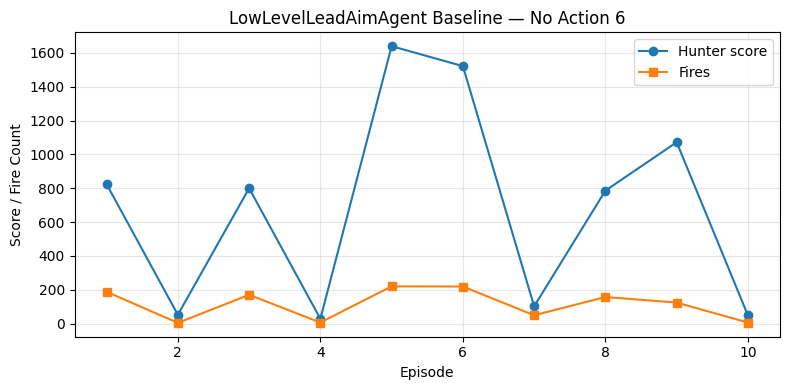

In [7]:
plt.figure(figsize=(8, 4))                                                    # Creates a compact presentation plot.
plt.plot(lead_df["episode"], lead_df["score"], marker="o", label="Hunter score") # Plots baseline score per episode.
plt.plot(lead_df["episode"], lead_df["fires"], marker="s", label="Fires") # Plots baseline fire count per episode.
plt.title("LowLevelLeadAimAgent Baseline — No Action 6")                   # Adds graph title.
plt.xlabel("Episode")                                                       # Labels x-axis.
plt.ylabel("Score / Fire Count")                                            # Labels y-axis.
plt.grid(True, alpha=0.3)                                                     # Adds grid for readability.
plt.legend()                                                                 # Adds legend.
plt.tight_layout()                                                           # Tightens layout.
plt.savefig(OUTPUT_DIR / "lead_aim_no_action6_baseline_plot.png", dpi=160)  # Saves plot image.
plt.show()                                                                   # Displays plot in notebook.




In [8]:
ACTIVE_TRAINING_TIMESTEPS = globals().get("ACTIVE_TRAINING_TIMESTEPS", 250000) # Reuses the active budget defined near the top of the notebook.
ARTIFACT_TAG = globals().get("ARTIFACT_TAG", f"train_{ACTIVE_TRAINING_TIMESTEPS}") # Reuses the active artifact tag for consistent output filenames.
EXPORT_3D_BASELINE_VIDEO = globals().get("EXPORT_3D_BASELINE_VIDEO", True)   # Keeps baseline video export enabled unless changed in the setup cell.
if EXPORT_3D_BASELINE_VIDEO:                                                 # Runs 3D export only when enabled.
    export_low_level_3d_video(LowLevelLeadAimAgent(), OUTPUT_DIR / f"lead_aim_no_action6_real_3d_{ARTIFACT_TAG}.mp4", max_steps=4800, seed=777) # Exports fair 3D video using actions 0–5 only.

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/lead_aim_no_action6_real_3d_train_(250, 0).mp4
Final score: 14 fires: 13 reason: ORANGE vehicle reached the Hunter!


# Section 01 — Strong Hierarchical PPO Training

This section trains the strongest final Hierarchical PPO agent. The purpose is to produce the best demonstration-ready checkpoint while still using the original Shooter-v0 environment and legal low-level actions `0–5`.


## Fairness guarantee — Action 6 remains disabled

The hierarchical agent never sends action 6 to Shooter-v0. PPO predicts a high-level action, and `LowLevelLeadAimAgent` converts that decision into one of the original low-level actions `0–5`. The assertions in the notebook stop execution if an illegal action appears. This makes the method a transparent hybrid/hierarchical DRL agent rather than a pure raw-action PPO agent.


In [9]:
ALLOWED_LOW_LEVEL_ACTIONS = set(range(6))                                    # Defines legal final environment actions 0–5.
ACTION6_DISABLED_MESSAGE = "Action 6 is disabled for final fair evaluation." # Stores reusable fairness message.

def assert_no_action6(action, source="agent"):                              # Guarantees that human-only auto-aim action 6 is not used.
    action_int = int(action)                                                  # Converts the action to a normal integer.
    assert action_int in ALLOWED_LOW_LEVEL_ACTIONS, f"{ACTION6_DISABLED_MESSAGE} Source={source}, action={action_int}" # Stops execution if action 6 is attempted.
    return action_int                                                         # Returns validated action for env.step().

print("Fairness guard active: final evaluation allows actions 0–5 only.")     # Prints the no-action-6 rule.




Fairness guard active: final evaluation allows actions 0–5 only.


In [10]:

from pathlib import Path                                                   # Provides filesystem paths for project-relative imports and outputs.
import sys                                                                  # Provides access to Python import paths.
import math                                                                 # Provides trigonometric functions for aiming calculations.
import numpy as np                                                          # Provides vector and numerical operations.
import pandas as pd                                                         # Stores evaluation metrics as tables.
import matplotlib.pyplot as plt                                             # Creates graphs and top-down gameplay frames.

CURRENT = Path.cwd().resolve()                                               # Reads the current working directory used by JupyterLab.
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT            # Moves one level up when the notebook is opened inside the notebooks folder.
sys.path.insert(0, str(ROOT))                                                # Adds the project root so import shooter works without package installation.

OUTPUT_DIR = ROOT / "outputs"                                                # Defines folder for exported videos and images.
CHECKPOINT_DIR = ROOT / "checkpoints"                                        # Defines folder for saved models.
LOG_DIR = ROOT / "training_logs"                                             # Defines folder for CSV training logs.
OUTPUT_DIR.mkdir(exist_ok=True)                                              # Creates output folder when missing.
CHECKPOINT_DIR.mkdir(exist_ok=True)                                          # Creates checkpoint folder when missing.
LOG_DIR.mkdir(exist_ok=True)                                                 # Creates log folder when missing.

import gymnasium as gym                                                      # Imports Gymnasium environment interface.
import shooter                                                               # Registers Shooter-v0 from shooter/__init__.py.

print("Project root:", ROOT)                                                 # Prints project root for debugging path issues.
print("Notebook outputs:", OUTPUT_DIR)                                      # Prints output folder for exported files.




Project root: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed
Notebook outputs: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs


In [11]:
def wrap_angle(angle):                                                       # Wraps an angle to [-pi, pi] for shortest rotation direction.
    return (angle + math.pi) % (2.0 * math.pi) - math.pi                     # Returns normalized angle difference.


USE_TREE_OCCLUSION_CHECK = True                                              # Enables a line-of-sight gate that prevents firing through trees.
TREE_OCCLUSION_DISCLOSURE = "Uses static tree layout from the environment state; disable for strict observation-only evaluation." # Documents the fairness caveat.
STRICT_OBSERVATION_ONLY = False                                              # Keeps tree blocking enabled for the engineering-controller version.


def unwrap_shooter_env(env):                                                  # Walks through Gym wrappers until the base ShooterEnv is reached.
    base = env                                                               # Starts with the current environment reference.
    while hasattr(base, "env"):                                             # Checks whether another wrapper layer exists.
        base = base.env                                                      # Moves one wrapper level closer to the base environment.
    return base                                                              # Returns the unwrapped ShooterEnv instance.


def get_tree_circles_from_env(env):                                           # Reads static tree circles from the active Shooter environment.
    if env is None:                                                          # Handles missing environment references.
        return []                                                            # Returns no trees when no environment is available.
    base = unwrap_shooter_env(env)                                           # Gets base ShooterEnv from wrappers.
    engine = getattr(base, "_engine", None)                                 # Reads the active GameEngine instance.
    if engine is None:                                                       # Handles calls before reset().
        return []                                                            # Returns no trees when the engine is not initialized.
    state = getattr(engine, "state", {})                                    # Reads the engine state dictionary.
    return list(state.get("trees", []))                                     # Returns static tree dictionaries with x, z, and r fields.


def segment_blocked_by_tree(target, trees, extra_radius=0.85):                # Checks whether a tree blocks the XZ bullet path to a target.
    x = float(target["x"])                                                  # Reads target X coordinate.
    z = float(target["z"])                                                  # Reads target Z coordinate.
    seg_len_sq = x * x + z * z                                               # Computes squared path length from Hunter to target.
    if seg_len_sq <= 1e-6:                                                   # Handles degenerate very-close targets.
        return False                                                         # Treats extremely short path as unblocked.
    for tree in trees:                                                       # Loops through every static tree obstacle.
        tx = float(tree.get("x", 0.0))                                      # Reads tree X coordinate.
        tz = float(tree.get("z", 0.0))                                      # Reads tree Z coordinate.
        radius = float(tree.get("r", 2.5)) + extra_radius                   # Adds safety margin around the tree pillar.
        proj = (tx * x + tz * z) / seg_len_sq                                # Projects tree center onto the Hunter-target segment.
        if proj <= 0.04 or proj >= 0.98:                                     # Ignores trees behind Hunter or beyond the target.
            continue                                                         # Moves to the next tree.
        closest_x = proj * x                                                 # Computes closest segment point X.
        closest_z = proj * z                                                 # Computes closest segment point Z.
        dx = tx - closest_x                                                  # Computes X distance from tree to bullet path.
        dz = tz - closest_z                                                  # Computes Z distance from tree to bullet path.
        if dx * dx + dz * dz <= radius * radius:                             # Checks whether the tree circle intersects the path.
            return True                                                      # Reports that the line of sight is blocked by a tree.
    return False                                                             # Reports clear line of sight when no tree intersects.


def extract_targets_from_obs(obs):                                           # Extracts all alive AI target slots from Shooter observation.
    targets = []                                                             # Stores target dictionaries sorted by environment order.
    for slot in range(15):                                                   # Loops through the 15 vehicle slots.
        base = 6 + slot * 8                                                  # Computes the start index of this vehicle slot.
        alive = obs[base + 6]                                                # Reads alive flag from the vehicle slot.
        is_ai = obs[base + 7]                                                # Reads AI flag from the vehicle slot.
        if alive > 0.5 and is_ai > 0.5:                                      # Keeps only alive AI drones.
            x = float(obs[base + 0] * 100.0)                                 # Converts normalized X coordinate back to arena units.
            z = float(obs[base + 1] * 100.0)                                 # Converts normalized Z coordinate back to arena units.
            d = float(obs[base + 2] * 141.0)                                 # Converts normalized XZ distance back to arena units.
            y = float(obs[base + 5] * 20.0)                                  # Converts normalized altitude back to world units.
            targets.append({"x": x, "y": y, "z": z, "dist": max(d, 0.5)}) # Appends a target dictionary with a safe distance value.
    return targets                                                           # Returns all candidate targets.


def compute_intercept_aim(target, bullet_speed=2.5, ai_speed=0.35, lead_scale=1.35): # Computes predictive yaw and pitch for a moving drone.
    x = target["x"]                                                          # Reads target X coordinate.
    y = target["y"]                                                          # Reads target altitude.
    z = target["z"]                                                          # Reads target Z coordinate.
    dist_xz = max(math.sqrt(x * x + z * z), 0.5)                             # Computes horizontal distance from Hunter.
    px = x                                                                   # Sets relative target X from barrel origin.
    py = y - 2.3                                                             # Sets relative target Y from barrel height.
    pz = z                                                                   # Sets relative target Z from barrel origin.
    vx = -x / dist_xz * ai_speed                                             # Approximates drone X velocity toward the origin.
    vy = 0.0                                                                 # Assumes constant altitude because drones do not change height.
    vz = -z / dist_xz * ai_speed                                             # Approximates drone Z velocity toward the origin.
    a = vx * vx + vy * vy + vz * vz - bullet_speed * bullet_speed            # Builds quadratic intercept coefficient a.
    b = 2.0 * (px * vx + py * vy + pz * vz)                                  # Builds quadratic intercept coefficient b.
    c = px * px + py * py + pz * pz                                          # Builds quadratic intercept coefficient c.
    disc = b * b - 4.0 * a * c                                               # Computes discriminant for the intercept equation.
    if disc >= 0.0 and abs(a) > 1e-8:                                        # Checks whether a valid quadratic solution exists.
        root = math.sqrt(disc)                                               # Computes square root of the discriminant.
        t1 = (-b - root) / (2.0 * a)                                         # Computes first candidate intercept time.
        t2 = (-b + root) / (2.0 * a)                                         # Computes second candidate intercept time.
        valid = [t for t in (t1, t2) if 0.0 < t < 120.0]                     # Keeps future intercept times inside a practical range.
        t = min(valid) if valid else dist_xz / bullet_speed                  # Selects earliest valid intercept time or fallback time.
    else:                                                                    # Handles no-real-solution case.
        t = dist_xz / bullet_speed                                           # Uses simple travel-time estimate.
    t = max(0.0, min(t * lead_scale, 120.0))                                  # Scales the lead forward while preventing extreme aim points.
    aim_x = px + vx * t                                                      # Predicts X position when the bullet arrives.
    aim_y = py + vy * t                                                      # Predicts Y position when the bullet arrives.
    aim_z = pz + vz * t                                                      # Predicts Z position when the bullet arrives.
    required_yaw = math.atan2(aim_z, aim_x)                                  # Converts predicted aim point to yaw angle.
    required_pitch = math.atan2(aim_y, max(math.sqrt(aim_x * aim_x + aim_z * aim_z), 0.5)) # Converts predicted aim point to pitch angle.
    return required_yaw, required_pitch                                      # Returns required yaw and pitch.


class LowLevelLeadAimAgent:                                                  # Defines a deterministic low-level controller using only original actions 0-5.
    def __init__(self):                                                       # Initializes stable action-control hyperparameters.
        self.last_fire_tick = -9999                                           # Stores the latest firing tick for cooldown control.
        self.fire_cooldown = 6                                                # Allows roughly one shot every 0.4 seconds at 20 ticks per second.
        self.max_fire_distance = 100.0                                         # Allows medium-range shots before the drone becomes too close.
        self.min_fire_distance = 5.0                                          # Avoids firing when the target is too close for stable bullet travel.
        self.max_bullets_in_flight = 2                                        # Allows limited bullets in flight without spam firing.
        self.yaw_step = 0.10                                                  # Matches the environment yaw action step size.
        self.pitch_step = 0.02                                                # Matches the environment pitch action step size.
        self.lead_scale = 1.25                                                # Aims slightly ahead of the moving drone for better hit stability.
        self.close_distance = 30.0                                            # Defines close-range behavior for wider fire tolerance.

    def choose_target(self, obs):                                             # Selects a practical target from observation.
        targets = extract_targets_from_obs(obs)                               # Extracts alive targets from observation.
        if not targets:                                                       # Handles no-target condition.
            return None                                                       # Returns no target.
        practical = [t for t in targets if t["dist"] >= self.min_fire_distance] # Avoids targets that are already too close when possible.
        candidates = practical if practical else targets                      # Falls back to all targets if every target is very close.
        return min(candidates, key=lambda t: t["dist"])                      # Chooses the nearest practical target by XZ distance.

    def _fire_tolerances(self, dist):                                         # Computes distance-aware yaw and pitch tolerances.
        yaw_tol = max(0.060, min(0.145, 2.85 / max(dist, 1.0)))               # Uses wider yaw tolerance for close targets and tighter tolerance for far targets.
        pitch_tol = max(0.040, min(0.125, 2.35 / max(dist, 1.0)))             # Uses wider pitch tolerance for close targets and tighter tolerance for far targets.
        return yaw_tol, pitch_tol                                             # Returns final firing tolerances.

    def _tree_blocked(self, target, env=None):                                # Checks whether the selected target is hidden behind a tree.
        if STRICT_OBSERVATION_ONLY:                                           # Checks strict observation-only mode.
            return False                                                     # Disables tree checking when hidden tree state is not allowed.
        if not USE_TREE_OCCLUSION_CHECK:                                      # Checks global tree-check flag.
            return False                                                     # Disables line-of-sight gating when requested.
        trees = get_tree_circles_from_env(env)                                # Reads static tree circles from the active environment.
        return segment_blocked_by_tree(target, trees) if trees else False     # Returns tree blockage status.

    def action(self, obs, info, allow_fire=True, env=None):                   # Chooses one original low-level action from 0-5.
        target = self.choose_target(obs)                                      # Gets the current target to track.
        if target is None:                                                    # Checks if there is no alive target.
            return 0, {"aligned": False, "target_dist": 999.0, "fire_ready": False, "blocked_by_tree": False} # Does nothing when no target exists.
        current_yaw = float(obs[3] * math.pi)                                 # Converts normalized yaw back to radians.
        current_pitch = float(obs[4] * 0.9)                                   # Converts normalized pitch back to radians.
        required_yaw, required_pitch = compute_intercept_aim(target, lead_scale=self.lead_scale) # Computes predictive yaw and pitch.
        yaw_error = wrap_angle(required_yaw - current_yaw)                    # Computes shortest yaw error.
        pitch_error = required_pitch - current_pitch                          # Computes pitch error.
        dist = float(target["dist"])                                         # Reads target distance.
        yaw_fire_tol, pitch_fire_tol = self._fire_tolerances(dist)            # Computes distance-aware firing tolerances.
        aligned = abs(yaw_error) <= yaw_fire_tol and abs(pitch_error) <= pitch_fire_tol # Checks whether aim is good enough to fire.
        tick = int(info.get("tick", 0))                                      # Reads current environment tick.
        bullets = int(info.get("bullets_in_flight", 0))                      # Reads active bullet count.
        cooldown_ready = (tick - self.last_fire_tick) >= self.fire_cooldown   # Checks whether firing cooldown has passed.
        bullet_limit_ok = bullets < self.max_bullets_in_flight               # Allows a limited number of active bullets before blocking new shots.
        distance_ok = self.min_fire_distance <= dist <= self.max_fire_distance # Checks whether target is in practical firing range.
        blocked_by_tree = self._tree_blocked(target, env=env)                 # Checks whether a tree intersects the bullet path.
        fire_ready = bool(allow_fire and aligned and cooldown_ready and bullet_limit_ok and distance_ok and not blocked_by_tree) # Combines all fire gates.
        debug = {                                                             # Builds debug information for evaluation and reward shaping.
            "aligned": aligned,                                             # Stores whether the turret is aligned enough to shoot.
            "target_dist": dist,                                            # Stores target distance.
            "fire_ready": fire_ready,                                       # Stores whether the controller is ready to fire.
            "blocked_by_tree": blocked_by_tree,                             # Stores whether the current shot path is blocked by a tree.
            "yaw_error": yaw_error,                                         # Stores yaw error for diagnostics.
            "pitch_error": pitch_error,                                     # Stores pitch error for diagnostics.
            "yaw_tol": yaw_fire_tol,                                        # Stores yaw firing tolerance.
            "pitch_tol": pitch_fire_tol,                                    # Stores pitch firing tolerance.
            "bullets": bullets,                                             # Stores active bullet count.
        }                                                                     # Ends debug dictionary.
        if fire_ready:                                                        # Fires only when every hit-chance check passes.
            self.last_fire_tick = tick                                        # Updates last fire tick.
            return 1, debug                                                   # Returns action 1 = fire.
        yaw_control_tol = max(0.040, self.yaw_step * 0.45)                    # Sets yaw control dead-zone to reduce oscillation.
        pitch_control_tol = max(0.014, self.pitch_step * 0.70)                # Sets pitch control dead-zone to reduce oscillation.
        if abs(yaw_error) > yaw_control_tol:                                  # Prioritizes yaw alignment before pitch correction.
            return (2 if yaw_error > 0 else 3), debug                         # Returns yaw_left for positive error or yaw_right for negative error.
        if abs(pitch_error) > pitch_control_tol:                              # Adjusts pitch after yaw is sufficiently close.
            return (4 if pitch_error > 0 else 5), debug                       # Returns pitch_up for positive error or pitch_down for negative error.
        return 0, debug                                                       # Holds aim when no correction or fire is needed.


# Action 6 is intentionally not included in the final agent.                  # Keeps final evaluation aligned with the original training action space.



In [12]:

def run_agent(agent, episodes=10, seed_start=100, use_oracle=False):          # Evaluates any agent that returns environment actions.
    env = gym.make("Shooter-v0", render_mode=None)                           # Creates original Shooter environment without rendering.
    rows = []                                                                 # Stores episode metrics.
    for ep in range(episodes):                                                # Loops over evaluation episodes.
        obs, info = env.reset(seed=seed_start + ep)                           # Resets environment with reproducible seed.
        if hasattr(agent, "last_fire_tick"):                                  # Checks whether the agent has cooldown state.
            agent = LowLevelLeadAimAgent()                                    # Recreates low-level agent per episode.
        done = False                                                          # Tracks episode completion.
        total_reward = 0.0                                                    # Tracks cumulative reward.
        fires = 0                                                             # Tracks fire count.
        steps = 0                                                             # Tracks episode length.
        while not done:                                                       # Runs one episode.
            if use_oracle:                                                    # Blocks action-6 oracle use in final fair evaluation.
                raise RuntimeError("Action 6 oracle is disabled in the final fair notebook.") # Blocks the human-only auto-aim shortcut.
            else:                                                            # Uses normal agent action method.
                result = agent.action(obs, info, env=env)                      # Gets fair low-level action with optional tree line-of-sight gating.
                action = result[0] if isinstance(result, tuple) else result   # Extracts action when extra debug info is returned.
            fires += int(action in (1, 6))                                    # Counts fire actions.
            obs, reward, terminated, truncated, info = env.step(action)        # Steps the original environment.
            total_reward += float(reward)                                     # Accumulates original environment reward.
            done = bool(terminated or truncated)                              # Checks episode-ending flags.
            steps += 1                                                        # Updates step count.
        rows.append({"episode": ep + 1, "score": info["hunterScore"], "reward": total_reward, "fires": fires, "steps": steps, "reason": info["gameOverReason"] or "truncated"}) # Stores metrics.
        print(f"ep={ep+1:02d} score={info['hunterScore']:7.1f} reward={total_reward:8.1f} fires={fires:4d} steps={steps:4d} reason={info['gameOverReason'] or 'truncated'}") # Prints metrics.
    env.close()                                                               # Closes environment.
    df = pd.DataFrame(rows)                                                   # Converts results to DataFrame.
    print("mean score:", round(df["score"].mean(), 2))                       # Prints mean score.
    print("mean reward:", round(df["reward"].mean(), 2))                     # Prints mean reward.
    print("mean fires:", round(df["fires"].mean(), 2))                       # Prints mean fires.
    return df                                                                 # Returns evaluation table.




In [13]:

def draw_topdown_frame(env, title="Shooter-v0 Top-Down View"):               # Draws a simple top-down frame without OpenGL.
    state = env.unwrapped._engine.state                                       # Reads internal environment state for visualization only.
    fig, ax = plt.subplots(figsize=(5, 5), dpi=120)                           # Creates a square plotting canvas.
    ax.set_xlim(-100, 100)                                                    # Sets X arena range.
    ax.set_ylim(-100, 100)                                                    # Sets Z arena range.
    ax.set_aspect("equal")                                                   # Keeps world units square.
    ax.set_title(title)                                                       # Adds frame title.
    ax.grid(True, alpha=0.25)                                                 # Adds a light grid for readability.
    ax.scatter([0], [0], marker="^", s=120, label="Hunter")                 # Draws Hunter at the origin.
    yaw = state["hunterYaw"]                                                  # Reads Hunter yaw angle.
    ax.arrow(0, 0, math.cos(yaw) * 20, math.sin(yaw) * 20, width=0.8, alpha=0.8) # Draws current aim direction.
    for tree in state["trees"]:                                               # Loops through static obstacles.
        ax.add_patch(plt.Circle((tree["x"], tree["z"]), tree["r"], alpha=0.18)) # Draws tree collision footprint.
    for vehicle in state["vehicles"]:                                         # Loops through drones.
        if vehicle["alive"]:                                                  # Draws only active drones brightly.
            ax.scatter([vehicle["x"]], [vehicle["z"]], s=55)                 # Draws alive drone position.
        else:                                                                # Handles dead or respawning drones.
            ax.scatter([vehicle["x"]], [vehicle["z"]], s=25, alpha=0.25)     # Draws respawning drone faintly.
    for bullet in state["bullets"]:                                           # Loops through active bullets.
        ax.scatter([bullet["x"]], [bullet["z"]], s=18, marker=".")          # Draws bullet position.
    ax.text(-98, 94, f"tick={state['tick']} score={state['hunterScore']} bullets={len(state['bullets'])}", fontsize=8) # Shows live stats.
    fig.canvas.draw()                                                         # Renders the Matplotlib canvas.
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()             # Converts canvas to RGB image array.
    plt.close(fig)                                                            # Closes figure to avoid memory leak.
    return frame                                                              # Returns RGB frame.


def export_agent_video(agent, output_path, max_steps=800, seed=777, use_oracle=False): # Exports a top-down gameplay video.
    import imageio                                                            # Imports image writer.
    env = gym.make("Shooter-v0", render_mode=None)                           # Creates original environment without OpenGL.
    obs, info = env.reset(seed=seed)                                          # Resets environment with a fixed seed.
    frames = []                                                               # Stores rendered top-down frames.
    total_reward = 0.0                                                        # Tracks total reward.
    fires = 0                                                                 # Tracks fire count.
    for step in range(max_steps):                                             # Runs limited steps for video export.
        if step % 2 == 0:                                                     # Captures every second step to keep video size small.
            frames.append(draw_topdown_frame(env))                            # Appends a visual frame.
        if use_oracle:                                                        # Blocks action-6 oracle use in final fair evaluation.
            action = 6                                                        # Uses auto-aim sanity action.
        else:                                                                # Uses provided agent.
            result = agent.action(obs, info, env=env)                          # Gets agent action with optional tree line-of-sight gating.
            action = result[0] if isinstance(result, tuple) else result       # Extracts action from tuple result.
        fires += int(action in (1, 6))                                        # Counts fire actions.
        obs, reward, terminated, truncated, info = env.step(action)            # Steps the environment.
        total_reward += float(reward)                                         # Accumulates reward.
        if terminated or truncated:                                           # Stops if episode ends.
            frames.append(draw_topdown_frame(env, title="Episode ended"))    # Adds final frame.
            break                                                             # Ends rollout.
    imageio.mimsave(output_path, frames, fps=20)                              # Writes video or GIF based on file extension.
    print("Saved:", output_path)                                             # Prints output file path.
    print("Final score:", info["hunterScore"], "reward:", round(total_reward, 1), "fires:", fires, "reason:", info["gameOverReason"] or "truncated") # Prints video rollout summary.
    env.close()                                                               # Closes environment.




## Quick baseline check before training

In [14]:
lead_check = run_agent(LowLevelLeadAimAgent(), episodes=3, seed_start=1234)  # Checks whether low-level controller can fire before PPO training.
lead_check                                                                  # Displays quick baseline table.



ep=01 score=  678.0 reward=   527.7 fires=  71 steps=2184 reason=MAGENTA vehicle reached the Hunter!
ep=02 score= 1058.0 reward=   927.5 fires= 121 steps=2758 reason=MAGENTA vehicle reached the Hunter!
ep=03 score=  682.0 reward=   571.3 fires=  79 steps=2282 reason=ORANGE vehicle reached the Hunter!
mean score: 806.0
mean reward: 675.5
mean fires: 90.33


,episode,score,reward,fires,steps,reason
0,1,678,527.714527,71,2184,MAGENTA vehicle reached the Hunter!
1,2,1058,927.507634,121,2758,MAGENTA vehicle reached the Hunter!
2,3,682,571.290641,79,2282,ORANGE vehicle reached the Hunter!


## Hierarchical wrapper, Stable-Baselines3 imports, and evaluation callback

This cell defines the training interface for the final method. The wrapper gives PPO a small high-level action space, while the controller converts the high-level decision into a legal low-level action. The evaluation callback periodically measures the original Hunter score during training and saves the best checkpoint.


In [15]:
# Windows / VS Code Jupyter crash guard.
# Keep this at the top of the cell, before importing torch/stable_baselines3.
import os                                                                                       # Imports library components required by the training or evaluation workflow.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")                                           # Executes one step of the notebook workflow.
os.environ.setdefault("OMP_NUM_THREADS", "1")                                                   # Executes one step of the notebook workflow.
os.environ.setdefault("MKL_NUM_THREADS", "1")                                                   # Executes one step of the notebook workflow.
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")                                              # Executes one step of the notebook workflow.
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")                                               # Executes one step of the notebook workflow.

# Imports required by this section. These are placed here so Section 01 works even if Section 02 is not run.
from gymnasium import spaces                                                                    # Imports library components required by the training or evaluation workflow.
from stable_baselines3 import PPO                                                               # Imports library components required by the training or evaluation workflow.
from stable_baselines3.common.callbacks import BaseCallback                                     # Imports library components required by the training or evaluation workflow.
from stable_baselines3.common.monitor import Monitor                                            # Imports library components required by the training or evaluation workflow.
from stable_baselines3.common.vec_env import DummyVecEnv                                        # Imports library components required by the training or evaluation workflow.

# Limit Torch CPU threads to avoid Windows/Jupyter kernel crashes.
try:                                                                                            # Starts a protected block so cleanup or error handling can run safely.
    import torch                                                                                # Imports library components required by the training or evaluation workflow.
    torch.set_num_threads(1)                                                                    # Executes one step of the notebook workflow.
    try:                                                                                        # Starts a protected block so cleanup or error handling can run safely.
        torch.set_num_interop_threads(1)                                                        # Executes one step of the notebook workflow.
    except RuntimeError:                                                                        # Handles the matching error case from the protected block.
        # This can happen if Torch has already started parallel work in the current kernel.
        pass                                                                                    # Leaves this branch intentionally empty.
    print("Torch OK:", torch.__version__)                                                       # Prints progress or diagnostic information for presentation/debugging.
except Exception as exc:                                                                        # Handles the matching error case from the protected block.
    print("Torch import failed. Fix the Python environment before training.")                   # Prints progress or diagnostic information for presentation/debugging.
    raise                                                                                       # Executes one step of the notebook workflow.

print("Stable-Baselines3 imports OK. Section 01 is ready.")                                     # Prints progress or diagnostic information for presentation/debugging.

SCORE_TARGET = 1500.0                                                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
FINAL_EVAL_EPISODES = 100                                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
FINAL_EVAL_SEED_START = 9000                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.


class HierarchicalShooterWrapper(gym.Wrapper):                                                  # Defines a reusable class used by the DRL environment, wrapper, model, or callback.
    """High-level PPO wrapper.

    PPO chooses only 3 high-level decisions:
    0 = track target, 1 = fire only if low-level skill says the shot is ready, 2 = hold.
    The wrapper always sends original Shooter-v0 actions 0-5 to the environment.
    Action 6 is never used.
    """

    def __init__(self, env):                                                                    # Defines a reusable function used later by the notebook workflow.
        super().__init__(env)                                                                   # Executes one step of the notebook workflow.
        self.action_space = spaces.Discrete(3)                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.controller = LowLevelLeadAimAgent()                                                # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_score = 0.0                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_dist = 141.0                                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.current_raw_obs = None                                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.current_info = None                                                                # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.extra_obs_dim = 10                                                                 # Stores a value used by later training, evaluation, logging, or plotting logic.
        base_shape = self.env.observation_space.shape                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
        if base_shape is None or len(base_shape) != 1:                                          # Starts a conditional branch for controlled execution.
            raise ValueError(f"Expected a flat Shooter observation, got {base_shape}")          # Executes one step of the notebook workflow.
        self.base_obs_dim = int(base_shape[0])                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.observation_space = spaces.Box(                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
            low=-np.inf,                                                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
            high=np.inf,                                                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
            shape=(self.base_obs_dim + self.extra_obs_dim,),                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
            dtype=np.float32,                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        )                                                                                       # Closes the current multi-line expression.

    def _compute_target_debug(self, obs, info):                                                 # Defines a reusable function used later by the notebook workflow.
        target = self.controller.choose_target(obs)                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        if target is None:                                                                      # Starts a conditional branch for controlled execution.
            return {                                                                            # Returns the computed value to the caller.
                "target_exists": False,                                                         # Executes one step of the notebook workflow.
                "target_dist": 141.0,                                                           # Executes one step of the notebook workflow.
                "yaw_error": 0.0,                                                               # Executes one step of the notebook workflow.
                "pitch_error": 0.0,                                                             # Executes one step of the notebook workflow.
                "aligned": False,                                                               # Executes one step of the notebook workflow.
                "cooldown_ready": False,                                                        # Executes one step of the notebook workflow.
                "bullet_limit_ok": False,                                                       # Executes one step of the notebook workflow.
                "distance_ok": False,                                                           # Executes one step of the notebook workflow.
                "blocked_by_tree": False,                                                       # Executes one step of the notebook workflow.
                "fire_ready": False,                                                            # Executes one step of the notebook workflow.
                "danger": 0.0,                                                                  # Executes one step of the notebook workflow.
            }                                                                                   # Closes the current multi-line expression.

        current_yaw = float(obs[3] * math.pi)                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        current_pitch = float(obs[4] * 0.9)                                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
        required_yaw, required_pitch = compute_intercept_aim(                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
            target,                                                                             # Executes one step of the notebook workflow.
            lead_scale=self.controller.lead_scale,                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
        )                                                                                       # Closes the current multi-line expression.
        yaw_error = wrap_angle(required_yaw - current_yaw)                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        pitch_error = required_pitch - current_pitch                                            # Stores a value used by later training, evaluation, logging, or plotting logic.
        dist = float(target["dist"])                                                            # Stores a value used by later training, evaluation, logging, or plotting logic.
        yaw_tol, pitch_tol = self.controller._fire_tolerances(dist)                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        aligned = abs(yaw_error) <= yaw_tol and abs(pitch_error) <= pitch_tol                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        tick = int(info.get("tick", 0))                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
        bullets = int(info.get("bullets_in_flight", 0))                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
        cooldown_ready = (tick - self.controller.last_fire_tick) >= self.controller.fire_cooldown # Stores a value used by later training, evaluation, logging, or plotting logic.
        bullet_limit_ok = bullets < self.controller.max_bullets_in_flight                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        distance_ok = self.controller.min_fire_distance <= dist <= self.controller.max_fire_distance # Stores a value used by later training, evaluation, logging, or plotting logic.
        blocked_by_tree = self.controller._tree_blocked(target, env=self.env)                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        fire_ready = bool(aligned and cooldown_ready and bullet_limit_ok and distance_ok and not blocked_by_tree) # Stores a value used by later training, evaluation, logging, or plotting logic.
        danger = max(0.0, min(1.0, (35.0 - dist) / 35.0))                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        return {                                                                                # Returns the computed value to the caller.
            "target_exists": True,                                                              # Executes one step of the notebook workflow.
            "target_dist": dist,                                                                # Executes one step of the notebook workflow.
            "yaw_error": yaw_error,                                                             # Executes one step of the notebook workflow.
            "pitch_error": pitch_error,                                                         # Executes one step of the notebook workflow.
            "aligned": bool(aligned),                                                           # Executes one step of the notebook workflow.
            "cooldown_ready": bool(cooldown_ready),                                             # Executes one step of the notebook workflow.
            "bullet_limit_ok": bool(bullet_limit_ok),                                           # Executes one step of the notebook workflow.
            "distance_ok": bool(distance_ok),                                                   # Executes one step of the notebook workflow.
            "blocked_by_tree": bool(blocked_by_tree),                                           # Executes one step of the notebook workflow.
            "fire_ready": bool(fire_ready),                                                     # Executes one step of the notebook workflow.
            "danger": float(danger),                                                            # Executes one step of the notebook workflow.
        }                                                                                       # Closes the current multi-line expression.

    def _augment_obs(self, obs, info):                                                          # Defines a reusable function used later by the notebook workflow.
        debug = self._compute_target_debug(obs, info)                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
        dist_norm = min(float(debug["target_dist"]) / 141.0, 1.5)                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        extra = np.array(                                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
            [                                                                                   # Executes one step of the notebook workflow.
                1.0 if debug["target_exists"] else 0.0,                                         # Executes one step of the notebook workflow.
                float(np.clip(debug["yaw_error"] / math.pi, -1.0, 1.0)),                        # Executes one step of the notebook workflow.
                float(np.clip(debug["pitch_error"] / 0.9, -1.0, 1.0)),                          # Executes one step of the notebook workflow.
                dist_norm,                                                                      # Executes one step of the notebook workflow.
                1.0 if debug["aligned"] else 0.0,                                               # Executes one step of the notebook workflow.
                1.0 if debug["cooldown_ready"] else 0.0,                                        # Executes one step of the notebook workflow.
                1.0 if debug["bullet_limit_ok"] else 0.0,                                       # Executes one step of the notebook workflow.
                1.0 if debug["distance_ok"] else 0.0,                                           # Executes one step of the notebook workflow.
                1.0 if debug["fire_ready"] else 0.0,                                            # Executes one step of the notebook workflow.
                float(debug["danger"]),                                                         # Executes one step of the notebook workflow.
            ],                                                                                  # Closes the current multi-line expression.
            dtype=np.float32,                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        )                                                                                       # Closes the current multi-line expression.
        base = np.asarray(obs, dtype=np.float32).reshape(-1)                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
        return np.concatenate([base, extra]).astype(np.float32)                                 # Returns the computed value to the caller.

    def reset(self, **kwargs):                                                                  # Defines a reusable function used later by the notebook workflow.
        obs, info = self.env.reset(**kwargs)                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.controller = LowLevelLeadAimAgent()                                                # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_score = float(info.get("hunterScore", 0.0))                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.current_raw_obs = obs                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.current_info = dict(info)                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
        debug = self._compute_target_debug(obs, info)                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_dist = float(debug.get("target_dist", 141.0))                                 # Stores a value used by later training, evaluation, logging, or plotting logic.
        return self._augment_obs(obs, info), info                                               # Returns the computed value to the caller.

    def step(self, high_action):                                                                # Defines a reusable function used later by the notebook workflow.
        high_action = int(high_action)                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
        pre_debug = self._compute_target_debug(self.current_raw_obs, self.current_info)         # Stores a value used by later training, evaluation, logging, or plotting logic.

        if high_action == 2:                                                                    # Starts a conditional branch for controlled execution.
            low_action = 0                                                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
            debug = dict(pre_debug)                                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
            debug["fire_ready"] = False                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
        else:                                                                                   # Starts the fallback branch for the current conditional block.
            allow_fire = high_action == 1                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
            low_action, debug = self.controller.action(                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
                self.current_raw_obs,                                                           # Executes one step of the notebook workflow.
                self.current_info,                                                              # Executes one step of the notebook workflow.
                allow_fire=allow_fire,                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
                env=self.env,                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
            )                                                                                   # Closes the current multi-line expression.

        low_action = assert_no_action6(low_action, source="Hierarchical PPO low-level option")  # Stores a value used by later training, evaluation, logging, or plotting logic.
        obs, original_reward, terminated, truncated, info = self.env.step(low_action)           # Stores a value used by later training, evaluation, logging, or plotting logic.
        info = dict(info)                                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.

        current_score = float(info.get("hunterScore", 0.0))                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
        score_delta = current_score - self.prev_score                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_score = current_score                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.

        post_debug = self._compute_target_debug(obs, info)                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        dist = float(post_debug.get("target_dist", 141.0))                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        distance_closing = max(0.0, self.prev_dist - dist)                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.prev_dist = dist                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.

        shaped = float(original_reward)                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped += 0.50 * score_delta                                                            # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped += 0.02 if high_action == 0 else 0.0                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped += 0.25 if high_action == 1 and debug.get("aligned", False) else 0.0             # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped -= 0.15 if high_action == 1 and not debug.get("aligned", False) else 0.0         # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped -= 0.03 if high_action == 2 else 0.0                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped -= 0.02 * distance_closing                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        if dist < 35.0:                                                                         # Starts a conditional branch for controlled execution.
            shaped -= (35.0 - dist) * 0.03                                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped += 0.005                                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.

        if terminated or truncated:                                                             # Starts a conditional branch for controlled execution.
            final_score = float(info.get("hunterScore", current_score))                         # Stores a value used by later training, evaluation, logging, or plotting logic.
            if final_score < 1500:                                                              # Starts a conditional branch for controlled execution.
             shaped -= (1500 - final_score) * 0.05                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
            else:                                                                               # Starts the fallback branch for the current conditional block.
             shaped += 100.0                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.

        self.current_raw_obs = obs                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.current_info = info                                                                # Stores a value used by later training, evaluation, logging, or plotting logic.

        info["high_action"] = high_action                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        info["original_reward"] = float(original_reward)                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
        info["shaped_reward"] = float(shaped)                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        info["score_delta"] = float(score_delta)                                                # Stores a value used by later training, evaluation, logging, or plotting logic.
        info.update({f"debug_{k}": v for k, v in post_debug.items()})                           # Executes one step of the notebook workflow.
        return self._augment_obs(obs, info), shaped, terminated, truncated, info                # Returns the computed value to the caller.


def make_train_env(seed=0):                                                                     # Defines a reusable function used later by the notebook workflow.
    def _init():                                                                                # Defines a reusable function used later by the notebook workflow.
        env = gym.make("Shooter-v0", render_mode=None)                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
        env = HierarchicalShooterWrapper(env)                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
        env = Monitor(env, filename=None)                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        env.reset(seed=seed)                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
        return env                                                                              # Returns the computed value to the caller.
    return _init                                                                                # Returns the computed value to the caller.


def evaluate_hierarchical_model(model, episodes=FINAL_EVAL_EPISODES, seed_start=FINAL_EVAL_SEED_START, max_steps=6000): # Defines a reusable function used later by the notebook workflow.
    env = HierarchicalShooterWrapper(gym.make("Shooter-v0", render_mode=None))                  # Stores a value used by later training, evaluation, logging, or plotting logic.
    rows = []                                                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
    for ep in tqdm(range(episodes), desc="Hierarchical PPO evaluation"):                        # Starts a loop over the selected sequence.
        obs, info = env.reset(seed=seed_start + ep)                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        done = False                                                                            # Stores a value used by later training, evaluation, logging, or plotting logic.
        shaped_reward_sum = 0.0                                                                 # Stores a value used by later training, evaluation, logging, or plotting logic.
        original_reward_sum = 0.0                                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        fires = 0                                                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        high_fire_modes = 0                                                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
        steps = 0                                                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        last_info = dict(info)                                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        while not done and steps < max_steps:                                                   # Starts a loop that continues while the condition remains true.
            high_action, _ = model.predict(obs, deterministic=True)                             # Stores a value used by later training, evaluation, logging, or plotting logic.
            high_action = int(high_action)                                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
            obs, shaped_reward, terminated, truncated, info = env.step(high_action)             # Stores a value used by later training, evaluation, logging, or plotting logic.
            low_action = int(info.get("low_action", 0))                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
            assert_no_action6(low_action, source="evaluation")                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
            fires += int(low_action == 1)                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
            high_fire_modes += int(high_action == 1)                                            # Stores a value used by later training, evaluation, logging, or plotting logic.
            shaped_reward_sum += float(shaped_reward)                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
            original_reward_sum += float(info.get("original_reward", 0.0))                      # Stores a value used by later training, evaluation, logging, or plotting logic.
            done = bool(terminated or truncated)                                                # Stores a value used by later training, evaluation, logging, or plotting logic.
            steps += 1                                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
            last_info = dict(info)                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
        score = float(last_info.get("hunterScore", 0.0))                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
        rows.append(                                                                            # Executes one step of the notebook workflow.
            {                                                                                   # Executes one step of the notebook workflow.
                "episode": ep + 1,                                                              # Executes one step of the notebook workflow.
                "seed": seed_start + ep,                                                        # Executes one step of the notebook workflow.
                "score": score,                                                                 # Executes one step of the notebook workflow.
                "passed_1500": score >= SCORE_TARGET,                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
                "fires": fires,                                                                 # Executes one step of the notebook workflow.
                "high_fire_modes": high_fire_modes,                                             # Executes one step of the notebook workflow.
                "steps": steps,                                                                 # Executes one step of the notebook workflow.
                "original_reward_sum": original_reward_sum,                                     # Executes one step of the notebook workflow.
                "shaped_reward_sum": shaped_reward_sum,                                         # Executes one step of the notebook workflow.
                "reason": last_info.get("gameOverReason", "") or "truncated/max_steps",         # Executes one step of the notebook workflow.
            }                                                                                   # Closes the current multi-line expression.
        )                                                                                       # Closes the current multi-line expression.
    env.close()                                                                                 # Executes one step of the notebook workflow.
    return pd.DataFrame(rows)                                                                   # Returns the computed value to the caller.


def hierarchical_eval_summary(df, target=SCORE_TARGET):                                         # Defines a reusable function used later by the notebook workflow.
    return pd.DataFrame(                                                                        # Returns the computed value to the caller.
        [                                                                                       # Executes one step of the notebook workflow.
            {                                                                                   # Executes one step of the notebook workflow.
                "episodes": len(df),                                                            # Executes one step of the notebook workflow.
                "target_score": target,                                                         # Executes one step of the notebook workflow.
                "min_score": float(df["score"].min()),                                          # Executes one step of the notebook workflow.
                "mean_score": float(df["score"].mean()),                                        # Executes one step of the notebook workflow.
                "median_score": float(df["score"].median()),                                    # Executes one step of the notebook workflow.
                "max_score": float(df["score"].max()),                                          # Executes one step of the notebook workflow.
                "success_rate_1500": float((df["score"] >= target).mean()),                     # Stores a value used by later training, evaluation, logging, or plotting logic.
                "fail_count_below_1500": int((df["score"] < target).sum()),                     # Executes one step of the notebook workflow.
                "mean_fires": float(df["fires"].mean()),                                        # Executes one step of the notebook workflow.
                "mean_steps": float(df["steps"].mean()),                                        # Executes one step of the notebook workflow.
            }                                                                                   # Closes the current multi-line expression.
        ]                                                                                       # Closes the current multi-line expression.
    )                                                                                           # Closes the current multi-line expression.


class ScoreEvalCallback(BaseCallback):                                                          # Defines a reusable class used by the DRL environment, wrapper, model, or callback.
    """Saves checkpoints by reliability, not only average score."""

    def __init__(self, eval_every=50_000, eval_episodes=20, target=SCORE_TARGET):               # Defines a reusable function used later by the notebook workflow.
        super().__init__()                                                                      # Executes one step of the notebook workflow.
        self.eval_every = int(eval_every)                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.eval_episodes = int(eval_episodes)                                                 # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.target = float(target)                                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.best_key = (-1.0, -1e9, -1e9)                                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
        self.rows = []                                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.

    def _on_step(self):                                                                         # Defines a reusable function used later by the notebook workflow.
        if self.num_timesteps % self.eval_every != 0:                                           # Starts a conditional branch for controlled execution.
            return True                                                                         # Returns the computed value to the caller.

        df = evaluate_hierarchical_model(                                                       # Stores a value used by later training, evaluation, logging, or plotting logic.
            self.model,                                                                         # Executes one step of the notebook workflow.
            episodes=self.eval_episodes,                                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
            seed_start=7000 + self.num_timesteps,                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        )                                                                                       # Closes the current multi-line expression.
        mean_score = float(df["score"].mean())                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        min_score = float(df["score"].min())                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
        success_rate = float((df["score"] >= self.target).mean())                               # Stores a value used by later training, evaluation, logging, or plotting logic.
        mean_fires = float(df["fires"].mean())                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        mean_steps = float(df["steps"].mean())                                                  # Stores a value used by later training, evaluation, logging, or plotting logic.
        fail_count = int((df["score"] < self.target).sum())                                     # Stores a value used by later training, evaluation, logging, or plotting logic.

        row = {                                                                                 # Stores a value used by later training, evaluation, logging, or plotting logic.
            "timesteps": self.num_timesteps,                                                    # Executes one step of the notebook workflow.
            "mean_score": mean_score,                                                           # Executes one step of the notebook workflow.
            "min_score": min_score,                                                             # Executes one step of the notebook workflow.
            "success_rate_1500": success_rate,                                                  # Executes one step of the notebook workflow.
            "fail_count_below_1500": fail_count,                                                # Executes one step of the notebook workflow.
            "mean_fires": mean_fires,                                                           # Executes one step of the notebook workflow.
            "mean_steps": mean_steps,                                                           # Executes one step of the notebook workflow.
        }                                                                                       # Closes the current multi-line expression.
        self.rows.append(row)                                                                   # Executes one step of the notebook workflow.
        pd.DataFrame(self.rows).to_csv(LOG_DIR / "hierarchical_ppo_eval_metrics_1500plus.csv", index=False) # Saves an artifact that supports result reporting or instructor review.

        print(                                                                                  # Prints progress or diagnostic information for presentation/debugging.
            f"[Eval] steps={self.num_timesteps} "                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
            f"success_rate_1500={success_rate:.2%} min_score={min_score:.1f} "                  # Stores a value used by later training, evaluation, logging, or plotting logic.
            f"mean_score={mean_score:.1f} fails={fail_count}/{self.eval_episodes}"              # Stores a value used by later training, evaluation, logging, or plotting logic.
        )                                                                                       # Closes the current multi-line expression.

        current_key = (success_rate, min_score, mean_score)                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
        if current_key > self.best_key:                                                         # Starts a conditional branch for controlled execution.
            self.best_key = current_key                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
            self.model.save(CHECKPOINT_DIR / "best_hierarchical_ppo_1500plus")                  # Saves an artifact that supports result reporting or instructor review.
            self.model.save(CHECKPOINT_DIR / "best_hierarchical_ppo_shooter")  # legacy name for later cells
            torch.save({                                                                        # Saves an artifact that supports result reporting or instructor review.
                "model_name": "Hierarchical PPO",                                               # Executes one step of the notebook workflow.
                "stage": "best_section01_1500plus",                                             # Executes one step of the notebook workflow.
                "native_reload_file": "best_hierarchical_ppo_1500plus.zip",                     # Executes one step of the notebook workflow.
                "format_note": "Use the .zip file to reload this Stable-Baselines3 model. This .pt stores only the PyTorch policy state_dict for instructor inspection.", # Executes one step of the notebook workflow.
                "policy_state_dict": self.model.policy.state_dict(),                            # Executes one step of the notebook workflow.
                "metadata": {"timesteps": int(self.num_timesteps), "success_rate_1500": success_rate, "min_score": min_score, "mean_score": mean_score}, # Executes one step of the notebook workflow.
            }, CHECKPOINT_DIR / "best_hierarchical_ppo_1500plus.pt")                            # Executes one step of the notebook workflow.
            print("Saved new best model by (success_rate_1500, min_score, mean_score).")        # Prints progress or diagnostic information for presentation/debugging.
        return True                                                                             # Returns the computed value to the caller.


def select_hierarchical_checkpoint():                                                           # Defines a reusable function used later by the notebook workflow.
    candidates = [                                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
        CHECKPOINT_DIR / "best_hierarchical_ppo_1500plus.zip",                                  # Executes one step of the notebook workflow.
        CHECKPOINT_DIR / "final_hierarchical_ppo_1500plus.zip",                                 # Executes one step of the notebook workflow.
        CHECKPOINT_DIR / "best_hierarchical_ppo_shooter.zip",                                   # Executes one step of the notebook workflow.
        CHECKPOINT_DIR / "final_hierarchical_ppo_shooter.zip",                                  # Executes one step of the notebook workflow.
        CHECKPOINT_DIR / "hierarchical_ppo_no_action6_comparison.zip",                          # Executes one step of the notebook workflow.
    ]                                                                                           # Closes the current multi-line expression.
    for path in candidates:                                                                     # Starts a loop over the selected sequence.
        if path.exists():                                                                       # Starts a conditional branch for controlled execution.
            return path                                                                         # Returns the computed value to the caller.
    raise FileNotFoundError(                                                                    # Executes one step of the notebook workflow.
        "No Hierarchical PPO checkpoint found. Run the Section 01 training cell first."         # Executes one step of the notebook workflow.
    )                                                                                           # Closes the current multi-line expression.


2026-05-10 22:09:48.647132: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 22:09:48.900250: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Torch OK: 2.9.1+cu126
Stable-Baselines3 imports OK. Section 01 is ready.


## Wrapper smoke test

This cell confirms that the hierarchical wrapper can reset, step once, and return a legal low-level action before long PPO training begins. It is a safety check against wrapper errors before expensive 250,000-timestep runs.


In [16]:
_test_env = make_train_env(seed=123)()                                      # Creates one hierarchical wrapper instance for a fast interface check.
_test_obs, _test_info = _test_env.reset(seed=123)                            # Resets the wrapper with a reproducible seed.
print("Wrapped observation shape:", _test_obs.shape)                         # Prints the observation shape returned by the wrapper.
print("Wrapped action space:", _test_env.action_space)                       # Prints the high-level PPO action space.
_test_obs, _test_reward, _test_terminated, _test_truncated, _test_info = _test_env.step(0) # Executes one high-level action through the wrapper.
assert 0 <= int(_test_info.get("low_action", 0)) < 6, "Action 6 should never be used." # Confirms the wrapper converted the action into a legal low-level action.
print("Smoke test OK. Low action:", _test_info.get("low_action"), "score:", _test_info.get("hunterScore")) # Prints low-level action and original Hunter score.
_test_env.close()                                                            # Closes the smoke-test environment.


Wrapped observation shape: (179,)
Wrapped action space: Discrete(3)
Smoke test OK. Low action: None score: 0


## Train the strong Hierarchical PPO model

This cell trains the Section 01 final model for 250,000 timesteps. It is intended for the strongest gameplay demonstration checkpoint. Section 02 later performs fair comparison training with the same 250,000-timestep budget for every model.


In [17]:
FAST_DEBUG_TIMESTEPS = 100_000                                              # Runs a short smoke-training budget for checking that PPO, wrapper, callback, and checkpoint saving work.
SERIOUS_TIMESTEPS = 1_500_000                                                # Runs a medium-long training budget for practical tuning before the final full run.
COMPETITION_TIMESTEPS = 250_000    # Sets the active training budget for the Section 01 Hierarchical PPO model.
SECTION01_STRONG_TIMESTEPS = COMPETITION_TIMESTEPS                           # Assigns the Section 01 final model budget to the selected runtime.

# Section 01 trains the strongest final Hierarchical PPO demonstration model.
# Section 02 below trains every comparison model under the same fair budget.
TOTAL_TIMESTEPS = SECTION01_STRONG_TIMESTEPS                                 # Selects 250,000 timesteps for the main Hierarchical PPO training run.
N_ENVS = 2                                                                    # Uses two vectorized environments to collect PPO rollouts while staying safer on Windows/Jupyter.
EVAL_EVERY = 50_000                                                           # Evaluates the policy every 50,000 timesteps to reduce overhead during long training.
EVAL_EPISODES_DURING_TRAIN = 10                                               # Evaluates each checkpoint on ten deterministic episodes for a more stable score estimate.
DEVICE = "cpu"                                                               # Uses CPU for safer notebook execution; set to "auto" when CUDA execution is stable.
TRAIN_HIERARCHICAL_PPO = True                                                 # Enables the expensive Section 01 PPO training cell.


def linear_schedule(initial_value, final_value=5e-5):                         # Creates a learning-rate schedule that decreases as training progresses.
    def schedule(progress_remaining):                                         # Receives Stable-Baselines3 progress value from 1.0 at start to 0.0 at end.
        return final_value + (initial_value - final_value) * progress_remaining # Returns a linearly decayed value for the optimizer.
    return schedule                                                           # Returns the schedule function to Stable-Baselines3.


if TRAIN_HIERARCHICAL_PPO:                                                    # Starts Section 01 training only when the training flag is enabled.
    vec_env = DummyVecEnv([make_train_env(seed=1000 + i) for i in range(N_ENVS)]) # Creates seeded hierarchical training environments for PPO rollout collection.
    model = PPO(                                                              # Creates the PPO learner for the high-level hierarchical action space.
        "MlpPolicy",                                                         # Uses an MLP policy because Shooter-v0 provides a vector observation rather than image pixels.
        vec_env,                                                              # Supplies the vectorized hierarchical environments to Stable-Baselines3.
        learning_rate=1e-4,                                                    # Uses a conservative learning rate for long training stability.
        n_steps=1024,                                                          # Collects a longer rollout before each PPO update to capture delayed shooting outcomes.
        batch_size=512,                                                        # Uses a batch size that balances update stability and memory use.
        n_epochs=8,                                                            # Reuses each rollout for multiple optimization passes to extract more learning signal.
        gamma=0.997,                                                           # Gives high weight to long-term rewards because episodes can last thousands of ticks.
        gae_lambda=0.97,                                                       # Uses a long-horizon GAE setting to smooth advantage estimates.
        clip_range=0.12,                                                       # Uses a tighter PPO clip range to reduce destructive policy updates.
        ent_coef=0.002,                                                        # Keeps a small amount of exploration without making the high-level policy too random.
        vf_coef=0.7,                                                           # Gives the critic extra weight so value estimates remain stable during long rollouts.
        max_grad_norm=0.5,                                                     # Clips gradients to reduce unstable neural-network updates.
        verbose=1,                                                             # Prints Stable-Baselines3 training diagnostics.
        device=DEVICE,                                                         # Selects the configured PyTorch device.
        seed=42,                                                               # Sets PPO initialization seed for reproducibility.
    )                                                                         # Finishes PPO model construction.

    callback = ScoreEvalCallback(                                             # Creates a callback that evaluates and saves the best Section 01 model.
        eval_every=EVAL_EVERY,                                                # Sets the evaluation interval in timesteps.
        eval_episodes=EVAL_EPISODES_DURING_TRAIN,                             # Sets the number of evaluation episodes per checkpoint.
        target=SCORE_TARGET,                                                   # Stores the target score threshold for progress reporting.
    )                                                                         # Finishes callback construction.
    try:                                                                      # Ensures the vectorized environment closes even if training is interrupted.
        model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False) # Trains Hierarchical PPO for 250,000 total timesteps.
        model.save(CHECKPOINT_DIR / "final_hierarchical_ppo_1500plus")        # Saves the final Section 01 checkpoint using the historical project name.
        model.save(CHECKPOINT_DIR / "final_hierarchical_ppo_shooter")         # Saves a legacy checkpoint name used by later video/export cells.
        torch.save({                                                           # Saves a PyTorch inspection payload for the final SB3 policy network.
            "model_name": "Hierarchical PPO",                               # Records the model type in the inspection checkpoint.
            "stage": "final_section01_strong_3000000",                     # Records that this checkpoint came from the 250,000-timestep Section 01 run.
            "native_reload_file": "final_hierarchical_ppo_1500plus.zip",    # Documents the correct SB3 file for reloading and gameplay.
            "format_note": "Use the .zip file to reload this Stable-Baselines3 model. This .pt stores only the PyTorch policy state_dict for instructor inspection.", # Explains why both .zip and .pt exist.
            "policy_state_dict": model.policy.state_dict(),                  # Stores policy neural-network weights for inspection.
            "metadata": {"total_timesteps": int(TOTAL_TIMESTEPS), "source": "Section 01 strong run"}, # Stores training metadata.
        }, CHECKPOINT_DIR / "final_hierarchical_ppo_1500plus.pt")             # Writes the final Section 01 inspection .pt file.
        if "save_sb3_model_artifacts" in globals():                           # Checks whether the artifact helper cell has already been run.
            save_sb3_model_artifacts(                                          # Saves an additional standardized artifact pair when helpers are available.
                model,                                                         # Passes the trained SB3 model.
                "Hierarchical PPO",                                           # Stores display name for the model artifact.
                tag="section01_strong_3000000",                              # Uses a tag that makes the 250,000-timestep run explicit.
                stage="final",                                                # Labels the artifact as a final checkpoint.
                metadata={"total_timesteps": TOTAL_TIMESTEPS, "source": "Section 01 strong run"}, # Stores standardized metadata.
            )                                                                 # Finishes standardized artifact export.
        print("Training finished. Final 250,000-timestep Section 01 model saved.") # Prints completion status for the long run.
    finally:                                                                  # Runs cleanup whether training finishes or is interrupted.
        vec_env.close()                                                        # Closes vectorized environments and releases resources.
else:                                                                         # Handles disabled Section 01 training.
    print("TRAIN_HIERARCHICAL_PPO=False, so this cell did not train a model.") # Reports that training was intentionally skipped.


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 232      |
|    ep_rew_mean     | -142     |
| time/              |          |
|    fps             | 2904     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 524           |
|    ep_rew_mean          | -40.4         |
| time/                   |               |
|    fps                  | 2370          |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 4096          |
| train/                  |               |
|    approx_kl            | 0.00010755274 |
|    clip_fraction        | 0             |
|    clip_range           | 0.12          |
|    entropy_loss         | -1.1          |
|    explained_variance   |

Hierarchical PPO evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[Eval] steps=50000 success_rate_1500=20.00% min_score=16.0 mean_score=798.0 fails=8/10
Saved new best model by (success_rate_1500, min_score, mean_score).
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.1e+03      |
|    ep_rew_mean          | 323          |
| time/                   |              |
|    fps                  | 1646         |
|    iterations           | 25           |
|    time_elapsed         | 31           |
|    total_timesteps      | 51200        |
| train/                  |              |
|    approx_kl            | 0.0010646018 |
|    clip_fraction        | 0            |
|    clip_range           | 0.12         |
|    entropy_loss         | -1.02        |
|    explained_variance   | 0.165        |
|    learning_rate        | 0.0001       |
|    loss                 | 430          |
|    n_updates            | 192          |
|    policy_gradient_loss | -0.00104     |
|    value_loss           | 

Hierarchical PPO evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[Eval] steps=100000 success_rate_1500=40.00% min_score=32.0 mean_score=908.4 fails=6/10
Saved new best model by (success_rate_1500, min_score, mean_score).
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1.26e+03     |
|    ep_rew_mean          | 430          |
| time/                   |              |
|    fps                  | 1616         |
|    iterations           | 49           |
|    time_elapsed         | 62           |
|    total_timesteps      | 100352       |
| train/                  |              |
|    approx_kl            | 0.0020332842 |
|    clip_fraction        | 0            |
|    clip_range           | 0.12         |
|    entropy_loss         | -0.858       |
|    explained_variance   | 0.264        |
|    learning_rate        | 0.0001       |
|    loss                 | 259          |
|    n_updates            | 384          |
|    policy_gradient_loss | -0.00101     |
|    value_loss           |

...

[Eval] steps=150000 success_rate_1500=10.00% min_score=50.0 mean_score=866.0 fails=9/10
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 1.47e+03      |
|    ep_rew_mean          | 574           |
| time/                   |               |
|    fps                  | 1598          |
|    iterations           | 74            |
|    time_elapsed         | 94            |
|    total_timesteps      | 151552        |
| train/                  |               |
|    approx_kl            | 2.9497227e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.12          |
|    entropy_loss         | -0.606        |
|    explained_variance   | 0.289         |
|    learning_rate        | 0.0001        |
|    loss                 | 380           |
|    n_updates            | 584           |
|    policy_gradient_loss | -0.000101     |
|    value_loss           | 547           |
--------------------------------

Hierarchical PPO evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[Eval] steps=200000 success_rate_1500=20.00% min_score=32.0 mean_score=680.4 fails=8/10
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 1.68e+03      |
|    ep_rew_mean          | 730           |
| time/                   |               |
|    fps                  | 1609          |
|    iterations           | 98            |
|    time_elapsed         | 124           |
|    total_timesteps      | 200704        |
| train/                  |               |
|    approx_kl            | 0.00096791994 |
|    clip_fraction        | 0             |
|    clip_range           | 0.12          |
|    entropy_loss         | -0.601        |
|    explained_variance   | 0.406         |
|    learning_rate        | 0.0001        |
|    loss                 | 379           |
|    n_updates            | 776           |
|    policy_gradient_loss | -0.00079      |
|    value_loss           | 529           |
--------------------------------

Hierarchical PPO evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

[Eval] steps=250000 success_rate_1500=10.00% min_score=34.0 mean_score=594.0 fails=9/10
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 1.98e+03      |
|    ep_rew_mean          | 924           |
| time/                   |               |
|    fps                  | 1599          |
|    iterations           | 123           |
|    time_elapsed         | 157           |
|    total_timesteps      | 251904        |
| train/                  |               |
|    approx_kl            | 0.00027661872 |
|    clip_fraction        | 0             |
|    clip_range           | 0.12          |
|    entropy_loss         | -0.598        |
|    explained_variance   | 0.36          |
|    learning_rate        | 0.0001        |
|    loss                 | 320           |
|    n_updates            | 976           |
|    policy_gradient_loss | -0.000234     |
|    value_loss           | 448           |
--------------------------------

## Plot Section 01 evaluation progress

This cell reads the hierarchical PPO callback log and visualizes how the original Hunter score changes during training. The plot is used to show whether longer training improves the final method or whether performance saturates.


,timesteps,mean_score,min_score,success_rate_1500,fail_count_below_1500,mean_fires,mean_steps
0,50000,798.0,16.0,0.2,8,0.0,2034.7
1,100000,908.4,32.0,0.4,6,0.0,2342.3
2,150000,866.0,50.0,0.1,9,0.0,2348.0
3,200000,680.4,32.0,0.2,8,0.0,1776.0
4,250000,594.0,34.0,0.1,9,0.0,1765.0


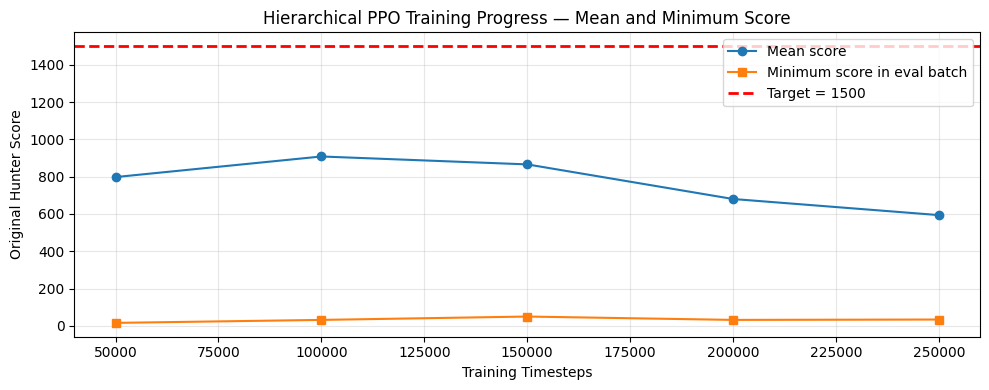

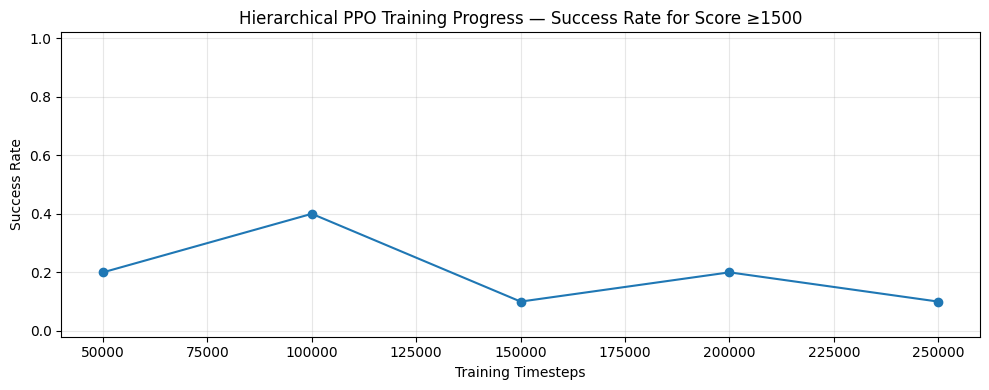

In [18]:
metrics_path = LOG_DIR / "hierarchical_ppo_eval_metrics_1500plus.csv"              # Selects the Section 01 evaluation log produced by ScoreEvalCallback.
if metrics_path.exists():                                                        # Plots progress only when the callback log exists.
    metrics = pd.read_csv(metrics_path)                                      # Loads checkpoint-level training metrics.
    display(metrics.tail())                                                       # Displays the latest evaluation checkpoints.

    fig, ax = plt.subplots(figsize=(10, 4))                                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.plot(metrics["timesteps"], metrics["mean_score"], marker="o", label="Mean score")        # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.plot(metrics["timesteps"], metrics["min_score"], marker="s", label="Minimum score in eval batch") # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.axhline(SCORE_TARGET, color="red", linestyle="--", linewidth=2, label="Target = 1500")   # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.set_title("Hierarchical PPO Training Progress — Mean and Minimum Score")                 # Executes one step of the notebook workflow.
    ax.set_xlabel("Training Timesteps")                                                         # Executes one step of the notebook workflow.
    ax.set_ylabel("Original Hunter Score")                                                      # Executes one step of the notebook workflow.
    ax.grid(True, alpha=0.3)                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.legend()                                                                                 # Executes one step of the notebook workflow.
    fig.tight_layout()                                                                          # Executes one step of the notebook workflow.
    fig.savefig(OUTPUT_DIR / "hierarchical_ppo_1500plus_training_scores.png", dpi=180)          # Saves an artifact that supports result reporting or instructor review.
    plt.show()                                                                                  # Executes one step of the notebook workflow.

    fig, ax = plt.subplots(figsize=(10, 4))                                                     # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.plot(metrics["timesteps"], metrics["success_rate_1500"], marker="o")                     # Stores a value used by later training, evaluation, logging, or plotting logic.
    ax.set_ylim(-0.02, 1.02)                                                                    # Executes one step of the notebook workflow.
    ax.set_title("Hierarchical PPO Training Progress — Success Rate for Score ≥1500")           # Executes one step of the notebook workflow.
    ax.set_xlabel("Training Timesteps")                                                         # Executes one step of the notebook workflow.
    ax.set_ylabel("Success Rate")                                                               # Executes one step of the notebook workflow.
    ax.grid(True, alpha=0.3)                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
    fig.tight_layout()                                                                          # Executes one step of the notebook workflow.
    fig.savefig(OUTPUT_DIR / "hierarchical_ppo_1500plus_success_rate.png", dpi=180)             # Saves an artifact that supports result reporting or instructor review.
    plt.show()                                                                                  # Executes one step of the notebook workflow.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    print("No 1500+ metrics file found yet. Run the PPO training cell first.")                  # Prints progress or diagnostic information for presentation/debugging.


## Final proof evaluation graph

This cell loads the best available Hierarchical PPO checkpoint and evaluates deterministic episodes on fresh seeds. The goal is to provide a presentation-ready proof table and score distribution rather than relying on a single gameplay video.


Using checkpoint: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/checkpoints/best_hierarchical_ppo_1500plus.zip


/home/waranon-021/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Hierarchical PPO evaluation:   0%|          | 0/100 [00:00<?, ?it/s]

,episodes,target_score,min_score,mean_score,median_score,max_score,success_rate_1500,fail_count_below_1500,mean_fires,mean_steps
0,100,1500.0,16.0,930.1,928.0,2272.0,0.31,69,0.0,2378.06


,episode,seed,score,passed_1500,fires,high_fire_modes,steps,original_reward_sum,shaped_reward_sum,reason
94,95,9094,16.0,False,0,229,229,-94.121690,-193.115138,ORANGE vehicle reached the Hunter!
76,77,9076,16.0,False,0,229,229,-94.311581,-198.789856,RED vehicle reached the Hunter!
30,31,9030,32.0,False,0,231,231,-78.154670,-164.432418,ORANGE vehicle reached the Hunter!
63,64,9063,32.0,False,0,232,232,-78.116479,-168.165780,RED vehicle reached the Hunter!
60,61,9060,32.0,False,0,231,231,-78.161267,-167.942202,RED vehicle reached the Hunter!
84,85,9084,32.0,False,0,232,232,-78.059072,-157.994160,LIME vehicle reached the Hunter!
37,38,9037,34.0,False,0,229,229,-76.294379,-190.455074,ORANGE vehicle reached the Hunter!
13,14,9013,34.0,False,0,231,231,-76.139524,-136.378430,CYAN vehicle reached the Hunter!
64,65,9064,34.0,False,0,229,229,-76.039995,-140.425679,LIME vehicle reached the Hunter!
73,74,9073,34.0,False,0,235,235,-76.833014,-166.919852,CYAN vehicle reached the Hunter!


NOT YET PASS: min_score=16.0, success_rate_1500=31.00%


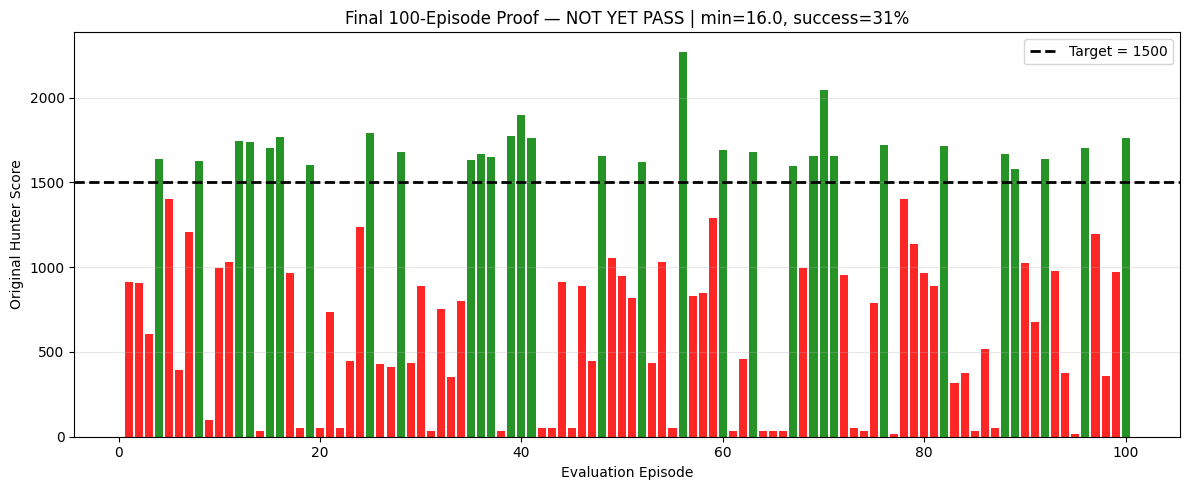

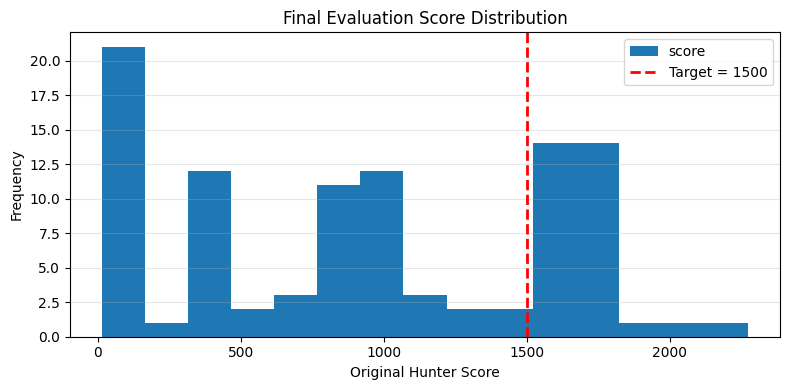

In [19]:
model_path = select_hierarchical_checkpoint()                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
print("Using checkpoint:", model_path)                                                          # Prints progress or diagnostic information for presentation/debugging.
proof_model = PPO.load(model_path)                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.

proof_df = evaluate_hierarchical_model(                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
    proof_model,                                                                                # Executes one step of the notebook workflow.
    episodes=FINAL_EVAL_EPISODES,                                                               # Stores a value used by later training, evaluation, logging, or plotting logic.
    seed_start=FINAL_EVAL_SEED_START,                                                           # Stores a value used by later training, evaluation, logging, or plotting logic.
)                                                                                               # Closes the current multi-line expression.
proof_df.to_csv(LOG_DIR / "hierarchical_ppo_final_100ep_proof_1500plus.csv", index=False)       # Saves an artifact that supports result reporting or instructor review.
summary_1500 = hierarchical_eval_summary(proof_df, target=SCORE_TARGET)                         # Stores a value used by later training, evaluation, logging, or plotting logic.
summary_1500.to_csv(LOG_DIR / "hierarchical_ppo_final_100ep_summary_1500plus.csv", index=False) # Saves an artifact that supports result reporting or instructor review.

display(summary_1500)                                                                           # Displays a notebook table or object for inspection.
display(proof_df.sort_values("score").head(10))                                                 # Displays a notebook table or object for inspection.

min_score = float(proof_df["score"].min())                                                      # Stores a value used by later training, evaluation, logging, or plotting logic.
success_rate = float((proof_df["score"] >= SCORE_TARGET).mean())                                # Stores a value used by later training, evaluation, logging, or plotting logic.
pass_text = "PASS" if min_score >= SCORE_TARGET else "NOT YET PASS"                             # Stores a value used by later training, evaluation, logging, or plotting logic.
print(f"{pass_text}: min_score={min_score:.1f}, success_rate_1500={success_rate:.2%}")          # Prints progress or diagnostic information for presentation/debugging.

fig, ax = plt.subplots(figsize=(12, 5))                                                         # Stores a value used by later training, evaluation, logging, or plotting logic.
bar_colors = ["green" if s >= SCORE_TARGET else "red" for s in proof_df["score"]]               # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.bar(proof_df["episode"], proof_df["score"], color=bar_colors, alpha=0.85)                    # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.axhline(SCORE_TARGET, color="black", linestyle="--", linewidth=2, label="Target = 1500")     # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.set_title(f"Final 100-Episode Proof — {pass_text} | min={min_score:.1f}, success={success_rate:.0%}") # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.set_xlabel("Evaluation Episode")                                                             # Executes one step of the notebook workflow.
ax.set_ylabel("Original Hunter Score")                                                          # Executes one step of the notebook workflow.
ax.grid(axis="y", alpha=0.3)                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.legend()                                                                                     # Executes one step of the notebook workflow.
fig.tight_layout()                                                                              # Executes one step of the notebook workflow.
fig.savefig(OUTPUT_DIR / "hierarchical_ppo_final_100ep_proof_1500plus.png", dpi=200)            # Saves an artifact that supports result reporting or instructor review.
plt.show()                                                                                      # Executes one step of the notebook workflow.

fig, ax = plt.subplots(figsize=(8, 4))                                                          # Stores a value used by later training, evaluation, logging, or plotting logic.
proof_df["score"].plot(kind="hist", bins=15, ax=ax)                                             # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.axvline(SCORE_TARGET, color="red", linestyle="--", linewidth=2, label="Target = 1500")       # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.set_title("Final Evaluation Score Distribution")                                             # Executes one step of the notebook workflow.
ax.set_xlabel("Original Hunter Score")                                                          # Executes one step of the notebook workflow.
ax.grid(axis="y", alpha=0.3)                                                                    # Stores a value used by later training, evaluation, logging, or plotting logic.
ax.legend()                                                                                     # Executes one step of the notebook workflow.
fig.tight_layout()                                                                              # Executes one step of the notebook workflow.
fig.savefig(OUTPUT_DIR / "hierarchical_ppo_final_score_distribution_1500plus.png", dpi=200)     # Saves an artifact that supports result reporting or instructor review.
plt.show()                                                                                      # Executes one step of the notebook workflow.


## Export best-model gameplay video

This section exports a video from the saved Hierarchical PPO checkpoint. The video is qualitative evidence only. The quantitative result should still be reported from the multi-seed evaluation tables and comparison plots.


In [20]:

def export_hierarchical_model_video(model_path, output_path, max_steps=4800, seed=888): # Exports a top-down video from saved hierarchical PPO model.
    import imageio                                                            # Imports image writer.
    model = PPO.load(model_path)                                              # Loads saved PPO model.
    env = HierarchicalShooterWrapper(gym.make("Shooter-v0", render_mode=None)) # Creates wrapped environment without OpenGL.
    obs, info = env.reset(seed=seed)                                          # Resets environment.
    frames = []                                                               # Stores frames.
    fires = 0                                                                 # Counts actual fire actions.
    for step in range(max_steps):                                             # Runs video rollout.
        if step % 2 == 0:                                                     # Captures every second frame.
            frames.append(draw_topdown_frame(env.env))                        # Draws original underlying environment.
        action, _ = model.predict(obs, deterministic=True)                    # Predicts high-level action.
        obs, reward, terminated, truncated, info = env.step(int(action))      # Steps wrapped environment.
        assert 0 <= int(info.get("low_action", 0)) < 6, "Action 6 is disabled for final fair evaluation." # Blocks human-only auto-aim action.
        fires += int(info.get("low_action", 0) == 1)                         # Counts actual fire action.
        if terminated or truncated:                                           # Checks terminal flags.
            frames.append(draw_topdown_frame(env.env, title="Episode ended")) # Adds final frame.
            break                                                             # Stops rollout.
    imageio.mimsave(output_path, frames, fps=20)                              # Writes MP4/GIF based on file extension.
    print("Saved top-down video:", output_path)                              # Prints output path.
    print("Final score:", info["hunterScore"], "fires:", fires, "reason:", info["gameOverReason"] or "truncated") # Prints summary.
    env.close()                                                               # Closes environment.


def export_hierarchical_model_3d_video(model_path, output_path, max_steps=4800, seed=888): # Exports real OpenGL 3D video from saved hierarchical PPO model.
    import imageio                                                            # Imports video writer for MP4/GIF export.
    model = PPO.load(model_path)                                              # Loads saved PPO model.
    env = HierarchicalShooterWrapper(gym.make("Shooter-v0", render_mode="rgb_array")) # Creates wrapped environment with real 3D rendering.
    obs, info = env.reset(seed=seed)                                          # Resets environment and initializes rendering.
    frames = []                                                               # Stores real 3D RGB frames.
    fires = 0                                                                 # Counts actual low-level fire actions.
    try:                                                                      # Protects cleanup if OpenGL fails.
        for step in range(max_steps):                                         # Runs video rollout.
            if step % 2 == 0:                                                 # Captures every second tick to reduce file size.
                frame = env.render()                                          # Captures the current OpenGL 3D frame.
                if frame is not None:                                         # Confirms a valid frame was returned.
                    frames.append(frame)                                      # Stores frame.
            high_action, _ = model.predict(obs, deterministic=True)           # Predicts high-level PPO decision.
            obs, reward, terminated, truncated, info = env.step(int(high_action)) # Converts high-level decision to original low-level action and steps environment.
            low_action = int(info.get("low_action", 0))                      # Reads actual original action executed by the controller.
            assert 0 <= low_action < 6, "Action 6 is disabled for final fair evaluation." # Guarantees only actions 0-5 are used.
            fires += int(low_action == 1)                                     # Counts true fire actions.
            if terminated or truncated:                                       # Stops on terminal condition.
                frame = env.render()                                          # Captures final 3D frame.
                if frame is not None:                                         # Confirms final frame validity.
                    frames.append(frame)                                      # Stores final frame.
                break                                                         # Stops rollout.
        if not frames:                                                        # Handles empty video output.
            raise RuntimeError("No frames were captured from OpenGL renderer.") # Raises a clear rendering error.
        imageio.mimsave(output_path, frames, fps=20)                          # Saves MP4/GIF video.
        print("Saved real 3D video:", output_path)                           # Prints saved file path.
        print("Final score:", info["hunterScore"], "fires:", fires, "reason:", info["gameOverReason"] or "truncated") # Prints rollout summary.
    finally:                                                                  # Ensures resources are released.
        env.close()                                                           # Closes PyGame/OpenGL resources.

EXPORT_HIERARCHICAL_TOPDOWN_VIDEO = True                                                        # Stores a value used by later training, evaluation, logging, or plotting logic.
EXPORT_HIERARCHICAL_3D_VIDEO = True                                                             # Stores a value used by later training, evaluation, logging, or plotting logic.

model_path = select_hierarchical_checkpoint()                                                   # Stores a value used by later training, evaluation, logging, or plotting logic.
print("Using hierarchical checkpoint for optional video export:", model_path)                   # Prints progress or diagnostic information for presentation/debugging.

if EXPORT_HIERARCHICAL_TOPDOWN_VIDEO:                                                           # Starts a conditional branch for controlled execution.
    export_hierarchical_model_video(model_path, OUTPUT_DIR / f"hierarchical_ppo_gameplay_topdown_{ARTIFACT_TAG}_seed999.mp4", max_steps=4800, seed=999) # Stores a value used by later training, evaluation, logging, or plotting logic.
    export_hierarchical_model_video(model_path, OUTPUT_DIR / f"hierarchical_ppo_gameplay_topdown_{ARTIFACT_TAG}_seed999.gif", max_steps=500, seed=999) # Stores a value used by later training, evaluation, logging, or plotting logic.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    print("Top-down video export skipped. Set EXPORT_HIERARCHICAL_TOPDOWN_VIDEO=True to export.") # Prints progress or diagnostic information for presentation/debugging.

if EXPORT_HIERARCHICAL_3D_VIDEO:                                                                # Starts a conditional branch for controlled execution.
    export_hierarchical_model_3d_video(model_path, OUTPUT_DIR / f"hierarchical_ppo_gameplay_real_3d_{ARTIFACT_TAG}_seed999.mp4", max_steps=4800, seed=999) # Stores a value used by later training, evaluation, logging, or plotting logic.
    export_hierarchical_model_3d_video(model_path, OUTPUT_DIR / f"hierarchical_ppo_gameplay_real_3d_{ARTIFACT_TAG}_seed999.gif", max_steps=500, seed=999) # Stores a value used by later training, evaluation, logging, or plotting logic.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    print("3D video export skipped. Set EXPORT_HIERARCHICAL_3D_VIDEO=True to export.")          # Prints progress or diagnostic information for presentation/debugging.




Using hierarchical checkpoint for optional video export: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/checkpoints/best_hierarchical_ppo_1500plus.zip


/home/waranon-021/miniconda3/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 600) to (608, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved top-down video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/hierarchical_ppo_gameplay_topdown_train_(250, 0)_seed999.mp4
Final score: 938 fires: 0 reason: YELLOW vehicle reached the Hunter!
Saved top-down video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/hierarchical_ppo_gameplay_topdown_train_(250, 0)_seed999.gif
Final score: 138 fires: 0 reason: truncated


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved real 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/hierarchical_ppo_gameplay_real_3d_train_(250, 0)_seed999.mp4
Final score: 938 fires: 0 reason: YELLOW vehicle reached the Hunter!
Saved real 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/hierarchical_ppo_gameplay_real_3d_train_(250, 0)_seed999.gif
Final score: 138 fires: 0 reason: truncated


# Section 02 — Fair Model Comparison

This section trains and evaluates every comparison model under the same 250,000-timestep budget. It separates the fair comparison experiment from the Section 01 best-demo run so that the comparison chart does not accidentally use a stronger checkpoint for only one model.


## Why training and comparison are separated

The notebook separates **strong final training** and **fair model comparison** for experimental clarity.

- **Section 01** trains the strongest Hierarchical PPO checkpoint for final gameplay demonstration.
- **Section 02** trains every model with the same 250,000-timestep budget for fair comparison.
- Training all comparison models in one cell is possible and this notebook does it sequentially in the comparison section.
- Separation prevents a stronger checkpoint from one section being accidentally compared against shorter-trained baselines.
- Separate sections also make interrupted training easier to recover because checkpoints and CSV logs are saved per model.


In [21]:
from pathlib import Path                                                   # Provides filesystem paths for project-relative imports and outputs.
import sys                                                                  # Provides access to the Python import path used by JupyterLab.
import math                                                                 # Provides trigonometric functions for yaw, pitch, and lead-aim calculation.
import time                                                                 # Provides timing utilities for training and video export logs.
import numpy as np                                                          # Provides vector and numerical operations.
import pandas as pd                                                         # Stores training and evaluation metrics in table format.
import matplotlib.pyplot as plt                                             # Creates presentation-ready plots.

CURRENT = Path.cwd().resolve()                                               # Reads the current working directory used by the notebook server.
ROOT = CURRENT.parent if CURRENT.name == "notebooks" else CURRENT            # Moves back to project root when the notebook is opened from notebooks/.
sys.path.insert(0, str(ROOT))                                                # Adds project root to Python import path so import shooter works.

OUTPUT_DIR = ROOT / "outputs"                                                # Stores exported plots and videos.
CHECKPOINT_DIR = ROOT / "checkpoints"                                        # Stores trained model checkpoints.
LOG_DIR = ROOT / "training_logs"                                             # Stores CSV files used for comparison plots.
OUTPUT_DIR.mkdir(exist_ok=True)                                              # Creates the output directory when it does not exist.
CHECKPOINT_DIR.mkdir(exist_ok=True)                                          # Creates the checkpoint directory when it does not exist.
LOG_DIR.mkdir(exist_ok=True)                                                 # Creates the training log directory when it does not exist.

import gymnasium as gym                                                      # Imports the Gymnasium environment API.
import shooter                                                               # Registers Shooter-v0 through shooter/__init__.py.

ALLOWED_LOW_LEVEL_ACTIONS = set(range(6))                                    # Defines the final fair action set: actions 0–5 only.
ACTION6_DISABLED_MESSAGE = "Action 6 is disabled for final fair evaluation." # Defines the error message used by fairness assertions.

def assert_no_action6(action, source="agent"):                              # Verifies that no human-only action 6 reaches the environment.
    action_int = int(action)                                                  # Converts NumPy scalar or tensor output into a normal Python integer.
    assert action_int in ALLOWED_LOW_LEVEL_ACTIONS, f"{ACTION6_DISABLED_MESSAGE} Source={source}, action={action_int}" # Stops execution if action 6 appears.
    return action_int                                                         # Returns the validated low-level action.

print("Project root:", ROOT)                                                 # Prints project root for path debugging.
print("CUDA note: GPU accelerates neural networks, while env.step() remains Python simulation.") # Explains expected runtime behavior.
print("Fairness rule: final evaluation allows actions 0–5 only; action 6 is blocked.") # Prints the no-action-6 rule.




Project root: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed
CUDA note: GPU accelerates neural networks, while env.step() remains Python simulation.
Fairness rule: final evaluation allows actions 0–5 only; action 6 is blocked.


In [22]:
def wrap_angle(angle):                                                       # Wraps an angle to [-pi, pi] for shortest rotation direction.
    return (angle + math.pi) % (2.0 * math.pi) - math.pi                     # Returns normalized angle difference.


USE_TREE_OCCLUSION_CHECK = True                                              # Enables a line-of-sight gate that prevents firing through trees.
TREE_OCCLUSION_DISCLOSURE = "Uses static tree layout from the environment state; disable for strict observation-only evaluation." # Documents the fairness caveat.
STRICT_OBSERVATION_ONLY = False                                              # Keeps tree blocking enabled for the engineering-controller version.


def unwrap_shooter_env(env):                                                  # Walks through Gym wrappers until the base ShooterEnv is reached.
    base = env                                                               # Starts with the current environment reference.
    while hasattr(base, "env"):                                             # Checks whether another wrapper layer exists.
        base = base.env                                                      # Moves one wrapper level closer to the base environment.
    return base                                                              # Returns the unwrapped ShooterEnv instance.


def get_tree_circles_from_env(env):                                           # Reads static tree circles from the active Shooter environment.
    if env is None:                                                          # Handles missing environment references.
        return []                                                            # Returns no trees when no environment is available.
    base = unwrap_shooter_env(env)                                           # Gets base ShooterEnv from wrappers.
    engine = getattr(base, "_engine", None)                                 # Reads the active GameEngine instance.
    if engine is None:                                                       # Handles calls before reset().
        return []                                                            # Returns no trees when the engine is not initialized.
    state = getattr(engine, "state", {})                                    # Reads the engine state dictionary.
    return list(state.get("trees", []))                                     # Returns static tree dictionaries with x, z, and r fields.


def segment_blocked_by_tree(target, trees, extra_radius=0.85):                # Checks whether a tree blocks the XZ bullet path to a target.
    x = float(target["x"])                                                  # Reads target X coordinate.
    z = float(target["z"])                                                  # Reads target Z coordinate.
    seg_len_sq = x * x + z * z                                               # Computes squared path length from Hunter to target.
    if seg_len_sq <= 1e-6:                                                   # Handles degenerate very-close targets.
        return False                                                         # Treats extremely short path as unblocked.
    for tree in trees:                                                       # Loops through every static tree obstacle.
        tx = float(tree.get("x", 0.0))                                      # Reads tree X coordinate.
        tz = float(tree.get("z", 0.0))                                      # Reads tree Z coordinate.
        radius = float(tree.get("r", 2.5)) + extra_radius                   # Adds safety margin around the tree pillar.
        proj = (tx * x + tz * z) / seg_len_sq                                # Projects tree center onto the Hunter-target segment.
        if proj <= 0.04 or proj >= 0.98:                                     # Ignores trees behind Hunter or beyond the target.
            continue                                                         # Moves to the next tree.
        closest_x = proj * x                                                 # Computes closest segment point X.
        closest_z = proj * z                                                 # Computes closest segment point Z.
        dx = tx - closest_x                                                  # Computes X distance from tree to bullet path.
        dz = tz - closest_z                                                  # Computes Z distance from tree to bullet path.
        if dx * dx + dz * dz <= radius * radius:                             # Checks whether the tree circle intersects the path.
            return True                                                      # Reports that the line of sight is blocked by a tree.
    return False                                                             # Reports clear line of sight when no tree intersects.


def extract_targets_from_obs(obs):                                           # Extracts all alive AI target slots from Shooter observation.
    targets = []                                                             # Stores target dictionaries sorted by environment order.
    for slot in range(15):                                                   # Loops through the 15 vehicle slots.
        base = 6 + slot * 8                                                  # Computes the start index of this vehicle slot.
        alive = obs[base + 6]                                                # Reads alive flag from the vehicle slot.
        is_ai = obs[base + 7]                                                # Reads AI flag from the vehicle slot.
        if alive > 0.5 and is_ai > 0.5:                                      # Keeps only alive AI drones.
            x = float(obs[base + 0] * 100.0)                                 # Converts normalized X coordinate back to arena units.
            z = float(obs[base + 1] * 100.0)                                 # Converts normalized Z coordinate back to arena units.
            d = float(obs[base + 2] * 141.0)                                 # Converts normalized XZ distance back to arena units.
            y = float(obs[base + 5] * 20.0)                                  # Converts normalized altitude back to world units.
            targets.append({"x": x, "y": y, "z": z, "dist": max(d, 0.5)}) # Appends a target dictionary with a safe distance value.
    return targets                                                           # Returns all candidate targets.


def compute_intercept_aim(target, bullet_speed=2.5, ai_speed=0.35, lead_scale=1.35): # Computes predictive yaw and pitch for a moving drone.
    x = target["x"]                                                          # Reads target X coordinate.
    y = target["y"]                                                          # Reads target altitude.
    z = target["z"]                                                          # Reads target Z coordinate.
    dist_xz = max(math.sqrt(x * x + z * z), 0.5)                             # Computes horizontal distance from Hunter.
    px = x                                                                   # Sets relative target X from barrel origin.
    py = y - 2.3                                                             # Sets relative target Y from barrel height.
    pz = z                                                                   # Sets relative target Z from barrel origin.
    vx = -x / dist_xz * ai_speed                                             # Approximates drone X velocity toward the origin.
    vy = 0.0                                                                 # Assumes constant altitude because drones do not change height.
    vz = -z / dist_xz * ai_speed                                             # Approximates drone Z velocity toward the origin.
    a = vx * vx + vy * vy + vz * vz - bullet_speed * bullet_speed            # Builds quadratic intercept coefficient a.
    b = 2.0 * (px * vx + py * vy + pz * vz)                                  # Builds quadratic intercept coefficient b.
    c = px * px + py * py + pz * pz                                          # Builds quadratic intercept coefficient c.
    disc = b * b - 4.0 * a * c                                               # Computes discriminant for the intercept equation.
    if disc >= 0.0 and abs(a) > 1e-8:                                        # Checks whether a valid quadratic solution exists.
        root = math.sqrt(disc)                                               # Computes square root of the discriminant.
        t1 = (-b - root) / (2.0 * a)                                         # Computes first candidate intercept time.
        t2 = (-b + root) / (2.0 * a)                                         # Computes second candidate intercept time.
        valid = [t for t in (t1, t2) if 0.0 < t < 120.0]                     # Keeps future intercept times inside a practical range.
        t = min(valid) if valid else dist_xz / bullet_speed                  # Selects earliest valid intercept time or fallback time.
    else:                                                                    # Handles no-real-solution case.
        t = dist_xz / bullet_speed                                           # Uses simple travel-time estimate.
    t = max(0.0, min(t * lead_scale, 120.0))                                  # Scales the lead forward while preventing extreme aim points.
    aim_x = px + vx * t                                                      # Predicts X position when the bullet arrives.
    aim_y = py + vy * t                                                      # Predicts Y position when the bullet arrives.
    aim_z = pz + vz * t                                                      # Predicts Z position when the bullet arrives.
    required_yaw = math.atan2(aim_z, aim_x)                                  # Converts predicted aim point to yaw angle.
    required_pitch = math.atan2(aim_y, max(math.sqrt(aim_x * aim_x + aim_z * aim_z), 0.5)) # Converts predicted aim point to pitch angle.
    return required_yaw, required_pitch                                      # Returns required yaw and pitch.


class LowLevelLeadAimAgent:                                                  # Defines a deterministic low-level controller using only original actions 0-5.
    def __init__(self):                                                       # Initializes stable action-control hyperparameters.
        self.last_fire_tick = -9999                                           # Stores the latest firing tick for cooldown control.
        self.fire_cooldown = 6                                                # Allows roughly one shot every 0.4 seconds at 20 ticks per second.
        self.max_fire_distance = 100.0                                         # Allows medium-range shots before the drone becomes too close.
        self.min_fire_distance = 5.0                                          # Avoids firing when the target is too close for stable bullet travel.
        self.max_bullets_in_flight = 2                                        # Allows limited bullets in flight without spam firing.
        self.yaw_step = 0.10                                                  # Matches the environment yaw action step size.
        self.pitch_step = 0.02                                                # Matches the environment pitch action step size.
        self.lead_scale = 1.25                                                # Aims slightly ahead of the moving drone for better hit stability.
        self.close_distance = 30.0                                            # Defines close-range behavior for wider fire tolerance.

    def choose_target(self, obs):                                             # Selects a practical target from observation.
        targets = extract_targets_from_obs(obs)                               # Extracts alive targets from observation.
        if not targets:                                                       # Handles no-target condition.
            return None                                                       # Returns no target.
        practical = [t for t in targets if t["dist"] >= self.min_fire_distance] # Avoids targets that are already too close when possible.
        candidates = practical if practical else targets                      # Falls back to all targets if every target is very close.
        return min(candidates, key=lambda t: t["dist"])                      # Chooses the nearest practical target by XZ distance.

    def _fire_tolerances(self, dist):                                         # Computes distance-aware yaw and pitch tolerances.
        yaw_tol = max(0.060, min(0.145, 2.85 / max(dist, 1.0)))               # Uses wider yaw tolerance for close targets and tighter tolerance for far targets.
        pitch_tol = max(0.040, min(0.125, 2.35 / max(dist, 1.0)))             # Uses wider pitch tolerance for close targets and tighter tolerance for far targets.
        return yaw_tol, pitch_tol                                             # Returns final firing tolerances.

    def _tree_blocked(self, target, env=None):                                # Checks whether the selected target is hidden behind a tree.
        if STRICT_OBSERVATION_ONLY:                                           # Checks strict observation-only mode.
            return False                                                     # Disables tree checking when hidden tree state is not allowed.
        if not USE_TREE_OCCLUSION_CHECK:                                      # Checks global tree-check flag.
            return False                                                     # Disables line-of-sight gating when requested.
        trees = get_tree_circles_from_env(env)                                # Reads static tree circles from the active environment.
        return segment_blocked_by_tree(target, trees) if trees else False     # Returns tree blockage status.

    def action(self, obs, info, allow_fire=True, env=None):                   # Chooses one original low-level action from 0-5.
        target = self.choose_target(obs)                                      # Gets the current target to track.
        if target is None:                                                    # Checks if there is no alive target.
            return 0, {"aligned": False, "target_dist": 999.0, "fire_ready": False, "blocked_by_tree": False} # Does nothing when no target exists.
        current_yaw = float(obs[3] * math.pi)                                 # Converts normalized yaw back to radians.
        current_pitch = float(obs[4] * 0.9)                                   # Converts normalized pitch back to radians.
        required_yaw, required_pitch = compute_intercept_aim(target, lead_scale=self.lead_scale) # Computes predictive yaw and pitch.
        yaw_error = wrap_angle(required_yaw - current_yaw)                    # Computes shortest yaw error.
        pitch_error = required_pitch - current_pitch                          # Computes pitch error.
        dist = float(target["dist"])                                         # Reads target distance.
        yaw_fire_tol, pitch_fire_tol = self._fire_tolerances(dist)            # Computes distance-aware firing tolerances.
        aligned = abs(yaw_error) <= yaw_fire_tol and abs(pitch_error) <= pitch_fire_tol # Checks whether aim is good enough to fire.
        tick = int(info.get("tick", 0))                                      # Reads current environment tick.
        bullets = int(info.get("bullets_in_flight", 0))                      # Reads active bullet count.
        cooldown_ready = (tick - self.last_fire_tick) >= self.fire_cooldown   # Checks whether firing cooldown has passed.
        bullet_limit_ok = bullets < self.max_bullets_in_flight               # Allows a limited number of active bullets before blocking new shots.
        distance_ok = self.min_fire_distance <= dist <= self.max_fire_distance # Checks whether target is in practical firing range.
        blocked_by_tree = self._tree_blocked(target, env=env)                 # Checks whether a tree intersects the bullet path.
        fire_ready = bool(allow_fire and aligned and cooldown_ready and bullet_limit_ok and distance_ok and not blocked_by_tree) # Combines all fire gates.
        debug = {                                                             # Builds debug information for evaluation and reward shaping.
            "aligned": aligned,                                             # Stores whether the turret is aligned enough to shoot.
            "target_dist": dist,                                            # Stores target distance.
            "fire_ready": fire_ready,                                       # Stores whether the controller is ready to fire.
            "blocked_by_tree": blocked_by_tree,                             # Stores whether the current shot path is blocked by a tree.
            "yaw_error": yaw_error,                                         # Stores yaw error for diagnostics.
            "pitch_error": pitch_error,                                     # Stores pitch error for diagnostics.
            "yaw_tol": yaw_fire_tol,                                        # Stores yaw firing tolerance.
            "pitch_tol": pitch_fire_tol,                                    # Stores pitch firing tolerance.
            "bullets": bullets,                                             # Stores active bullet count.
        }                                                                     # Ends debug dictionary.
        if fire_ready:                                                        # Fires only when every hit-chance check passes.
            self.last_fire_tick = tick                                        # Updates last fire tick.
            return 1, debug                                                   # Returns action 1 = fire.
        yaw_control_tol = max(0.040, self.yaw_step * 0.45)                    # Sets yaw control dead-zone to reduce oscillation.
        pitch_control_tol = max(0.014, self.pitch_step * 0.70)                # Sets pitch control dead-zone to reduce oscillation.
        if abs(yaw_error) > yaw_control_tol:                                  # Prioritizes yaw alignment before pitch correction.
            return (2 if yaw_error > 0 else 3), debug                         # Returns yaw_left for positive error or yaw_right for negative error.
        if abs(pitch_error) > pitch_control_tol:                              # Adjusts pitch after yaw is sufficiently close.
            return (4 if pitch_error > 0 else 5), debug                       # Returns pitch_up for positive error or pitch_down for negative error.
        return 0, debug                                                       # Holds aim when no correction or fire is needed.


# Action 6 is intentionally not included in the final agent.                  # Keeps final evaluation aligned with the original training action space.



In [23]:
from stable_baselines3 import PPO, A2C                                        # Imports PPO and A2C for policy-gradient baselines.
from stable_baselines3.common.vec_env import DummyVecEnv                       # Provides vectorized environments for Stable-Baselines3.
import torch                                                                  # Imports PyTorch for custom Dueling Double DQN.
import torch.nn as nn                                                         # Provides neural network layers.
import torch.nn.functional as F                                               # Provides loss functions and activation utilities.
import torch.optim as optim                                                   # Provides optimizers for the custom DQN.
from collections import deque                                                 # Provides efficient replay-buffer storage.
import random                                                                 # Provides random sampling and epsilon exploration.
import json                                                                   # Stores model metadata for artifact files.
import shutil                                                                 # Creates zipped result bundles.

# ── Clear variable policy ──────────────────────────────────────────────────
# Section 01 above is the strong Hierarchical PPO run, which can be trained for 250,000 timesteps.
# Section 02 here is the fair model-comparison run. Every comparison model receives the same budget.
PRESENTATION_FAST = False                                                     # Disables short comparison mode.
FAIR_COMPARISON_TIMESTEPS = 250_000    # Gives DQN, A2C, raw PPO, and Hierarchical PPO the same 250,000-timestep comparison budget.
EQUAL_TRAINING_STEPS = FAIR_COMPARISON_TIMESTEPS                              # Shares one training-step budget across DQN, A2C, PPO, and Hierarchical PPO.
ARTIFACT_TAG = f"train_{EQUAL_TRAINING_STEPS}"                               # Adds the training budget to checkpoint, log, and video filenames.

COMPARISON_N_ENVS = 1                                                         # Uses one environment per comparison model to reduce Windows/Jupyter kernel risk during long runs.
COMPARISON_DEVICE = "cpu"                                                     # Uses CPU for safer long notebook execution; change to "auto" only when CUDA is stable.
DEEP_TRAIN_EVAL_INTERVAL = 25_000                                             # Evaluates every 25,000 timesteps to create deeper training evidence for CSV logs.
DEEP_TRAIN_EVAL_EPISODES = 5                                                  # Evaluates each intermediate checkpoint on fixed seeds.

DQN_STEPS = EQUAL_TRAINING_STEPS                                              # Sets Dueling Double DQN environment steps equal to the common budget.
A2C_STEPS = EQUAL_TRAINING_STEPS                                              # Sets A2C timesteps equal to the common budget.
PPO_STEPS = EQUAL_TRAINING_STEPS                                              # Sets raw PPO timesteps equal to the common budget.
HIER_PPO_STEPS = EQUAL_TRAINING_STEPS                                         # Sets Hierarchical PPO timesteps equal to the common budget.
EVAL_SEEDS = [7000, 7001, 7002, 7003, 7004]                                   # Uses the same fixed seeds for every model.
EVAL_EPISODES = len(EVAL_SEEDS)                                               # Matches evaluation count to the shared seed list.

# For a strict fair comparison, retrain Hierarchical PPO with the same budget.
# For a best-demo presentation, set LOAD_HIERARCHICAL_FROM_SECTION_01=True and RETRAIN_HIERARCHICAL_FOR_COMPARISON=False.
LOAD_HIERARCHICAL_FROM_SECTION_01 = False                                     # Prevents the Section 01 strong model from replacing the fair 250,000-timestep comparison model.
RETRAIN_HIERARCHICAL_FOR_COMPARISON = True                                    # Forces Hierarchical PPO to train under the same 250,000-timestep comparison budget.

print("Comparison configuration loaded.")                                    # Confirms comparison setup.
print("Fair comparison budget:", EQUAL_TRAINING_STEPS)                       # Prints the equal budget.
print("Artifact tag:", ARTIFACT_TAG)                                         # Prints the filename tag.


Comparison configuration loaded.
Fair comparison budget: 250000
Artifact tag: train_250000


In [24]:
class NoAction6Env(gym.Wrapper):                                               # Wraps Shooter-v0 and blocks action 6 in raw-model experiments.
    def step(self, action):                                                    # Intercepts every action before the environment receives it.
        checked_action = assert_no_action6(action, source="NoAction6Env")     # Validates that action 6 is never sent.
        return self.env.step(checked_action)                                   # Steps the original environment with a legal action.


def make_raw_env(seed=0, render_mode=None):                                    # Creates a raw Shooter environment for DQN, A2C, or PPO.
    def _factory():                                                            # Builds one environment instance for vectorized wrappers.
        env = gym.make("Shooter-v0", render_mode=render_mode)                  # Creates the original Shooter environment.
        env = NoAction6Env(env)                                                # Adds fairness guard around env.step().
        env.reset(seed=seed)                                                   # Seeds initial state for reproducibility.
        return env                                                             # Returns wrapped environment.
    return _factory                                                            # Returns factory function required by DummyVecEnv.


class HierarchicalShooterWrapper(gym.Env):                                     # Exposes a high-level PPO action space while executing actions 0–5 only.
    metadata = {"render_modes": ["rgb_array", None]}                         # Declares render modes for compatibility.

    def __init__(self, env):                                                   # Initializes wrapper around the original Shooter environment.
        super().__init__()                                                     # Initializes Gymnasium base class.
        self.env = env                                                         # Stores underlying Shooter environment.
        self.controller = LowLevelLeadAimAgent()                               # Creates deterministic low-level lead-aim controller.
        self.action_space = gym.spaces.Discrete(3)                             # Defines high-level actions: track, allow-fire, hold.
        low = np.concatenate([self.env.observation_space.low, np.full(7, -np.inf, dtype=np.float32)]) # Extends observation lower bound.
        high = np.concatenate([self.env.observation_space.high, np.full(7, np.inf, dtype=np.float32)]) # Extends observation upper bound.
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.float32) # Defines enhanced observation space.
        self.current_obs = None                                                # Stores latest original observation.
        self.current_info = None                                               # Stores latest original info dictionary.
        self.prev_dist = 100.0                                                 # Stores previous target distance for shaping.
        self.prev_score = 0.0                                                  # Stores previous original Hunter score.

    def _extra_features(self, obs, info):                                      # Builds aim-related features for the high-level policy.
        target = self.controller.choose_target(obs)                            # Selects nearest target from observation.
        if target is None:                                                     # Handles no-target state.
            return np.zeros(7, dtype=np.float32)                               # Returns zero extra features.
        current_yaw = float(obs[3] * math.pi)                                  # Converts normalized yaw to radians.
        current_pitch = float(obs[4] * 0.9)                                    # Converts normalized pitch to radians.
        required_yaw, required_pitch = compute_intercept_aim(target, lead_scale=self.controller.lead_scale) # Computes desired aim.
        yaw_error = wrap_angle(required_yaw - current_yaw)                     # Computes yaw error.
        pitch_error = required_pitch - current_pitch                           # Computes pitch error.
        dist = float(target["dist"])                                          # Reads target distance.
        can_fire = float((int(info.get("tick", 0)) - self.controller.last_fire_tick) >= self.controller.fire_cooldown) # Checks cooldown readiness.
        bullets_ok = float(int(info.get("bullets_in_flight", 0)) <= self.controller.max_bullets_in_flight) # Checks bullet limit.
        aligned = float(abs(yaw_error) < 0.12 and abs(pitch_error) < 0.10)      # Encodes coarse alignment state.
        return np.array([yaw_error / math.pi, pitch_error / 0.9, dist / 141.0, can_fire, bullets_ok, aligned, 1.0], dtype=np.float32) # Returns enhanced features.

    def _build_obs(self, obs, info):                                           # Concatenates original observation and extra aim features.
        return np.concatenate([obs.astype(np.float32), self._extra_features(obs, info)], axis=0) # Creates enhanced observation.

    def reset(self, seed=None, options=None):                                  # Resets wrapper and underlying environment.
        obs, info = self.env.reset(seed=seed, options=options)                 # Resets original environment.
        self.controller = LowLevelLeadAimAgent()                               # Resets controller cooldown state.
        self.current_obs = obs                                                 # Stores current original observation.
        self.current_info = info                                               # Stores current original info.
        target = self.controller.choose_target(obs)                            # Selects nearest target.
        self.prev_dist = target["dist"] if target is not None else 100.0      # Initializes previous target distance.
        self.prev_score = float(info.get("hunterScore", 0.0))                 # Initializes previous score.
        return self._build_obs(obs, info), info                                # Returns enhanced observation and info.

    def step(self, high_action):                                               # Converts high-level action into legal low-level action.
        high_action = int(high_action)                                         # Converts action to integer.
        allow_fire = high_action == 1                                          # Allows firing only for high-level action 1.
        if high_action == 2:                                                   # Handles high-level hold action.
            low_action = 0                                                     # Maps hold to do_nothing.
            debug = {"aligned": False, "target_dist": self.prev_dist}        # Creates default debug info.
        else:                                                                 # Handles track or fire-if-aligned action.
            low_action, debug = self.controller.action(self.current_obs, self.current_info, allow_fire=allow_fire, env=self.env) # Uses controller to produce action 0–5.
        low_action = assert_no_action6(low_action, source="HierarchicalShooterWrapper") # Blocks action 6 at the final boundary.
        obs, reward, terminated, truncated, info = self.env.step(low_action)   # Steps original environment with action 0–5 only.
        self.current_obs = obs                                                 # Updates latest original observation.
        self.current_info = info                                               # Updates latest info.
        current_score = float(info.get("hunterScore", 0.0))                   # Reads current Hunter score.
        score_delta = current_score - self.prev_score                          # Computes original-score improvement.
        self.prev_score = current_score                                        # Updates previous score.
        target = self.controller.choose_target(obs)                            # Selects target after transition.
        dist = target["dist"] if target is not None else 100.0                # Reads distance or fallback.
        distance_improvement = self.prev_dist - dist                           # Measures progress toward nearest target.
        self.prev_dist = dist                                                  # Stores current distance for next step.
        shaped_reward = float(reward) + 0.03 * distance_improvement + 0.2 * max(score_delta, 0.0) # Adds mild shaping without changing environment source.
        if high_action == 1 and low_action == 1:                               # Checks whether PPO allowed a real shot.
            shaped_reward += 0.8                                               # Rewards successful high-level firing permission.
        if high_action == 1 and low_action != 1:                               # Checks when PPO asked to fire but controller rejected it.
            shaped_reward -= 0.02                                              # Adds tiny penalty for premature fire permission.
        info = dict(info)                                                      # Copies info dictionary so wrapper can add fields.
        info["low_action"] = int(low_action)                                  # Records actual original action used.
        info["high_action"] = int(high_action)                                # Records high-level action selected.
        info["action6_used"] = False                                          # Explicitly records that action 6 was not used.
        return self._build_obs(obs, info), shaped_reward, terminated, truncated, info # Returns enhanced transition.

    def render(self):                                                          # Forwards rendering to the original environment.
        return self.env.render()                                               # Returns frame when render_mode is rgb_array.

    def close(self):                                                           # Closes the wrapped environment.
        self.env.close()                                                       # Closes original environment.


def make_hier_env(seed=0, render_mode=None):                                  # Creates a hierarchical environment factory.
    def _factory():                                                            # Builds one wrapped environment instance.
        env = gym.make("Shooter-v0", render_mode=render_mode)                  # Creates original Shooter environment.
        env = HierarchicalShooterWrapper(env)                                  # Adds high-level policy wrapper.
        env.reset(seed=seed)                                                   # Seeds initial state.
        return env                                                             # Returns wrapped environment.
    return _factory                                                            # Returns factory function.




In [25]:
class DuelingQNetwork(nn.Module):                                              # Defines Dueling Double DQN network for discrete actions 0–5.
    def __init__(self, obs_dim, action_dim):                                   # Initializes network layers.
        super().__init__()                                                     # Initializes PyTorch module base.
        self.feature = nn.Sequential(nn.Linear(obs_dim, 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU()) # Extracts shared state features.
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1)) # Predicts state value V(s).
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, action_dim)) # Predicts action advantages A(s,a).

    def forward(self, x):                                                      # Computes Q-values from observations.
        features = self.feature(x)                                             # Computes shared feature representation.
        value = self.value(features)                                           # Computes state value stream.
        advantage = self.advantage(features)                                   # Computes action advantage stream.
        return value + advantage - advantage.mean(dim=1, keepdim=True)         # Combines dueling streams into Q-values.


class ReplayBuffer:                                                            # Stores transitions for off-policy DQN training.
    def __init__(self, capacity=100_000):                                      # Initializes replay memory.
        self.buffer = deque(maxlen=capacity)                                   # Creates fixed-size transition queue.

    def add(self, obs, action, reward, next_obs, done):                        # Adds one transition to replay memory.
        self.buffer.append((obs, action, reward, next_obs, done))              # Stores transition tuple.

    def sample(self, batch_size):                                              # Samples random transition batch.
        batch = random.sample(self.buffer, batch_size)                         # Selects random transitions.
        obs, actions, rewards, next_obs, dones = zip(*batch)                   # Splits transition fields.
        return np.array(obs), np.array(actions), np.array(rewards, dtype=np.float32), np.array(next_obs), np.array(dones, dtype=np.float32) # Returns NumPy batch arrays.

    def __len__(self):                                                         # Returns number of stored transitions.
        return len(self.buffer)                                                # Returns replay size.


def train_dueling_double_dqn(total_steps=DQN_STEPS):                          # Trains a direct raw-action Dueling Double DQN baseline.
    env = make_raw_env(seed=4100)()                                            # Creates fair raw environment with no-action-6 guard.
    obs_dim = env.observation_space.shape[0]                                   # Reads observation dimension.
    action_dim = env.action_space.n                                            # Reads action count; should be 6.
    assert action_dim == 6, "DQN baseline expects Shooter-v0 actions 0–5."     # Confirms action 6 is not exposed.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")     # Uses GPU when available.
    online = DuelingQNetwork(obs_dim, action_dim).to(device)                   # Creates online Q-network.
    target = DuelingQNetwork(obs_dim, action_dim).to(device)                   # Creates target Q-network.
    target.load_state_dict(online.state_dict())                                # Initializes target weights from online weights.
    optimizer = optim.Adam(online.parameters(), lr=2.5e-4)                     # Creates Adam optimizer.
    replay = ReplayBuffer(capacity=120_000)                                    # Creates replay buffer.
    obs, info = env.reset(seed=4100)                                           # Resets environment.
    episode_reward = 0.0                                                       # Tracks current episode reward.
    episode_score = 0.0                                                        # Tracks current episode score.
    fires = 0                                                                 # Tracks current episode fire count.
    rows = []                                                                 # Stores episode metrics.
    for step in range(1, total_steps + 1):                                     # Runs training loop by environment steps.
        epsilon = max(0.05, 1.0 - step / max(total_steps * 0.75, 1))           # Decays epsilon exploration.
        if random.random() < epsilon:                                          # Uses random exploration sometimes.
            action = env.action_space.sample()                                 # Samples legal action 0–5 from environment.
        else:                                                                 # Uses greedy policy from Q-network.
            with torch.no_grad():                                             # Disables gradient tracking during action selection.
                q_values = online(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)) # Computes Q-values.
                action = int(q_values.argmax(dim=1).item())                   # Selects highest-value action.
        action = assert_no_action6(action, source="Dueling Double DQN")        # Blocks action 6 before environment step.
        next_obs, reward, terminated, truncated, info = env.step(action)       # Steps original environment.
        done = bool(terminated or truncated)                                   # Combines terminal flags.
        replay.add(obs, action, float(reward), next_obs, done)                 # Stores transition.
        episode_reward += float(reward)                                        # Accumulates episode reward.
        episode_score = float(info.get("hunterScore", 0.0))                   # Reads original Hunter score.
        fires += int(action == 1)                                              # Counts fire actions.
        obs = next_obs                                                         # Advances observation.
        if len(replay) >= 2048:                                                # Starts learning after replay warm-up.
            b_obs, b_actions, b_rewards, b_next_obs, b_dones = replay.sample(256) # Samples training batch.
            obs_t = torch.tensor(b_obs, dtype=torch.float32, device=device)    # Converts observations to tensor.
            actions_t = torch.tensor(b_actions, dtype=torch.long, device=device).unsqueeze(1) # Converts actions to tensor.
            rewards_t = torch.tensor(b_rewards, dtype=torch.float32, device=device).unsqueeze(1) # Converts rewards to tensor.
            next_obs_t = torch.tensor(b_next_obs, dtype=torch.float32, device=device) # Converts next observations to tensor.
            dones_t = torch.tensor(b_dones, dtype=torch.float32, device=device).unsqueeze(1) # Converts done flags to tensor.
            q_pred = online(obs_t).gather(1, actions_t)                       # Reads Q-value for selected action.
            with torch.no_grad():                                             # Disables gradients for target calculation.
                next_actions = online(next_obs_t).argmax(dim=1, keepdim=True) # Double DQN selects next action using online network.
                next_q = target(next_obs_t).gather(1, next_actions)           # Double DQN evaluates next action using target network.
                q_target = rewards_t + 0.995 * (1.0 - dones_t) * next_q       # Builds TD target.
            loss = F.smooth_l1_loss(q_pred, q_target)                         # Computes Huber loss.
            optimizer.zero_grad()                                             # Clears old gradients.
            loss.backward()                                                   # Backpropagates loss.
            nn.utils.clip_grad_norm_(online.parameters(), 5.0)                # Clips gradients for stability.
            optimizer.step()                                                  # Updates online network.
        if step % 2000 == 0:                                                  # Periodically syncs target network.
            target.load_state_dict(online.state_dict())                        # Performs hard target update.
        if done:                                                              # Handles episode end.
            rows.append({"model": "Dueling Double DQN", "step": step, "score": episode_score, "reward": episode_reward, "fires": fires}) # Records episode metrics.
            obs, info = env.reset()                                           # Resets environment.
            episode_reward = 0.0                                              # Resets episode reward.
            episode_score = 0.0                                               # Resets episode score.
            fires = 0                                                         # Resets fire count.
    torch.save({"model_state": online.state_dict(), "obs_dim": obs_dim, "action_dim": action_dim}, CHECKPOINT_DIR / "dueling_double_dqn_comparison.pt") # Saves DQN checkpoint.
    env.close()                                                               # Closes environment.
    dqn_df = pd.DataFrame(rows)                                               # Converts metrics to table.
    dqn_df.to_csv(LOG_DIR / "comparison_dueling_double_dqn_train.csv", index=False) # Saves DQN training metrics.
    return dqn_df                                                             # Returns training metrics.


def trusted_torch_load(path, map_location):                                # Loads a checkpoint created by this notebook under the trusted project folder.
    # PyTorch 2.6 uses weights_only=True by default, which can reject checkpoints containing NumPy scalar metadata.
    # weights_only=False is used only for self-generated checkpoints in checkpoints/, not for unknown downloaded files.
    return torch.load(path, map_location=map_location, weights_only=False)     # Loads trusted local checkpoint with full pickle compatibility.


def load_dqn_policy(path):                                                    # Loads saved Dueling Double DQN policy.
    map_location = "cuda" if torch.cuda.is_available() else "cpu"            # Selects available loading device.
    checkpoint = trusted_torch_load(path, map_location=map_location)           # Loads self-generated DQN checkpoint safely for this local project.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")     # Selects inference device.
    model = DuelingQNetwork(int(checkpoint["obs_dim"]), int(checkpoint["action_dim"])).to(device) # Rebuilds network architecture.
    model.load_state_dict(checkpoint["model_state"])                         # Loads trained weights.
    model.eval()                                                              # Sets network to evaluation mode.
    return model, device                                                      # Returns model and device.




In [26]:
def train_sb3_raw_model(model_name, total_steps):                             # Trains a raw-action A2C or PPO model under no-action-6 guard.
    vec_env = DummyVecEnv([make_raw_env(seed=5000 + i) for i in range(COMPARISON_N_ENVS)])     # Creates vectorized raw environments.
    if model_name == "A2C":                                                   # Selects A2C branch.
        model = A2C("MlpPolicy", vec_env, learning_rate=7e-4, n_steps=32, gamma=0.995, gae_lambda=0.95, ent_coef=0.03, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates A2C model.
    elif model_name == "PPO":                                                 # Selects PPO branch.
        model = PPO("MlpPolicy", vec_env, learning_rate=2.5e-4, n_steps=512, batch_size=512, n_epochs=6, gamma=0.995, gae_lambda=0.95, ent_coef=0.03, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates PPO model.
    else:                                                                     # Handles invalid model name.
        raise ValueError("model_name must be A2C or PPO")                     # Raises clear configuration error.
    model.learn(total_timesteps=total_steps, progress_bar=False)               # Trains the raw-action model.
    model.save(CHECKPOINT_DIR / f"{model_name.lower()}_raw_no_action6")       # Saves trained model.
    vec_env.close()                                                           # Closes vectorized environments.
    return model                                                              # Returns trained model.


def train_hierarchical_ppo_model(total_steps):                                # Trains hierarchical PPO with LowLevelLeadAimAgent controller.
    vec_env = DummyVecEnv([make_hier_env(seed=6000 + i) for i in range(COMPARISON_N_ENVS)])    # Creates vectorized hierarchical environments.
    model = PPO("MlpPolicy", vec_env, learning_rate=2.5e-4, n_steps=512, batch_size=512, n_epochs=6, gamma=0.995, gae_lambda=0.95, ent_coef=0.025, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates PPO model over high-level actions.
    model.learn(total_timesteps=total_steps, progress_bar=False)               # Trains hierarchical PPO.
    model.save(CHECKPOINT_DIR / "hierarchical_ppo_no_action6_comparison")     # Saves trained hierarchical PPO.
    vec_env.close()                                                           # Closes vectorized environments.
    return model                                                              # Returns trained model.




def align_observation_for_model(obs, model):                                  # Aligns evaluation observation shape with the saved SB3 model input shape.
    expected_shape = tuple(model.observation_space.shape)                      # Reads the observation shape used when the model was trained.
    expected_size = int(np.prod(expected_shape))                               # Converts the expected shape into a flat feature count.
    obs_array = np.asarray(obs, dtype=np.float32)                              # Converts the current observation into float32 format.
    if obs_array.shape == expected_shape:                                      # Checks whether the current observation already matches the model.
        return obs_array                                                       # Returns unchanged observation when shapes already match.
    flat_obs = obs_array.reshape(-1)                                           # Flattens the observation so crop or padding can be applied safely.
    if flat_obs.size > expected_size:                                          # Handles wrapper observations that include extra presentation features.
        aligned_obs = flat_obs[:expected_size]                                 # Keeps the features expected by the saved model.
    else:                                                                      # Handles older checkpoints that expect more features than the current wrapper gives.
        pad_width = expected_size - flat_obs.size                              # Computes how many missing features must be padded.
        aligned_obs = np.concatenate([flat_obs, np.zeros(pad_width, dtype=np.float32)]) # Pads missing features with neutral zeros.
    return aligned_obs.reshape(expected_shape)                                 # Restores the exact shape expected by the model.

def evaluate_policy_model(model_name, model=None, model_path=None, episodes=EVAL_EPISODES): # Evaluates a trained comparison model by original Hunter score.
    rows = []                                                                 # Stores evaluation metrics for all evaluation episodes.
    for ep in tqdm(range(episodes), desc=f"Evaluating {model_name}"):          # Loops through evaluation episodes with visible progress.
        eval_seed = EVAL_SEEDS[ep % len(EVAL_SEEDS)]                          # Selects a fixed shared evaluation seed for fair comparison.

        if model_name == "Hierarchical PPO":                                  # Uses hierarchical wrapper when evaluating hierarchical PPO.
            env = make_hier_env(seed=eval_seed)()                              # Creates hierarchical environment with the selected seed.
            obs, info = env.reset(seed=eval_seed)                              # Resets wrapped environment with the same reproducible seed.
        else:                                                                 # Uses raw environment for DQN, A2C, and PPO.
            env = make_raw_env(seed=eval_seed)()                               # Creates raw no-action-6 environment with the selected seed.
            obs, info = env.reset(seed=eval_seed)                              # Resets raw environment with the same reproducible seed.

        done = False                                                          # Tracks whether the current episode has finished.
        total_reward = 0.0                                                    # Tracks cumulative evaluation reward.
        fires = 0                                                             # Tracks actual low-level fire count.
        steps = 0                                                             # Tracks episode length.
        dqn_policy = None                                                     # Creates placeholder for custom DQN policy tuple.

        if model_name == "Dueling Double DQN":                                # Checks whether DQN evaluation is needed.
            dqn_policy = load_dqn_policy(CHECKPOINT_DIR / "dueling_double_dqn_comparison.pt") # Loads saved DQN network.

        while not done:                                                       # Runs one full evaluation episode.
            if model_name == "Dueling Double DQN":                            # Uses custom DQN action selection.
                dqn_model, device = dqn_policy                                # Unpacks DQN model and device.
                with torch.no_grad():                                         # Disables gradients because evaluation does not train.
                    obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0) # Converts observation to model input tensor.
                    q_values = dqn_model(obs_tensor)                          # Computes Q-values for low-level actions.
                    action = int(q_values.argmax(dim=1).item())               # Selects the greedy low-level action.
                action = assert_no_action6(action, source="DQN evaluation")   # Blocks action 6 during DQN evaluation.
                obs, reward, terminated, truncated, info = env.step(action)   # Steps raw environment.
                low_action = action                                           # Records actual low-level action.

            elif model_name == "Hierarchical PPO":                            # Uses high-level PPO and wrapper conversion.
                policy_obs = align_observation_for_model(obs, model)          # Matches wrapper observation shape to model checkpoint input shape.
                high_action, _ = model.predict(policy_obs, deterministic=True) # Predicts high-level action from correctly shaped observation.
                obs, reward, terminated, truncated, info = env.step(int(high_action)) # Steps wrapper that converts high-level action to low-level action.
                low_action = assert_no_action6(info.get("low_action", 0), source="Hierarchical evaluation") # Validates actual low-level action.

            else:                                                             # Uses raw A2C or raw PPO model.
                action, _ = model.predict(obs, deterministic=True)             # Predicts raw low-level action.
                action = assert_no_action6(action, source=f"{model_name} evaluation") # Blocks action 6 during raw policy evaluation.
                obs, reward, terminated, truncated, info = env.step(action)   # Steps raw environment.
                low_action = action                                           # Records actual low-level action.

            total_reward += float(reward)                                     # Accumulates reward.
            fires += int(low_action == 1)                                     # Counts actual fire actions.
            done = bool(terminated or truncated)                              # Checks whether episode ended.
            steps += 1                                                        # Updates step count.

        score = float(info.get("hunterScore", 0.0))                           # Reads original Hunter score from environment info.
        kills_est = max((score + 2.0 * fires) / 20.0, 0.0)                    # Estimates kills from score because score = 20*kills - 2*fires.
        hit_rate = kills_est / max(fires, 1)                                  # Estimates hit rate while avoiding division by zero.
        rows.append({                                                         # Stores one row of evaluation metrics.
            "model": model_name,                                              # Stores model name.
            "episode": ep + 1,                                                # Stores episode number.
            "seed": eval_seed,                                                # Stores evaluation seed used for reproducibility.
            "score": score,                                                   # Stores original Hunter score.
            "reward": total_reward,                                           # Stores cumulative evaluation reward.
            "fires": fires,                                                   # Stores actual low-level fire count.
            "steps": steps,                                                   # Stores episode length.
            "hit_rate": hit_rate,                                             # Stores estimated hit rate.
            "action6_used": False                                             # Records that action 6 was not used.
        })                                                                                      # Closes the current multi-line expression.
        env.close()                                                           # Closes environment after the episode.

    return pd.DataFrame(rows)                                                 # Returns evaluation metrics as a DataFrame.





## Artifact helpers — `.zip`, `.pt`, and deep CSV training logs

This section defines how model evidence is saved for instructor inspection.

| Model | Native training library | Main reload format | Extra inspection format |
|---|---|---|---|
| Dueling Double DQN | custom PyTorch | `.pt` | `.pt` |
| A2C | Stable-Baselines3 | `.zip` | `.pt` policy-state export |
| Raw PPO | Stable-Baselines3 | `.zip` | `.pt` policy-state export |
| Hierarchical PPO | Stable-Baselines3 | `.zip` | `.pt` policy-state export |

Stable-Baselines3 models should be reloaded from `.zip`. The additional `.pt` files store PyTorch policy weights and metadata for inspection, not for standard SB3 reloading.


In [27]:
def safe_artifact_name(name):                                                # Converts a display model name into a safe filename stem.
    return str(name).lower().replace(" ", "_").replace("-", "_").replace("/", "_") # Normalizes common filename separators.


def save_sb3_model_artifacts(model, model_name, tag=None, stage="final", metadata=None): # Saves SB3 model as native .zip and policy-state .pt.
    tag = tag or globals().get("ARTIFACT_TAG", "train_unknown")              # Uses the active training tag when none is provided.
    metadata = dict(metadata or {})                                           # Copies metadata so the caller's object is not mutated.
    safe_name = safe_artifact_name(model_name)                                # Builds a safe model name.
    base_path = CHECKPOINT_DIR / f"{stage}_{safe_name}_{tag}"                # Creates base path without extension for SB3 save.
    model.save(base_path)                                                     # Saves native Stable-Baselines3 checkpoint as .zip.
    zip_path = base_path.with_suffix(".zip")                                 # Locates the SB3 .zip file.
    pt_path = CHECKPOINT_DIR / f"{stage}_{safe_name}_{tag}.pt"               # Creates PyTorch policy-state inspection path.
    payload = {                                                               # Builds checkpoint payload for instructor inspection.
        "model_name": model_name,                                            # Stores display model name.
        "stage": stage,                                                      # Stores best or final stage.
        "tag": tag,                                                          # Stores training-budget tag.
        "native_reload_file": zip_path.name,                                 # Documents the correct SB3 reload file.
        "format_note": "Use the .zip file to reload Stable-Baselines3 models. This .pt stores only the PyTorch policy state_dict for inspection.", # Documents format limitation.
        "policy_state_dict": model.policy.state_dict(),                      # Stores policy network weights.
        "observation_space": str(model.observation_space),                   # Stores observation-space summary.
        "action_space": str(model.action_space),                             # Stores action-space summary.
        "metadata": metadata,                                                # Stores extra experiment metadata.
    }                                                                         # Finishes payload.
    torch.save(payload, pt_path)                                              # Saves policy-state artifact.
    return {"zip": zip_path, "pt": pt_path}                                # Returns saved artifact paths.


def save_dqn_model_artifact(model, obs_dim, action_dim, path, metadata=None): # Saves custom Dueling Double DQN as a PyTorch .pt checkpoint.
    metadata = dict(metadata or {})                                           # Copies metadata safely.
    torch.save({                                                              # Saves complete DQN checkpoint payload.
        "model_state": model.state_dict(),                                   # Keeps legacy key used by load_dqn_policy().
        "model_state_dict": model.state_dict(),                              # Adds standard PyTorch key for instructor inspection.
        "obs_dim": int(obs_dim),                                             # Stores observation dimension.
        "action_dim": int(action_dim),                                       # Stores action count.
        "format_note": "Custom PyTorch Dueling Double DQN checkpoint. Load with DuelingQNetwork and state_dict.", # Documents format.
        "metadata": metadata,                                                # Stores experiment metadata.
    }, path)                                                                  # Writes the .pt file.
    return path                                                               # Returns saved path.


class DeepTrainEvalCallback(BaseCallback):                                    # Periodically evaluates SB3 models and saves deep CSV logs.
    def __init__(self, model_name, tag=None, eval_every=25_000, eval_episodes=5, verbose=0): # Initializes callback configuration.
        super().__init__(verbose=verbose)                                     # Initializes BaseCallback.
        self.model_name = model_name                                          # Stores model name for evaluation.
        self.tag = tag or globals().get("ARTIFACT_TAG", "train_unknown")    # Stores filename tag.
        self.eval_every = int(eval_every)                                     # Stores evaluation interval.
        self.eval_episodes = int(eval_episodes)                               # Stores number of evaluation episodes.
        self.rows = []                                                        # Stores timestep-level summary rows.
        self.best_mean_score = -float("inf")                                 # Tracks best mean score seen so far.
        self.next_eval_step = int(eval_every)                                 # Sets first evaluation timestep.
        self.safe_name = safe_artifact_name(model_name)                       # Stores safe filename model name.
        self.csv_path = LOG_DIR / f"{self.safe_name}_deep_train_steps_{self.tag}.csv" # Stores summary CSV path.

    def _evaluate_now(self):                                                  # Runs one evaluation checkpoint.
        eval_df = evaluate_policy_model(self.model_name, model=self.model, episodes=self.eval_episodes) # Evaluates current policy on fixed seeds.
        row = {                                                               # Builds one timestep-level summary row.
            "model": self.model_name,                                        # Stores model name.
            "timesteps": int(self.num_timesteps),                            # Stores current SB3 timestep count.
            "mean_score": float(eval_df["score"].mean()),                   # Stores mean original Hunter score.
            "max_score": float(eval_df["score"].max()),                     # Stores best episode score in this evaluation.
            "min_score": float(eval_df["score"].min()),                     # Stores weakest episode score in this evaluation.
            "mean_reward": float(eval_df["reward"].mean()),                 # Stores mean reward.
            "mean_fires": float(eval_df["fires"].mean()),                   # Stores mean actual low-level fire count.
            "mean_steps": float(eval_df["steps"].mean()),                   # Stores mean episode length.
            "mean_hit_rate": float(eval_df["hit_rate"].mean()),             # Stores mean estimated hit rate.
            "eval_episodes": int(len(eval_df)),                              # Stores evaluation episode count.
            "action6_used": bool(eval_df["action6_used"].any()),            # Records whether action 6 appeared.
        }                                                                     # Finishes row.
        self.rows.append(row)                                                 # Adds row to training history.
        pd.DataFrame(self.rows).to_csv(self.csv_path, index=False)            # Saves updated deep training CSV.
        eval_df.to_csv(LOG_DIR / f"{self.safe_name}_eval_episodes_step_{int(self.num_timesteps)}_{self.tag}.csv", index=False) # Saves per-seed evaluation details.
        if row["mean_score"] > self.best_mean_score:                         # Checks whether this checkpoint is best so far.
            self.best_mean_score = row["mean_score"]                         # Updates best mean score.
            save_sb3_model_artifacts(                                         # Saves best checkpoint in both .zip and .pt forms.
                self.model,                                                   # Passes current SB3 model.
                self.model_name,                                              # Passes model name.
                tag=self.tag,                                                 # Passes filename tag.
                stage="best",                                                # Marks checkpoint as best.
                metadata={"timesteps": int(self.num_timesteps), "mean_score": row["mean_score"]}, # Stores best metadata.
            )                                                                 # Finishes best save.
        return row                                                            # Returns summary row.

    def _on_step(self):                                                       # Runs during SB3 training.
        if self.num_timesteps >= self.next_eval_step:                         # Checks whether evaluation interval was reached.
            row = self._evaluate_now()                                        # Evaluates and saves logs.
            print(f"[{self.model_name}] step={row['timesteps']:,} mean_score={row['mean_score']:.2f} mean_fires={row['mean_fires']:.2f}") # Prints progress.
            self.next_eval_step += self.eval_every                            # Schedules next evaluation.
        return True                                                           # Continues training.

    def _on_training_end(self):                                               # Runs after SB3 training ends.
        if not self.rows:                                                     # Handles short runs that never reached eval interval.
            self._evaluate_now()                                              # Runs at least one evaluation.
        save_sb3_model_artifacts(                                             # Saves final checkpoint in both .zip and .pt forms.
            self.model,                                                       # Passes final SB3 model.
            self.model_name,                                                  # Passes model name.
            tag=self.tag,                                                     # Passes filename tag.
            stage="final",                                                   # Marks checkpoint as final.
            metadata={"timesteps": int(self.num_timesteps)},                 # Stores final training step.
        )                                                                     # Finishes final save.


def evaluate_dqn_network(dqn_model, device, episodes=5, seeds=None):          # Evaluates the in-memory DQN policy without loading from disk.
    seeds = list(seeds or globals().get("EVAL_SEEDS", [7000, 7001, 7002, 7003, 7004])) # Uses shared fixed seeds.
    rows = []                                                                 # Stores one row per evaluation episode.
    dqn_model.eval()                                                          # Switches DQN to inference mode.
    for ep in range(int(episodes)):                                           # Loops through evaluation episodes.
        eval_seed = int(seeds[ep % len(seeds)])                               # Selects fixed evaluation seed.
        env = make_raw_env(seed=eval_seed)()                                  # Creates raw no-action-6 environment.
        obs, info = env.reset(seed=eval_seed)                                 # Resets with the selected seed.
        done = False                                                          # Tracks episode completion.
        total_reward = 0.0                                                    # Tracks cumulative reward.
        fires = 0                                                             # Tracks fire count.
        steps = 0                                                             # Tracks episode length.
        while not done:                                                       # Runs one episode.
            with torch.no_grad():                                             # Disables gradient tracking.
                obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0) # Converts obs to tensor.
                q_values = dqn_model(obs_tensor)                              # Computes action Q-values.
                action = int(q_values.argmax(dim=1).item())                   # Selects greedy action.
            action = assert_no_action6(action, source="DQN deep-log evaluation") # Blocks action 6.
            obs, reward, terminated, truncated, info = env.step(action)       # Steps original environment.
            total_reward += float(reward)                                     # Accumulates reward.
            fires += int(action == 1)                                         # Counts fire action.
            done = bool(terminated or truncated)                              # Updates done state.
            steps += 1                                                        # Counts step.
        score = float(info.get("hunterScore", 0.0))                          # Reads original Hunter score.
        kills_est = max((score + 2.0 * fires) / 20.0, 0.0)                   # Estimates kills from score and fires.
        rows.append({                                                         # Stores evaluation metrics.
            "model": "Dueling Double DQN",                                  # Stores model name.
            "episode": ep + 1,                                               # Stores episode number.
            "seed": eval_seed,                                               # Stores seed.
            "score": score,                                                  # Stores score.
            "reward": total_reward,                                          # Stores reward.
            "fires": fires,                                                  # Stores fires.
            "steps": steps,                                                  # Stores steps.
            "hit_rate": kills_est / max(fires, 1),                           # Stores estimated hit rate.
            "action6_used": False,                                           # Confirms no action 6.
        })                                                                    # Finishes row.
        env.close()                                                           # Closes env.
    dqn_model.train()                                                         # Returns DQN to training mode.
    return pd.DataFrame(rows)                                                 # Returns evaluation table.


def build_training_artifact_manifest(tag=None):                               # Creates a manifest of checkpoints, logs, plots, and videos.
    tag = tag or globals().get("ARTIFACT_TAG", "train_unknown")              # Uses active tag.
    rows = []                                                                 # Stores manifest rows.
    search_roots = [(CHECKPOINT_DIR, "checkpoint"), (LOG_DIR, "csv_log"), (OUTPUT_DIR, "output")] # Defines artifact roots.
    for root, artifact_type in search_roots:                                  # Loops through roots.
        for path in sorted(root.glob("*")):                                   # Loops through files.
            if path.is_file() and path.suffix.lower() in {".zip", ".pt", ".csv", ".png", ".mp4", ".gif"}: # Keeps important artifacts only.
                rows.append({                                                 # Adds manifest row.
                    "artifact_type": artifact_type,                          # Stores artifact category.
                    "file_name": path.name,                                  # Stores filename.
                    "extension": path.suffix.lower(),                        # Stores extension.
                    "size_bytes": int(path.stat().st_size),                  # Stores file size.
                    "path": str(path),                                       # Stores full path.
                })                                                            # Finishes row.
    manifest_df = pd.DataFrame(rows)                                          # Converts manifest to table.
    manifest_path = LOG_DIR / f"training_artifact_manifest_{tag}.csv"         # Creates manifest path.
    manifest_df.to_csv(manifest_path, index=False)                            # Saves manifest CSV.
    display(manifest_df)                                                       # Displays manifest.
    return manifest_df                                                        # Returns manifest.


def create_training_results_bundle(tag=None):                                 # Creates one zip bundle of generated result artifacts.
    tag = tag or globals().get("ARTIFACT_TAG", "train_unknown")              # Uses active tag.
    manifest_df = build_training_artifact_manifest(tag=tag)                   # Builds manifest first.
    bundle_root = OUTPUT_DIR / f"training_results_bundle_{tag}"              # Creates temporary bundle folder.
    bundle_root.mkdir(exist_ok=True)                                          # Ensures bundle folder exists.
    for _, row in manifest_df.iterrows():                                      # Loops through manifest rows.
        source = Path(row["path"])                                           # Reads source path.
        target_dir = bundle_root / row["artifact_type"]                      # Creates subfolder by artifact type.
        target_dir.mkdir(exist_ok=True)                                       # Ensures subfolder exists.
        shutil.copy2(source, target_dir / source.name)                        # Copies artifact into bundle folder.
    archive_path = shutil.make_archive(str(bundle_root), "zip", root_dir=bundle_root) # Creates zip archive.
    print("Created training result bundle:", archive_path)                   # Prints bundle path.
    return Path(archive_path)                                                 # Returns archive path.


## Replacement training functions with 250,000-timestep deep logs

This cell overrides the earlier comparison training functions and keeps the same function names. Each model records timestep-level evaluation logs so the training process can be shown as evidence rather than only reporting a final score.

Expected outputs after a full 250,000-timestep comparison run:

- DQN: `best_dueling_double_dqn_train_250000.pt`, `final_dueling_double_dqn_train_250000.pt`, and CSV logs.
- A2C: `best_a2c_train_250000.zip/.pt`, `final_a2c_train_250000.zip/.pt`, and CSV logs.
- Raw PPO: `best_ppo_train_250000.zip/.pt`, `final_ppo_train_250000.zip/.pt`, and CSV logs.
- Hierarchical PPO: `best_hierarchical_ppo_train_250000.zip/.pt`, `final_hierarchical_ppo_train_250000.zip/.pt`, and CSV logs.


In [28]:
def train_dueling_double_dqn(total_steps=DQN_STEPS):                          # Trains a direct raw-action Dueling Double DQN baseline with deep logs.
    env = make_raw_env(seed=4100)()                                            # Creates fair raw environment with no-action-6 guard.
    obs_dim = env.observation_space.shape[0]                                   # Reads observation dimension.
    action_dim = env.action_space.n                                            # Reads action count; should be 6.
    assert action_dim == 6, "DQN baseline expects Shooter-v0 actions 0–5."     # Confirms action 6 is not exposed.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")     # Uses GPU when available.
    online = DuelingQNetwork(obs_dim, action_dim).to(device)                   # Creates online Q-network.
    target = DuelingQNetwork(obs_dim, action_dim).to(device)                   # Creates target Q-network.
    target.load_state_dict(online.state_dict())                                # Initializes target weights from online weights.
    optimizer = optim.Adam(online.parameters(), lr=2.5e-4)                     # Creates Adam optimizer.
    replay = ReplayBuffer(capacity=120_000)                                    # Creates replay buffer.
    obs, info = env.reset(seed=4100)                                           # Resets environment.
    episode_reward = 0.0                                                       # Tracks current episode reward.
    episode_score = 0.0                                                        # Tracks current episode score.
    fires = 0                                                                 # Tracks current episode fire count.
    episode_rows = []                                                         # Stores episode-level training metrics.
    step_rows = []                                                            # Stores timestep-level evaluation summaries.
    best_mean_score = -float("inf")                                           # Tracks best DQN checkpoint.
    tag = globals().get("ARTIFACT_TAG", f"train_{total_steps}")              # Uses active artifact tag.
    eval_every = int(globals().get("DEEP_TRAIN_EVAL_INTERVAL", 25_000))       # Reads evaluation interval.
    eval_episodes = int(globals().get("DEEP_TRAIN_EVAL_EPISODES", 5))         # Reads evaluation episode count.
    for step in range(1, int(total_steps) + 1):                                # Runs training loop by environment steps.
        epsilon = max(0.05, 1.0 - step / max(total_steps * 0.75, 1))           # Decays epsilon exploration.
        if random.random() < epsilon:                                          # Uses random exploration sometimes.
            action = env.action_space.sample()                                 # Samples legal action 0–5 from environment.
        else:                                                                 # Uses greedy policy from Q-network.
            with torch.no_grad():                                             # Disables gradient tracking during action selection.
                q_values = online(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)) # Computes Q-values.
                action = int(q_values.argmax(dim=1).item())                   # Selects highest-value action.
        action = assert_no_action6(action, source="Dueling Double DQN")        # Blocks action 6 before environment step.
        next_obs, reward, terminated, truncated, info = env.step(action)       # Steps original environment.
        done = bool(terminated or truncated)                                   # Combines terminal flags.
        replay.add(obs, action, float(reward), next_obs, done)                 # Stores transition.
        episode_reward += float(reward)                                        # Accumulates episode reward.
        episode_score = float(info.get("hunterScore", 0.0))                   # Reads original Hunter score.
        fires += int(action == 1)                                              # Counts fire actions.
        obs = next_obs                                                         # Advances observation.
        if len(replay) >= 2048:                                                # Starts learning after replay warm-up.
            b_obs, b_actions, b_rewards, b_next_obs, b_dones = replay.sample(256) # Samples training batch.
            obs_t = torch.tensor(b_obs, dtype=torch.float32, device=device)    # Converts observations to tensor.
            actions_t = torch.tensor(b_actions, dtype=torch.long, device=device).unsqueeze(1) # Converts actions to tensor.
            rewards_t = torch.tensor(b_rewards, dtype=torch.float32, device=device).unsqueeze(1) # Converts rewards to tensor.
            next_obs_t = torch.tensor(b_next_obs, dtype=torch.float32, device=device) # Converts next observations to tensor.
            dones_t = torch.tensor(b_dones, dtype=torch.float32, device=device).unsqueeze(1) # Converts done flags to tensor.
            q_pred = online(obs_t).gather(1, actions_t)                       # Reads Q-value for selected action.
            with torch.no_grad():                                             # Disables gradients for target calculation.
                next_actions = online(next_obs_t).argmax(dim=1, keepdim=True) # Double DQN selects next action using online network.
                next_q = target(next_obs_t).gather(1, next_actions)           # Double DQN evaluates next action using target network.
                q_target = rewards_t + 0.995 * (1.0 - dones_t) * next_q       # Builds TD target.
            loss = F.smooth_l1_loss(q_pred, q_target)                         # Computes Huber loss.
            optimizer.zero_grad()                                             # Clears old gradients.
            loss.backward()                                                   # Backpropagates loss.
            nn.utils.clip_grad_norm_(online.parameters(), 5.0)                # Clips gradients for stability.
            optimizer.step()                                                  # Updates online network.
        if step % 2000 == 0:                                                  # Periodically syncs target network.
            target.load_state_dict(online.state_dict())                        # Performs hard target update.
        if step % eval_every == 0:                                             # Periodically evaluates DQN on shared fixed seeds.
            eval_df = evaluate_dqn_network(online, device, episodes=eval_episodes, seeds=EVAL_SEEDS) # Evaluates current DQN.
            summary_row = {                                                   # Builds timestep-level summary.
                "model": "Dueling Double DQN",                              # Stores model name.
                "timesteps": step,                                           # Stores current training step.
                "mean_score": float(eval_df["score"].mean()),               # Stores mean score.
                "max_score": float(eval_df["score"].max()),                 # Stores best score.
                "min_score": float(eval_df["score"].min()),                 # Stores weakest score.
                "mean_reward": float(eval_df["reward"].mean()),             # Stores mean reward.
                "mean_fires": float(eval_df["fires"].mean()),               # Stores mean fires.
                "mean_steps": float(eval_df["steps"].mean()),               # Stores mean steps.
                "mean_hit_rate": float(eval_df["hit_rate"].mean()),         # Stores mean hit rate.
                "eval_episodes": int(len(eval_df)),                          # Stores evaluation count.
                "action6_used": bool(eval_df["action6_used"].any()),        # Stores action-6 audit.
            }                                                                 # Finishes summary row.
            step_rows.append(summary_row)                                     # Adds summary row.
            pd.DataFrame(step_rows).to_csv(LOG_DIR / f"dueling_double_dqn_deep_train_steps_{tag}.csv", index=False) # Saves deep step CSV.
            eval_df.to_csv(LOG_DIR / f"dueling_double_dqn_eval_episodes_step_{step}_{tag}.csv", index=False) # Saves per-seed eval details.
            print(f"[Dueling Double DQN] step={step:,} mean_score={summary_row['mean_score']:.2f} mean_fires={summary_row['mean_fires']:.2f}") # Prints progress.
            if summary_row["mean_score"] > best_mean_score:                  # Checks if this is the best DQN so far.
                best_mean_score = summary_row["mean_score"]                  # Updates best score.
                save_dqn_model_artifact(online, obs_dim, action_dim, CHECKPOINT_DIR / f"best_dueling_double_dqn_{tag}.pt", metadata={"timesteps": step, "mean_score": best_mean_score}) # Saves best DQN.
        if done:                                                              # Handles episode end.
            episode_rows.append({"model": "Dueling Double DQN", "step": step, "score": episode_score, "reward": episode_reward, "fires": fires}) # Records episode metrics.
            obs, info = env.reset()                                           # Resets environment.
            episode_reward = 0.0                                              # Resets episode reward.
            episode_score = 0.0                                               # Resets episode score.
            fires = 0                                                         # Resets fire count.
    final_path = CHECKPOINT_DIR / f"final_dueling_double_dqn_{tag}.pt"        # Creates final DQN checkpoint path.
    save_dqn_model_artifact(online, obs_dim, action_dim, final_path, metadata={"timesteps": int(total_steps), "stage": "final"}) # Saves final DQN.
    save_dqn_model_artifact(online, obs_dim, action_dim, CHECKPOINT_DIR / "dueling_double_dqn_comparison.pt", metadata={"timesteps": int(total_steps), "legacy_name": True}) # Saves legacy DQN path for existing loaders.
    env.close()                                                               # Closes environment.
    episode_df = pd.DataFrame(episode_rows)                                   # Converts episode metrics to table.
    episode_df.to_csv(LOG_DIR / f"dueling_double_dqn_train_episodes_{tag}.csv", index=False) # Saves episode-level DQN metrics.
    episode_df.to_csv(LOG_DIR / "comparison_dueling_double_dqn_train.csv", index=False) # Saves legacy DQN training metrics.
    return episode_df                                                         # Returns episode metrics.


def train_sb3_raw_model(model_name, total_steps):                             # Trains a raw-action A2C or PPO model with deep logs and artifacts.
    vec_env = DummyVecEnv([make_raw_env(seed=5000 + i) for i in range(COMPARISON_N_ENVS)]) # Creates vectorized raw environments.
    if model_name == "A2C":                                                   # Selects A2C branch.
        model = A2C("MlpPolicy", vec_env, learning_rate=7e-4, n_steps=32, gamma=0.995, gae_lambda=0.95, ent_coef=0.03, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates A2C model.
    elif model_name == "PPO":                                                 # Selects PPO branch.
        model = PPO("MlpPolicy", vec_env, learning_rate=2.5e-4, n_steps=512, batch_size=512, n_epochs=6, gamma=0.995, gae_lambda=0.95, ent_coef=0.03, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates PPO model.
    else:                                                                     # Handles invalid model name.
        raise ValueError("model_name must be A2C or PPO")                     # Raises clear configuration error.
    callback = DeepTrainEvalCallback(model_name, tag=ARTIFACT_TAG, eval_every=DEEP_TRAIN_EVAL_INTERVAL, eval_episodes=DEEP_TRAIN_EVAL_EPISODES) # Creates deep logger.
    model.learn(total_timesteps=total_steps, callback=callback, progress_bar=False) # Trains the raw-action model.
    save_sb3_model_artifacts(model, model_name, tag=ARTIFACT_TAG, stage="final", metadata={"total_timesteps": int(total_steps), "source": "raw comparison"}) # Saves final zip and pt.
    model.save(CHECKPOINT_DIR / f"{model_name.lower()}_raw_no_action6")       # Saves legacy trained model name.
    vec_env.close()                                                           # Closes vectorized environments.
    return model                                                              # Returns trained model.


def train_hierarchical_ppo_model(total_steps):                                # Trains hierarchical PPO with LowLevelLeadAimAgent controller and artifacts.
    vec_env = DummyVecEnv([make_hier_env(seed=6000 + i) for i in range(COMPARISON_N_ENVS)]) # Creates vectorized hierarchical environments.
    model = PPO("MlpPolicy", vec_env, learning_rate=2.5e-4, n_steps=512, batch_size=512, n_epochs=6, gamma=0.995, gae_lambda=0.95, ent_coef=0.025, vf_coef=0.5, verbose=1, device=COMPARISON_DEVICE) # Creates PPO model over high-level actions.
    callback = DeepTrainEvalCallback("Hierarchical PPO", tag=ARTIFACT_TAG, eval_every=DEEP_TRAIN_EVAL_INTERVAL, eval_episodes=DEEP_TRAIN_EVAL_EPISODES) # Creates deep logger.
    model.learn(total_timesteps=total_steps, callback=callback, progress_bar=False) # Trains hierarchical PPO.
    save_sb3_model_artifacts(model, "Hierarchical PPO", tag=ARTIFACT_TAG, stage="final", metadata={"total_timesteps": int(total_steps), "source": "fair hierarchical comparison"}) # Saves final zip and pt.
    model.save(CHECKPOINT_DIR / "hierarchical_ppo_no_action6_comparison")     # Saves legacy trained hierarchical PPO.
    vec_env.close()                                                           # Closes vectorized environments.
    return model                                                              # Returns trained model.


## Train comparison models with equal 250,000-timestep budget

This cell trains the comparison models sequentially inside one notebook cell. It can train all models in one pass, but separating Section 01 and Section 02 keeps the experimental purpose clear:

- Section 01 trains the strongest final Hierarchical PPO demonstration model.
- Section 02 trains every comparison model with the same budget for fair quantitative comparison.

Training all comparison models in a single cell is possible and this cell already does that sequentially. It is not true parallel training; each model trains after the previous model finishes. Keeping the sections separate improves reproducibility, checkpoint recovery, and presentation clarity.


In [29]:
RUN_COMPARISON_SECTION = True                                             # Runs the fair artifact comparison section.
RUN_DQN = True                                                               # Optional Dueling Double DQN comparison training.
RUN_A2C = True                                                               # Optional raw A2C comparison training.
RUN_PPO = True                                                               # Optional raw PPO comparison training.
RUN_HIER_PPO = True                                                          # Optional hierarchical PPO comparison evaluation.

trained_models = {}                                                          # Stores trained SB3 models for evaluation and video export.
if not RUN_COMPARISON_SECTION:                                                                  # Starts a conditional branch for controlled execution.
    print("Comparison section skipped. Set RUN_COMPARISON_SECTION=True and choose RUN_* flags if needed.") # Prints progress or diagnostic information for presentation/debugging.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    if RUN_DQN:                                                                  # Checks DQN training flag.
        print("[Comparison] Training Dueling Double DQN with equal budget:", DQN_STEPS) # Prints DQN progress status.
        dqn_train_df = train_dueling_double_dqn(total_steps=DQN_STEPS)            # Trains direct Dueling Double DQN baseline.
        display(dqn_train_df.tail())                                             # Displays recent DQN training episodes.
    if RUN_A2C:                                                                  # Checks A2C training flag.
        print("[Comparison] Training raw A2C with equal budget:", A2C_STEPS)      # Prints A2C progress status.
        trained_models["A2C"] = train_sb3_raw_model("A2C", A2C_STEPS)           # Trains raw-action A2C baseline.
    if RUN_PPO:                                                                  # Checks PPO training flag.
        print("[Comparison] Training raw PPO with equal budget:", PPO_STEPS)      # Prints PPO progress status.
        trained_models["PPO"] = train_sb3_raw_model("PPO", PPO_STEPS)           # Trains raw-action PPO baseline.
    if RUN_HIER_PPO:                                                             # Checks hierarchical PPO comparison flag.
        best_from_section_01 = CHECKPOINT_DIR / "best_hierarchical_ppo_1500plus.zip" # Points to best 1500+ model trained in Section 01.
        final_from_section_01 = CHECKPOINT_DIR / "final_hierarchical_ppo_1500plus.zip" # Points to final 1500+ model trained in Section 01.
        comparison_checkpoint = CHECKPOINT_DIR / "hierarchical_ppo_no_action6_comparison.zip" # Points to optional equal-budget comparison checkpoint.
        if LOAD_HIERARCHICAL_FROM_SECTION_01 and best_from_section_01.exists():   # Reuses best Section 01 checkpoint when it exists.
            print("[Comparison] Loading best Hierarchical PPO from Section 01:", best_from_section_01) # Prints loading status.
            trained_models["Hierarchical PPO"] = PPO.load(best_from_section_01)  # Loads the already-trained strong hierarchical policy.
        elif LOAD_HIERARCHICAL_FROM_SECTION_01 and final_from_section_01.exists(): # Falls back to final Section 01 checkpoint.
            print("[Comparison] Loading final Hierarchical PPO from Section 01:", final_from_section_01) # Prints loading status.
            trained_models["Hierarchical PPO"] = PPO.load(final_from_section_01) # Loads the final hierarchical policy.
        elif comparison_checkpoint.exists() and not RETRAIN_HIERARCHICAL_FOR_COMPARISON: # Reuses existing comparison checkpoint when available.
            print("[Comparison] Loading existing equal-budget Hierarchical PPO:", comparison_checkpoint) # Prints loading status.
            trained_models["Hierarchical PPO"] = PPO.load(comparison_checkpoint) # Loads existing comparison model.
        else:                                                                    # Trains only when no reusable hierarchical checkpoint exists.
            print("[Comparison] Training Hierarchical PPO with equal budget:", HIER_PPO_STEPS) # Prints hierarchical training status.
            trained_models["Hierarchical PPO"] = train_hierarchical_ppo_model(HIER_PPO_STEPS) # Trains final hierarchical PPO method.




[Comparison] Training Dueling Double DQN with equal budget: 250000
[Dueling Double DQN] step=25,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=50,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=75,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=100,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=125,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=150,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=175,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=200,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=225,000 mean_score=0.00 mean_fires=0.00
[Dueling Double DQN] step=250,000 mean_score=0.00 mean_fires=0.00


,model,step,score,reward,fires
1086,Dueling Double DQN,248943,0.0,-110.310031,0
1087,Dueling Double DQN,249172,-4.0,-114.261443,2
1088,Dueling Double DQN,249401,-4.0,-114.297900,2
1089,Dueling Double DQN,249630,-8.0,-118.311007,4
1090,Dueling Double DQN,249859,-8.0,-118.309956,4


[Comparison] Training raw A2C with equal budget: 250000
Using cpu device
------------------------------------
| time/                 |          |
|    fps                | 1345     |
|    iterations         | 100      |
|    time_elapsed       | 2        |
|    total_timesteps    | 3200     |
| train/                |          |
|    entropy_loss       | -1.46    |
|    explained_variance | 0.973    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.19    |
|    value_loss         | 0.0194   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 1432     |
|    iterations         | 200      |
|    time_elapsed       | 4        |
|    total_timesteps    | 6400     |
| train/                |          |
|    entropy_loss       | -1.59    |
|    explained_variance | 0.949    |
|    learning_rate      | 0.0007   |
|    n_updates          | 199      |
| 

Evaluating A2C:   0%|          | 0/5 [00:00<?, ?it/s]

[A2C] step=25,000 mean_score=0.00 mean_fires=0.00
------------------------------------
| time/                 |          |
|    fps                | 1471     |
|    iterations         | 800      |
|    time_elapsed       | 17       |
|    total_timesteps    | 25600    |
| train/                |          |
|    entropy_loss       | -1.6     |
|    explained_variance | -1.27    |
|    learning_rate      | 0.0007   |
|    n_updates          | 799      |
|    policy_loss        | -1.16    |
|    value_loss         | 0.852    |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 1483     |
|    iterations         | 900      |
|    time_elapsed       | 19       |
|    total_timesteps    | 28800    |
| train/                |          |
|    entropy_loss       | -1.59    |
|    explained_variance | 0.986    |
|    learning_rate      | 0.0007   |
|    n_updates          | 899      |
|    policy_loss        |

...

[Hierarchical PPO] step=200,000 mean_score=543.20 mean_fires=58.40
-------------------------------------------
| time/                   |               |
|    fps                  | 1347          |
|    iterations           | 391           |
|    time_elapsed         | 148           |
|    total_timesteps      | 200192        |
| train/                  |               |
|    approx_kl            | 2.5850371e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.08         |
|    explained_variance   | 0.798         |
|    learning_rate        | 0.00025       |
|    loss                 | 246           |
|    n_updates            | 2340          |
|    policy_gradient_loss | -6.22e-05     |
|    value_loss           | 510           |
-------------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1347          |
|    iter

Evaluating Hierarchical PPO:   0%|          | 0/5 [00:00<?, ?it/s]

[Hierarchical PPO] step=225,000 mean_score=543.20 mean_fires=58.40
------------------------------------------
| time/                   |              |
|    fps                  | 1327         |
|    iterations           | 440          |
|    time_elapsed         | 169          |
|    total_timesteps      | 225280       |
| train/                  |              |
|    approx_kl            | 0.0003335696 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.08        |
|    explained_variance   | -0.0893      |
|    learning_rate        | 0.00025      |
|    loss                 | 44.6         |
|    n_updates            | 2634         |
|    policy_gradient_loss | 0.000674     |
|    value_loss           | 91.2         |
------------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 1327          |
|    iterations           |

Evaluating Hierarchical PPO:   0%|          | 0/5 [00:00<?, ?it/s]

[Hierarchical PPO] step=250,000 mean_score=668.00 mean_fires=66.00
-------------------------------------------
| time/                   |               |
|    fps                  | 1312          |
|    iterations           | 489           |
|    time_elapsed         | 190           |
|    total_timesteps      | 250368        |
| train/                  |               |
|    approx_kl            | 1.6288017e-05 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.06         |
|    explained_variance   | -0.00114      |
|    learning_rate        | 0.00025       |
|    loss                 | 36.7          |
|    n_updates            | 2928          |
|    policy_gradient_loss | -0.000123     |
|    value_loss           | 73.2          |
-------------------------------------------


## Evaluate every model with original Hunter score

Evaluation records score, reward, fire count, estimated hit rate, and an explicit `action6_used=False` column.


In [30]:
TRAIN_SEED_BASE = 1000                                      # Sets the base seed for training episodes so each episode can use a different reproducible layout.
EVAL_SEEDS = [7000, 7001, 7002, 7003, 7004]                  # Uses the same fixed evaluation seeds for every model comparison.
VIDEO_SEED = 9003                                           # Uses one fixed seed for reproducible presentation gameplay video.
COMPARISON_VIDEO_SEED = 9103                                # Uses one fixed seed for comparison gameplay videos.

In [31]:
eval_tables = []                                                               # Stores evaluation tables for all models.
if RUN_COMPARISON_SECTION:                                                                      # Starts a conditional branch for controlled execution.
    if RUN_DQN:                                                                  # Checks whether DQN was trained.
        eval_tables.append(evaluate_policy_model("Dueling Double DQN", episodes=EVAL_EPISODES)) # Evaluates saved DQN checkpoint.
    if RUN_A2C and "A2C" in trained_models:                                      # Checks whether A2C was trained.
        eval_tables.append(evaluate_policy_model("A2C", model=trained_models["A2C"], episodes=EVAL_EPISODES)) # Evaluates raw A2C.
    if RUN_PPO and "PPO" in trained_models:                                      # Checks whether PPO was trained.
        eval_tables.append(evaluate_policy_model("PPO", model=trained_models["PPO"], episodes=EVAL_EPISODES)) # Evaluates raw PPO.
    if RUN_HIER_PPO and "Hierarchical PPO" in trained_models:                    # Checks whether hierarchical PPO was trained.
        eval_tables.append(evaluate_policy_model("Hierarchical PPO", model=trained_models["Hierarchical PPO"], episodes=EVAL_EPISODES)) # Evaluates hierarchical PPO.

if eval_tables:                                                                                 # Starts a conditional branch for controlled execution.
    comparison_df = pd.concat(eval_tables, ignore_index=True)                    # Combines all evaluation results.
    comparison_df.to_csv(LOG_DIR / "model_comparison_eval_metrics.csv", index=False) # Saves comparison metrics.
    display(comparison_df)                                                       # Displays full comparison table.
    assert not comparison_df["action6_used"].any(), "Action 6 appeared in comparison metrics." # Verifies no model used action 6.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    comparison_df = pd.DataFrame()                                                              # Stores a value used by later training, evaluation, logging, or plotting logic.
    print("No comparison models evaluated. This is OK if you only need the 1500+ Hierarchical PPO proof graph.") # Prints progress or diagnostic information for presentation/debugging.


Evaluating Dueling Double DQN:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating A2C:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating PPO:   0%|          | 0/5 [00:00<?, ?it/s]

Evaluating Hierarchical PPO:   0%|          | 0/5 [00:00<?, ?it/s]

,model,episode,seed,score,reward,fires,steps,hit_rate,action6_used
0,Dueling Double DQN,1,7000,0.0,-110.284384,0,229,0.000000,False
1,Dueling Double DQN,2,7001,0.0,-110.288994,0,229,0.000000,False
2,Dueling Double DQN,3,7002,0.0,-110.308244,0,229,0.000000,False
3,Dueling Double DQN,4,7003,0.0,-110.286270,0,229,0.000000,False
4,Dueling Double DQN,5,7004,0.0,-110.299510,0,229,0.000000,False
5,A2C,1,7000,0.0,-110.284384,0,229,0.000000,False
6,A2C,2,7001,0.0,-110.288994,0,229,0.000000,False
7,A2C,3,7002,0.0,-110.308244,0,229,0.000000,False
8,A2C,4,7003,0.0,-110.286270,0,229,0.000000,False
9,A2C,5,7004,0.0,-110.299510,0,229,0.000000,False


## v6 Clean result tables for presentation

This creates summary CSV files without duplicate columns after `comparison_df` is created.


In [32]:
if "comparison_df" in globals() and isinstance(comparison_df, pd.DataFrame) and not comparison_df.empty: # Runs only after comparison evaluation exists.
    comparison_summary_df = comparison_df.groupby("model", as_index=False).agg( # Builds one clean summary row per model.
        mean_score=("score", "mean"),                                       # Computes mean Hunter score.
        max_score=("score", "max"),                                         # Computes best seed score.
        min_score=("score", "min"),                                         # Computes weakest seed score.
        total_score=("score", "sum"),                                       # Computes total score across seeds.
        mean_reward=("reward", "mean"),                                     # Computes mean reward.
        mean_fires=("fires", "mean"),                                       # Computes mean actual fire count.
        mean_steps=("steps", "mean"),                                       # Computes mean episode length.
        mean_hit_rate=("hit_rate", "mean"),                                 # Computes mean estimated hit rate.
        action6_used=("action6_used", "any"),                               # Audits action 6.
    )                                                                         # Finishes aggregation.
    comparison_summary_df.to_csv(LOG_DIR / f"model_comparison_summary_clean_{ARTIFACT_TAG}.csv", index=False) # Saves clean summary.
    comparison_df.to_csv(LOG_DIR / f"model_comparison_eval_metrics_{ARTIFACT_TAG}.csv", index=False) # Saves tagged detailed metrics.
    display(comparison_summary_df)                                            # Displays clean summary.
else:                                                                         # Handles missing comparison results.
    print("comparison_df is empty. Run the comparison evaluation cell first.") # Explains missing input.


,model,mean_score,max_score,min_score,total_score,mean_reward,mean_fires,mean_steps,mean_hit_rate,action6_used
0,A2C,0.0,0.0,0.0,0.0,-110.293481,0.0,229.0,0.000000,False
1,Dueling Double DQN,0.0,0.0,0.0,0.0,-110.293481,0.0,229.0,0.000000,False
2,Hierarchical PPO,549.6,1690.0,34.0,2748.0,581.403929,55.2,1429.2,0.569091,False
3,PPO,0.0,0.0,0.0,0.0,-110.293481,0.0,229.0,0.000000,False


## Plot comparison results


,model,mean_score,mean_reward,mean_fires,mean_hit_rate
0,A2C,0.0,-110.293481,0.0,0.000000
1,Dueling Double DQN,0.0,-110.293481,0.0,0.000000
2,Hierarchical PPO,549.6,581.403929,55.2,0.569091
3,PPO,0.0,-110.293481,0.0,0.000000


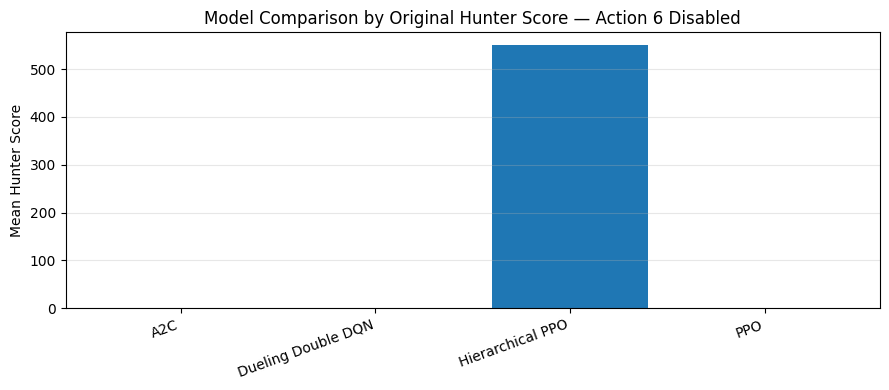

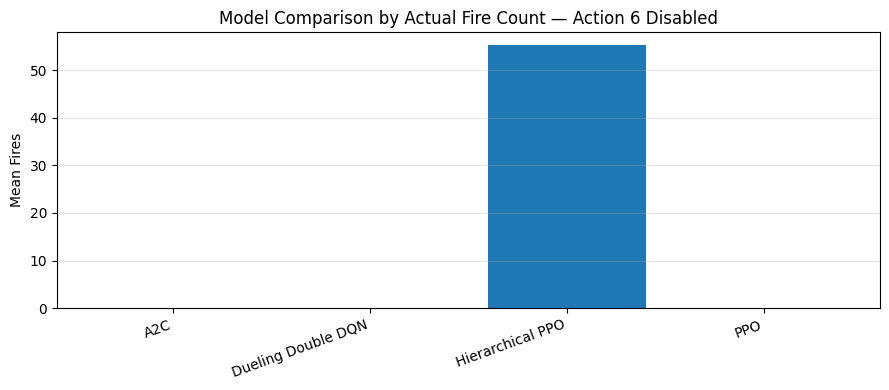

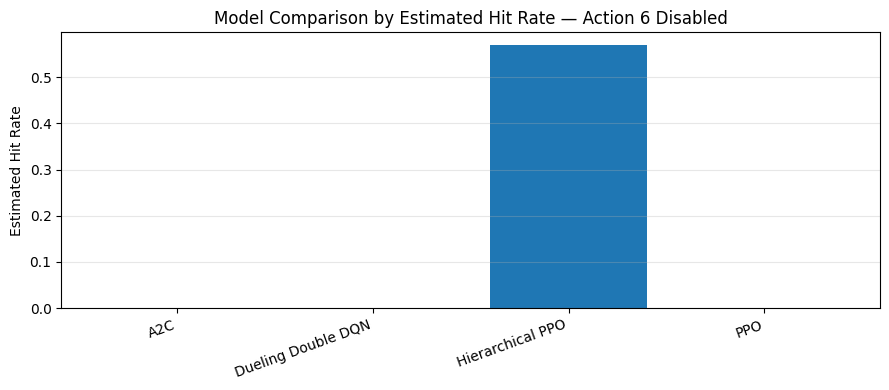

,model,total_score
0,A2C,0.0
1,Dueling Double DQN,0.0
2,Hierarchical PPO,2748.0
3,PPO,0.0


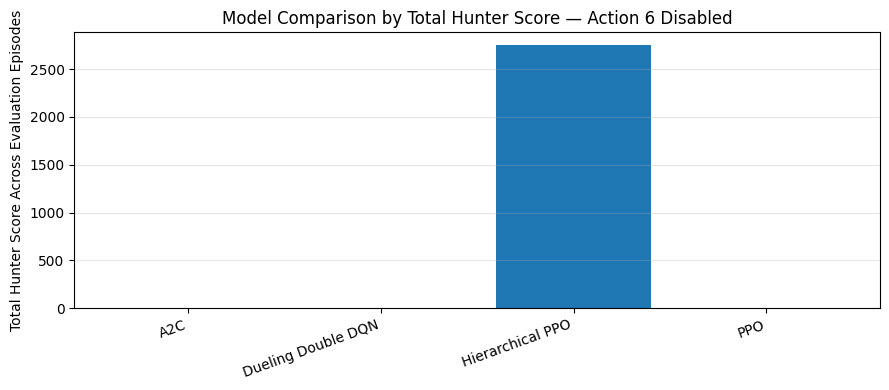

In [33]:
if comparison_df.empty:                                                                         # Starts a conditional branch for controlled execution.
    print("No comparison plot generated because comparison_df is empty. Run optional Section 02 training/evaluation first if needed.") # Prints progress or diagnostic information for presentation/debugging.
else:                                                                                           # Starts the fallback branch for the current conditional block.
    summary_df = comparison_df.groupby("model").agg(mean_score=("score", "mean"), mean_reward=("reward", "mean"), mean_fires=("fires", "mean"), mean_hit_rate=("hit_rate", "mean")).reset_index() # Summarizes metrics by model.
    display(summary_df)                                                          # Displays summary table.

    plt.figure(figsize=(9, 4))                                                    # Creates score comparison plot.
    plt.bar(summary_df["model"], summary_df["mean_score"])                      # Plots mean Hunter score by model.
    plt.title("Model Comparison by Original Hunter Score — Action 6 Disabled")   # Adds title.
    plt.ylabel("Mean Hunter Score")                                              # Labels y-axis.
    plt.xticks(rotation=20, ha="right")                                          # Rotates model names.
    plt.grid(axis="y", alpha=0.3)                                                # Adds horizontal grid.
    plt.tight_layout()                                                           # Tightens layout.
    plt.savefig(OUTPUT_DIR / "comparison_mean_score.png", dpi=180)               # Saves score plot.
    plt.show()                                                                   # Displays score plot.

    plt.figure(figsize=(9, 4))                                                    # Creates fire-count comparison plot.
    plt.bar(summary_df["model"], summary_df["mean_fires"])                      # Plots mean fire count by model.
    plt.title("Model Comparison by Actual Fire Count — Action 6 Disabled")       # Adds title.
    plt.ylabel("Mean Fires")                                                     # Labels y-axis.
    plt.xticks(rotation=20, ha="right")                                          # Rotates model names.
    plt.grid(axis="y", alpha=0.3)                                                # Adds horizontal grid.
    plt.tight_layout()                                                           # Tightens layout.
    plt.savefig(OUTPUT_DIR / "comparison_mean_fires.png", dpi=180)               # Saves fire-count plot.
    plt.show()                                                                   # Displays fire-count plot.

    plt.figure(figsize=(9, 4))                                                    # Creates hit-rate comparison plot.
    plt.bar(summary_df["model"], summary_df["mean_hit_rate"])                   # Plots estimated hit rate.
    plt.title("Model Comparison by Estimated Hit Rate — Action 6 Disabled")      # Adds title.
    plt.ylabel("Estimated Hit Rate")                                             # Labels y-axis.
    plt.xticks(rotation=20, ha="right")                                          # Rotates model names.
    plt.grid(axis="y", alpha=0.3)                                                # Adds horizontal grid.
    plt.tight_layout()                                                           # Tightens layout.
    plt.savefig(OUTPUT_DIR / "comparison_mean_hit_rate.png", dpi=180)            # Saves hit-rate plot.
    plt.show()                                                                   # Displays hit-rate plot.



    score_totals = comparison_df.groupby("model").agg(total_score=("score", "sum")).reset_index() # Aggregates total score across evaluation episodes.
    display(score_totals)                                                       # Displays total-score table for presentation.
    plt.figure(figsize=(9, 4))                                                   # Creates total-score comparison plot.
    plt.bar(score_totals["model"], score_totals["total_score"])                # Plots total Hunter score by model.
    plt.title("Model Comparison by Total Hunter Score — Action 6 Disabled")     # Adds plot title.
    plt.ylabel("Total Hunter Score Across Evaluation Episodes")                 # Labels y-axis.
    plt.xticks(rotation=20, ha="right")                                         # Rotates model names for readability.
    plt.grid(axis="y", alpha=0.3)                                               # Adds horizontal grid.
    plt.tight_layout()                                                           # Tightens plot layout.
    plt.savefig(OUTPUT_DIR / "comparison_total_score.png", dpi=180)             # Saves total-score plot.
    plt.show()                                                                  # Displays total-score plot.




## Export 3D videos for presentation

This section uses `render_mode="rgb_array"` and requires a working OpenGL/PyGame display stack. Video files are qualitative demonstrations. The official quantitative comparison should come from the CSV evaluation tables and the multi-seed plots.


In [34]:
def export_raw_model_3d_video(model_name, model=None, output_path=None, max_steps=4800, seed=888): # Exports real 3D video for raw DQN/A2C/PPO.
    import imageio                                                            # Imports video writer.
    env = gym.make("Shooter-v0", render_mode="rgb_array")                   # Creates original 3D-rendering environment.
    env = NoAction6Env(env)                                                    # Adds no-action-6 guard.
    obs, info = env.reset(seed=seed)                                          # Resets environment.
    frames = []                                                               # Stores 3D frames.
    fires = 0                                                                 # Counts fire actions.
    dqn_policy = None                                                         # Creates placeholder for DQN model.
    if model_name == "Dueling Double DQN":                                    # Checks DQN video branch.
        dqn_policy = load_dqn_policy(CHECKPOINT_DIR / "dueling_double_dqn_comparison.pt") # Loads DQN policy.
    try:                                                                      # Protects cleanup from OpenGL errors.
        for step in range(max_steps):                                         # Runs episode rollout for video.
            if step % 2 == 0:                                                 # Captures every second frame.
                frame = env.render()                                          # Captures real OpenGL frame.
                if frame is not None:                                         # Checks frame validity.
                    frames.append(frame)                                      # Stores frame.
            if model_name == "Dueling Double DQN":                            # Selects DQN action branch.
                dqn_model, device = dqn_policy                                # Unpacks DQN model and device.
                with torch.no_grad():                                         # Disables gradients.
                    q_values = dqn_model(torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)) # Computes Q-values.
                    action = int(q_values.argmax(dim=1).item())               # Selects greedy DQN action.
            else:                                                             # Selects SB3 model action branch.
                action, _ = model.predict(obs, deterministic=True)             # Predicts action from A2C or PPO.
                action = int(action)                                          # Converts action to integer.
            action = assert_no_action6(action, source=f"{model_name} 3D video") # Blocks action 6.
            fires += int(action == 1)                                         # Counts fire action.
            obs, reward, terminated, truncated, info = env.step(action)       # Steps original environment.
            if terminated or truncated:                                       # Stops on episode end.
                frame = env.render()                                          # Captures final frame.
                if frame is not None:                                         # Checks final frame validity.
                    frames.append(frame)                                      # Stores final frame.
                break                                                         # Stops rollout.
        if frames:                                                            # Checks that frame capture succeeded.
            imageio.mimsave(output_path, frames, fps=20)                      # Saves video file.
        print(f"Saved {model_name} 3D video:", output_path)                  # Prints saved path.
        print("Final score:", info.get("hunterScore"), "fires:", fires, "reason:", info.get("gameOverReason", "") or "truncated") # Prints final summary.
    finally:                                                                  # Ensures environment cleanup.
        env.close()                                                           # Closes rendering environment.


def export_hierarchical_3d_video(model, output_path, max_steps=4800, seed=888): # Exports real 3D video for hierarchical PPO.
    import imageio                                                            # Imports video writer.
    env = make_hier_env(seed=seed, render_mode="rgb_array")()                # Creates hierarchical environment with 3D rendering.
    obs, info = env.reset(seed=seed)                                          # Resets environment.
    frames = []                                                               # Stores 3D frames.
    fires = 0                                                                 # Counts actual low-level fires.
    try:                                                                      # Protects cleanup from OpenGL errors.
        for step in range(max_steps):                                         # Runs rollout for video.
            if step % 2 == 0:                                                 # Captures every second tick.
                frame = env.render()                                          # Captures original OpenGL frame.
                if frame is not None:                                         # Checks frame validity.
                    frames.append(frame)                                      # Stores frame.
            policy_obs = align_observation_for_model(obs, model)               # Matches wrapper observation shape to the model checkpoint input shape.
            high_action, _ = model.predict(policy_obs, deterministic=True)       # Predicts high-level decision from correctly shaped observation.
            obs, reward, terminated, truncated, info = env.step(int(high_action)) # Steps wrapper and original environment.
            low_action = assert_no_action6(info.get("low_action", 0), source="Hierarchical 3D video") # Verifies actual low-level action.
            fires += int(low_action == 1)                                     # Counts true fire actions.
            if terminated or truncated:                                       # Stops at episode end.
                frame = env.render()                                          # Captures final frame.
                if frame is not None:                                         # Checks final frame validity.
                    frames.append(frame)                                      # Stores final frame.
                break                                                         # Stops rollout.
        if frames:                                                            # Checks frame capture success.
            imageio.mimsave(output_path, frames, fps=20)                      # Saves video file.
        print("Saved Hierarchical PPO 3D video:", output_path)               # Prints saved path.
        print("Final score:", info.get("hunterScore"), "fires:", fires, "reason:", info.get("gameOverReason", "") or "truncated") # Prints final summary.
    finally:                                                                  # Ensures environment cleanup.
        env.close()                                                           # Closes environment.




In [35]:
ACTIVE_TRAINING_TIMESTEPS = globals().get("ACTIVE_TRAINING_TIMESTEPS", 250000) # Restores the active training budget if this diagnostic cell is run alone.
ARTIFACT_TAG = globals().get("ARTIFACT_TAG", f"train_{ACTIVE_TRAINING_TIMESTEPS}") # Restores the artifact tag used in video, checkpoint, and log names.
EXPORT_3D_BASELINE_VIDEO = globals().get("EXPORT_3D_BASELINE_VIDEO", True)   # Ensures the baseline-video flag exists before printing diagnostics.
EXPORT_HIERARCHICAL_TOPDOWN_VIDEO = globals().get("EXPORT_HIERARCHICAL_TOPDOWN_VIDEO", True) # Ensures the top-down final-video flag exists before printing diagnostics.
EXPORT_HIERARCHICAL_3D_VIDEO = globals().get("EXPORT_HIERARCHICAL_3D_VIDEO", True) # Ensures the real 3D final-video flag exists before printing diagnostics.
EXPORT_COMPARISON_3D_VIDEOS = globals().get("EXPORT_COMPARISON_3D_VIDEOS", True) # Ensures the comparison-video flag exists before printing diagnostics.
print("Video export flags:")                                              # Prints the current video-export configuration for presentation checking.
print("  EXPORT_3D_BASELINE_VIDEO =", EXPORT_3D_BASELINE_VIDEO)       # Shows whether the Lead-Aim baseline video will be exported.
print("  EXPORT_HIERARCHICAL_TOPDOWN_VIDEO =", EXPORT_HIERARCHICAL_TOPDOWN_VIDEO) # Shows whether the top-down final Hierarchical PPO video will be exported.
print("  EXPORT_HIERARCHICAL_3D_VIDEO =", EXPORT_HIERARCHICAL_3D_VIDEO) # Shows whether the real OpenGL final Hierarchical PPO video will be exported.
print("  EXPORT_COMPARISON_3D_VIDEOS =", EXPORT_COMPARISON_3D_VIDEOS) # Shows whether comparison model 3D videos will be exported.

print("Available checkpoint zip files:")                              # Prints saved Stable-Baselines3 checkpoints before video loading.
for checkpoint_path in sorted(CHECKPOINT_DIR.glob("*.zip")):           # Loops through saved SB3 checkpoints in the checkpoint directory.
    print(" -", checkpoint_path.name)                                  # Prints one checkpoint filename for verification.

print("Available checkpoint pt files:")                               # Prints saved PyTorch checkpoints before DQN video loading.
for checkpoint_path in sorted(CHECKPOINT_DIR.glob("*.pt")):            # Loops through saved PyTorch checkpoints in the checkpoint directory.
    print(" -", checkpoint_path.name)                                  # Prints one checkpoint filename for verification.

if "trained_models" in globals():                                      # Checks whether the comparison training cell has already run.
    print("trained_models keys:", list(trained_models.keys()))          # Shows which comparison models are available for video export.
else:                                                                      # Handles the case where comparison training has not run yet.
    print("trained_models is not defined yet; run the comparison training cell before comparison video export.") # Prints required run-order guidance.

Video export flags:
  EXPORT_3D_BASELINE_VIDEO = True
  EXPORT_HIERARCHICAL_TOPDOWN_VIDEO = True
  EXPORT_HIERARCHICAL_3D_VIDEO = True
  EXPORT_COMPARISON_3D_VIDEOS = True
Available checkpoint zip files:
 - a2c_raw_no_action6.zip
 - best_a2c_train_250000.zip
 - best_hierarchical_ppo_1500plus.zip
 - best_hierarchical_ppo_shooter.zip
 - best_hierarchical_ppo_train_250000.zip
 - best_ppo_train_250000.zip
 - final_a2c_train_250000.zip
 - final_hierarchical_ppo_1500plus.zip
 - final_hierarchical_ppo_shooter.zip
 - final_hierarchical_ppo_train_250000.zip
 - final_ppo_train_250000.zip
 - hierarchical_ppo_no_action6_comparison.zip
 - ppo_raw_no_action6.zip
Available checkpoint pt files:
 - best_a2c_train_250000.pt
 - best_dueling_double_dqn_train_250000.pt
 - best_hierarchical_ppo_1500plus.pt
 - best_hierarchical_ppo_train_250000.pt
 - best_ppo_train_250000.pt
 - dueling_double_dqn_comparison.pt
 - final_a2c_train_250000.pt
 - final_dueling_double_dqn_train_250000.pt
 - final_hierarchical_ppo_

In [36]:
EXPORT_COMPARISON_3D_VIDEOS = globals().get("EXPORT_COMPARISON_3D_VIDEOS", True) # Reuses the comparison video flag created in the setup cell.
ARTIFACT_TAG = globals().get("ARTIFACT_TAG", "train_250000")              # Reuses the artifact tag so comparison videos include the budget in the filename.
if EXPORT_COMPARISON_3D_VIDEOS and "trained_models" not in globals():        # Prevents a NameError when the video cell is run before comparison training.
    print("Comparison videos skipped because trained_models is not available yet. Run the comparison training cell first.") # Explains the required run order.
elif EXPORT_COMPARISON_3D_VIDEOS:                                             # Runs video export only when enabled and trained models exist.
    if RUN_DQN:                                                               # Checks DQN video flag.
        export_raw_model_3d_video("Dueling Double DQN", output_path=OUTPUT_DIR / f"comparison_dueling_double_dqn_3d_{ARTIFACT_TAG}_seed888.mp4") # Exports DQN 3D video.
    if RUN_A2C and "A2C" in trained_models:                                  # Checks A2C video flag and confirms the trained model exists.
        export_raw_model_3d_video("A2C", model=trained_models["A2C"], output_path=OUTPUT_DIR / f"comparison_a2c_3d_{ARTIFACT_TAG}_seed888.mp4") # Exports A2C 3D video.
    if RUN_PPO and "PPO" in trained_models:                                  # Checks PPO video flag and confirms the trained model exists.
        export_raw_model_3d_video("PPO", model=trained_models["PPO"], output_path=OUTPUT_DIR / f"comparison_ppo_3d_{ARTIFACT_TAG}_seed888.mp4") # Exports PPO 3D video.
    if RUN_HIER_PPO and "Hierarchical PPO" in trained_models:                # Checks hierarchical PPO video flag and confirms the trained model exists.
        export_hierarchical_3d_video(trained_models["Hierarchical PPO"], output_path=OUTPUT_DIR / f"comparison_hierarchical_ppo_3d_{ARTIFACT_TAG}_seed888.mp4") # Exports hierarchical PPO 3D video.

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved Dueling Double DQN 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/comparison_dueling_double_dqn_3d_train_250000_seed888.mp4
Final score: 0 fires: 0 reason: RED vehicle reached the Hunter!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved A2C 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/comparison_a2c_3d_train_250000_seed888.mp4
Final score: 0 fires: 0 reason: RED vehicle reached the Hunter!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved PPO 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/comparison_ppo_3d_train_250000_seed888.mp4
Final score: 0 fires: 0 reason: RED vehicle reached the Hunter!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (700, 700) to (704, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved Hierarchical PPO 3D video: /mnt/c/Users/Waranon-021/Desktop/shooter_friend_v10_multi_budget_video_export_flags_fixed/outputs/comparison_hierarchical_ppo_3d_train_250000_seed888.mp4
Final score: 1772 fires: 174 reason: DEEPSKYBLUE vehicle reached the Hunter!


## Build final training artifact bundle

Run this cell after training, evaluation, and video export. It collects generated `.zip`, `.pt`, `.csv`, `.png`, `.mp4`, and `.gif` files into a single results bundle under `outputs/`, making submission and instructor checking easier.


In [37]:
artifact_manifest_df = build_training_artifact_manifest(tag=ARTIFACT_TAG)       # Lists generated checkpoints, logs, plots, and videos.
# Uncomment the next line after training if a single result zip is needed inside the project folder.
# bundle_path = create_training_results_bundle(tag=ARTIFACT_TAG)              # Creates outputs/training_results_bundle_<tag>.zip.


,artifact_type,file_name,extension,size_bytes,path
0,checkpoint,a2c_raw_no_action6.zip,.zip,275335,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
1,checkpoint,best_a2c_train_250000.pt,.pt,128251,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
2,checkpoint,best_a2c_train_250000.zip,.zip,275331,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
3,checkpoint,best_dueling_double_dqn_train_250000.pt,.pt,711241,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
4,checkpoint,best_hierarchical_ppo_1500plus.pt,.pt,132829,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
...,...,...,...,...,...
90,output,"hierarchical_ppo_gameplay_real_3d_train_(250, ...",.mp4,1153706,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
91,output,"hierarchical_ppo_gameplay_topdown_train_(250, ...",.gif,1343066,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
92,output,"hierarchical_ppo_gameplay_topdown_train_(250, ...",.mp4,534570,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...
93,output,lead_aim_no_action6_baseline_plot.png,.png,87196,/mnt/c/Users/Waranon-021/Desktop/shooter_frien...


## Presentation interpretation

The direct raw-action baselines test whether DQN, A2C, and PPO can learn low-level aiming and firing directly from the original Shooter-v0 action space. The hierarchical method separates high-level decision-making from low-level aiming, which makes the final behavior easier to learn while still executing only legal actions `0–5` in the original environment.

Recommended wording: **Hierarchical PPO with a deterministic Lead-Aim Controller**. The method should not be described as pure end-to-end PPO.
